# Notebook 01: JEPA Fundamentals — Math & Code From Scratch

**Goal:** Understand the JEPA objective mathematically, then implement a minimal working version.

**Prerequisites:** Basic PyTorch, matrix multiplication, what a neural network is.

---

## 1. What Problem Does JEPA Solve?

Traditional self-supervised learning has two main approaches:

| Approach | What it does | Problem |
|----------|-------------|--------|
| **Generative** (MAE, GPT) | Reconstruct raw pixels/tokens | Wastes capacity on irrelevant details (exact texture, lighting) |
| **Contrastive** (SimCLR, CLIP) | Pull similar views together, push different apart | Needs hand-crafted augmentations, hard negative mining |

**JEPA's insight:** Don't predict pixels. Don't compare views. Instead, **predict abstract representations** of missing content.

```
MAE:   Image → mask patches → predict PIXELS of masked patches
JEPA:  Image → mask patches → predict REPRESENTATIONS of masked patches
```

This lets the model ignore unpredictable details and focus on semantic content.

## 2. The JEPA Objective — Mathematical Formulation

### Core Equation

$$\min_{\theta, \phi, \Delta_y} \| P_\phi(\Delta_y, E_\theta(\mathbf{x})) - \text{sg}(E_{\bar{\theta}}(\mathbf{y})) \|_1$$

Let's break this down piece by piece:

| Symbol | What it is | Role |
|--------|-----------|------|
| $E_\theta$ | **Encoder** (ViT) | Encodes visible (unmasked) patches into representations |
| $E_{\bar{\theta}}$ | **Target encoder** (EMA copy) | Encodes ALL patches to create prediction targets |
| $P_\phi$ | **Predictor** (smaller ViT) | Predicts masked patch representations from visible ones |
| $\Delta_y$ | **Mask tokens** (learnable) | Placeholder tokens at masked positions |
| $\mathbf{x}$ | Visible patches (after masking) | Input to encoder |
| $\mathbf{y}$ | Full image (no masking) | Input to target encoder |
| $\text{sg}(\cdot)$ | **Stop-gradient** | Prevents gradient flow → avoids representation collapse |
| $\|\cdot\|_1$ | **L1 loss** | Mean absolute error in latent space |

### Why stop-gradient + EMA?

Without it, the model could "cheat" by making all representations identical (collapse to zero).
- **Stop-gradient**: Target encoder doesn't receive gradients → can't collapse to match predictions
- **EMA update**: Target encoder slowly tracks the online encoder → stable targets

### EMA Update Rule

$$\bar{\theta} \leftarrow \tau \cdot \bar{\theta} + (1 - \tau) \cdot \theta, \quad \tau = 0.99925$$

This means: each step, the target encoder is 99.925% its old self + 0.075% the current encoder.

## 2.5 The 5W+H of JEPA — Who, What, Where, When, Why, How

### WHO created JEPA?
**Yann LeCun** (Meta/FAIR Chief AI Scientist, Turing Award 2018). Introduced in his 2022 position paper *"A Path Towards Autonomous Machine Intelligence"*. I-JEPA implemented by Assran, Duval, Misra et al. (CVPR 2023). V-JEPA 2 by Bardes, Garrido, Ponce et al. (2025).

### WHAT is JEPA?
A **self-supervised learning architecture** that learns representations by predicting abstract features of masked content from visible content. It consists of:
- An **online encoder** $E_\theta$ (trained via backprop)
- A **target encoder** $E_{\bar\theta}$ (updated via EMA, no gradients)
- A **predictor** $P_\phi$ (trained via backprop)

### WHERE does prediction happen?
**In latent (representation) space**, NOT in pixel/input space. This is the core distinction from MAE/GPT-style models. The loss is computed between D-dimensional vectors, not H×W pixel patches.

### WHEN is each component used?

| Phase | Encoder $E_\theta$ | Target $E_{\bar\theta}$ | Predictor $P_\phi$ |
|-------|-------------------|------------------------|-------------------|
| **Training** | Encodes visible patches | Encodes ALL patches (no grad) | Predicts masked representations |
| **Inference** | Encodes input | Not used | Not used |
| **Robotics (AC)** | Frozen feature extractor | Frozen feature extractor | Action-conditioned world model |

### WHY predict in latent space instead of pixels?

**The information-theoretic argument:**

A 256×256 RGB image has $256 \times 256 \times 3 = 196{,}608$ values.
Most of these encode **textures, lighting, noise** — irrelevant for understanding.

A V-JEPA 2 latent patch is a **1408-dim vector** encoding semantic content.
By predicting here, the model can be **precisely right about semantics** while being **imprecise about irrelevant details**.

Formally, JEPA learns a representation where the **predictable information** (structure, objects, physics) is separated from **unpredictable information** (noise, exact textures).

### HOW does it actually work? (Matrix-level detail)

The complete forward pass as matrix operations:

$$\underbrace{\mathbf{X}}_{\text{image}} \xrightarrow{\text{patchify}} \underbrace{\mathbf{P} \in \mathbb{R}^{N \times d_{\text{patch}}}}_{\text{N patches}} \xrightarrow{\text{mask}} \underbrace{\mathbf{P}_{\text{vis}} \in \mathbb{R}^{M \times d}}_{\text{M visible}}$$

$$\mathbf{P}_{\text{vis}} \xrightarrow{E_\theta} \underbrace{\mathbf{Z}_{\text{vis}} \in \mathbb{R}^{M \times D}}_{\text{encoder output}} \xrightarrow{P_\phi} \underbrace{\hat{\mathbf{H}}_{\text{mask}} \in \mathbb{R}^{(N-M) \times D}}_{\text{predictions for masked}}$$

$$\mathbf{P} \xrightarrow{E_{\bar\theta}} \underbrace{\mathbf{H} \in \mathbb{R}^{N \times D}}_{\text{all targets}} \xrightarrow{\text{gather}} \underbrace{\mathbf{H}_{\text{mask}} \in \mathbb{R}^{(N-M) \times D}}_{\text{targets at masked positions}}$$

$$\mathcal{L} = \frac{1}{(N-M) \cdot D} \sum_{i,j} \left| \hat{\mathbf{H}}_{\text{mask}}[i,j] - \mathbf{H}_{\text{mask}}[i,j] \right|$$

In [1]:
# MATRIX DIMENSION TRACKING: Step-by-step through a JEPA forward pass
# This shows every tensor shape at every stage

print("=" * 70)
print("JEPA FORWARD PASS — MATRIX DIMENSIONS STEP BY STEP")
print("=" * 70)
print()

# Parameters (V-JEPA 2 real values)
B = 2          # batch size
C = 3          # RGB channels
T = 16         # video frames
H_px = 256     # height in pixels
W_px = 256     # width in pixels
P = 16         # patch size
Tb = 2         # tubelet size (temporal patch)
D = 1408       # ViT-giant embedding dim
D_pred = 384   # predictor embedding dim
N_heads = 22   # attention heads
mask_ratio = 0.90

# Derived
T_tok = T // Tb              # temporal tokens
H_tok = H_px // P            # height tokens
W_tok = W_px // P            # width tokens
N = T_tok * H_tok * W_tok    # total patches
N_vis = int(N * (1 - mask_ratio))
N_mask = N - N_vis
head_dim = D // N_heads

steps = [
    ("INPUT VIDEO",             f"[{B}, {C}, {T}, {H_px}, {W_px}]",
     f"B × C × T × H × W"),
    ("PatchEmbed3D (Conv3d)",   f"[{B}, {D}, {T_tok}, {H_tok}, {W_tok}]",
     f"kernel=({Tb}×{P}×{P}), stride=same"),
    ("flatten + transpose",     f"[{B}, {N}, {D}]",
     f"N = {T_tok}×{H_tok}×{W_tok} = {N} patches"),
    ("MASK (~90%)",             f"vis: [{B}, {N_vis}, {D}]  |  mask: [{B}, {N_mask}, {D}]",
     f"{N_vis} visible ({100*(1-mask_ratio):.0f}%), {N_mask} masked ({100*mask_ratio:.0f}%)"),
    ("Encoder QKV projection",  f"[{B}, {N_vis}, {3*D}] → Q,K,V each [{B}, {N_heads}, {N_vis}, {head_dim}]",
     f"3 × {D} → split into {N_heads} heads of dim {head_dim}"),
    ("3D RoPE rotation",        f"Q,K: [{B}, {N_heads}, {N_vis}, {head_dim}]",
     f"rotate dims [0:{int(2*((head_dim//3)//2))}|{int(2*((head_dim//3)//2))}:{2*int(2*((head_dim//3)//2))}|{2*int(2*((head_dim//3)//2))}:{3*int(2*((head_dim//3)//2))}], unrotated: {head_dim - 3*int(2*((head_dim//3)//2))}"),
    ("Attention: Q·K^T / √d",  f"[{B}, {N_heads}, {N_vis}, {N_vis}]",
     f"softmax over {N_vis} keys per query"),
    ("Attention · V",           f"[{B}, {N_heads}, {N_vis}, {head_dim}]",
     f"weighted sum of values"),
    ("Concat heads + project",  f"[{B}, {N_vis}, {D}]",
     f"concatenate {N_heads} heads → project"),
    ("×40 blocks → Encoder out",f"[{B}, {N_vis}, {D}]",
     f"z_vis: visible patch representations"),
    ("",                        "",
     "────────── PREDICTOR ──────────"),
    ("Project to pred dim",     f"[{B}, {N_vis}, {D_pred}]",
     f"linear {D} → {D_pred}"),
    ("Mask tokens (learnable)",  f"[{B}, {N_mask}, {D_pred}]",
     f"Δ_y: {N_mask} mask tokens, each {D_pred}-dim"),
    ("Concat + sort by position",f"[{B}, {N_vis}+{N_mask}, {D_pred}] = [{B}, {N}, {D_pred}]",
     f"all {N} tokens in position order"),
    ("×12 blocks → Predictor",  f"[{B}, {N}, {D_pred}]",
     f"all tokens processed jointly"),
    ("Extract mask tokens",     f"[{B}, {N_mask}, {D_pred}]",
     f"reverse sort, take mask positions only"),
    ("Project back",            f"[{B}, {N_mask}, {D}]",
     f"linear {D_pred} → {D}: predictions ẑ_mask"),
    ("",                        "",
     "────────── TARGET ──────────"),
    ("Target enc (ALL patches)",f"[{B}, {N}, {D}]",
     f"EMA encoder processes all {N} patches (no mask)"),
    ("LayerNorm targets",       f"[{B}, {N}, {D}]",
     f"normalize target representations"),
    ("Gather at mask positions",f"[{B}, {N_mask}, {D}]",
     f"h_mask: ground-truth targets"),
    ("",                        "",
     "────────── LOSS ──────────"),
    ("L1 loss: |ẑ_mask - h_mask|",f"scalar",
     f"mean over [{B}, {N_mask}, {D}] = {B*N_mask*D:,} values"),
]

print(f"{'Step':<30} {'Shape':<55} {'Notes'}")
print("-" * 140)
for step, shape, notes in steps:
    if step == "":
        print(f"\n{notes}")
    else:
        print(f"{step:<30} {shape:<55} {notes}")

JEPA FORWARD PASS — MATRIX DIMENSIONS STEP BY STEP

Step                           Shape                                                   Notes
--------------------------------------------------------------------------------------------------------------------------------------------
INPUT VIDEO                    [2, 3, 16, 256, 256]                                    B × C × T × H × W
PatchEmbed3D (Conv3d)          [2, 1408, 8, 16, 16]                                    kernel=(2×16×16), stride=same
flatten + transpose            [2, 2048, 1408]                                         N = 8×16×16 = 2048 patches
MASK (~90%)                    vis: [2, 204, 1408]  |  mask: [2, 1844, 1408]           204 visible (10%), 1844 masked (90%)
Encoder QKV projection         [2, 204, 4224] → Q,K,V each [2, 22, 204, 64]            3 × 1408 → split into 22 heads of dim 64
3D RoPE rotation               Q,K: [2, 22, 204, 64]                                   rotate dims [0:20|20:40|40:60], unrotat

### Reading the Output Above

**Printed Table -- JEPA Forward Pass Dimension Tracking**:

This table traces every tensor shape through V-JEPA 2's full pipeline using real architecture values (ViT-giant).

**Key dimensions** ($B=2$, $D=1408$, $N_{\text{heads}}=22$):

1. **Input Video** $[2, 3, 16, 256, 256]$: Batch of 2 RGB videos, 16 frames, $256 \times 256$ pixels.
2. **PatchEmbed3D** $[2, 1408, 8, 16, 16]$: Conv3D with kernel $(2, 16, 16)$ converts pixels to $D=1408$-dim patch tokens. Temporal resolution halved ($16 \to 8$), spatial by $16\times$ ($256 \to 16$).
3. **Flatten** $[2, 2048, 1408]$: $N = 8 \times 16 \times 16 = 2048$ total patches, each $1408$-dim.
4. **Masking (90%)** $[2, 205, 1408]$ visible, $[2, 1843, 1408]$ masked: Only 205 patches (10%) go to the encoder. The other 1843 are hidden.
5. **QKV projection**: Each Q, K, V $\in \mathbb{R}^{[2, 22, 205, 64]}$ -- 22 attention heads, each with $d_k = 1408/22 = 64$.
6. **Attention matrix** $[2, 22, 205, 205]$: Each of the 22 heads computes a $205 \times 205$ attention map (which visible patch attends to which).
7. **Predictor**: Projects from $D=1408$ to $D_{\text{pred}}=384$, processes all $N=2048$ tokens (visible + mask tokens), then projects predictions back to $D=1408$.
8. **Loss**: Scalar value computed over $[2, 1843, 1408] = 5{,}192{,}608$ individual comparisons per batch.

**Why these numbers matter**:
- Memory scales as $O(N^2 \cdot H)$ for attention: $205^2 \times 22 \approx 925{,}000$ entries per sample.
- The predictor uses smaller dimension ($384$ vs $1408$) to save compute.
- 90% masking reduces encoder cost by $10\times$ (only 205 tokens instead of 2048).

## 3. Let's Implement It — Minimal JEPA on Toy Data

We'll build a tiny JEPA from scratch using only basic PyTorch. No ViT needed yet — just MLPs to understand the flow.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy

torch.manual_seed(42)
print(f"PyTorch version: {torch.__version__}")
print(f"Device: CPU (AMD Radeon — we'll use CPU for study)")

PyTorch version: 2.10.0+cpu
Device: CPU (AMD Radeon — we'll use CPU for study)


### Reading the Output Above

**Printed Environment Info**:

- **PyTorch version**: The version of PyTorch installed (e.g., `2.x.x`). Any version >= 2.0 works for this notebook.
- **Device: CPU**: We are running on CPU (not GPU). This is fine for the toy model -- training takes seconds, not hours.
  - In production V-JEPA 2 training, you would use multiple GPUs (e.g., 64 A100s for 4 days).
  - Our toy model has ~6K parameters vs V-JEPA 2's ~1.1B, so CPU is sufficient.

**Libraries loaded**:
- `torch`: Core tensor operations and autograd (automatic differentiation).
- `torch.nn`: Neural network layers (Linear, LayerNorm, GELU, etc.).
- `torch.nn.functional as F`: Functional versions of operations (e.g., `F.layer_norm`).
- `matplotlib.pyplot`: Plotting library for all visualizations in this notebook.
- `copy`: For `copy.deepcopy()` -- creating the target encoder as an exact copy of the online encoder.

**`torch.manual_seed(42)`**: Sets the random number generator to a fixed seed. This ensures that every time you run this notebook, you get exactly the same results. Without this, random initialization and masking would produce different numbers each run.

### 3.1 Create Toy "Image" Data

We'll represent an "image" as a sequence of 16 patches, each a 32-dim vector.
Think of this as a 4×4 grid of patches from a 64×64 image with patch_size=16.

In [3]:
# Toy dataset: 100 "images", each with 16 patches of dimension 32
N_images = 200
N_patches = 16      # 4x4 grid
patch_dim = 32      # each patch is a 32-dim vector

# Create structured data (not pure noise — patches near each other are correlated)
data = []
for i in range(N_images):
    # Base pattern + local variation (simulates spatial correlation in real images)
    base = torch.randn(1, patch_dim) * 2  # global image-level pattern
    patches = base.repeat(N_patches, 1) + torch.randn(N_patches, patch_dim) * 0.5
    data.append(patches)
data = torch.stack(data)  # [200, 16, 32]

print(f"Dataset shape: {data.shape}  (N_images, N_patches, patch_dim)")
print(f"This represents {N_images} images, each split into {N_patches} patches of dim {patch_dim}")

Dataset shape: torch.Size([200, 16, 32])  (N_images, N_patches, patch_dim)
This represents 200 images, each split into 16 patches of dim 32


### Reading the Output Above

**Printed Dataset Info**:

- **Dataset shape: [200, 16, 32]**: A tensor containing 200 synthetic "images".
  - *Formal*: $X \in \mathbb{R}^{[N_{\text{images}}, N_{\text{patches}}, D_{\text{patch}}]}$
  - *Dimension breakdown*:
    - $200$ = number of images (our tiny training set)
    - $16$ = number of patches per image (like a $4 \times 4$ grid from a $64 \times 64$ image with patch_size $= 16$)
    - $32$ = patch dimension (each patch is a 32-dimensional vector)
  - *Layman*: 200 images, each cut into 16 pieces, each piece described by 32 numbers.

- **Data generation process**: Each image has a random "base pattern" ($\mathbb{R}^{32}$, scaled by 2) that is shared across all 16 patches, plus per-patch noise (scaled by 0.5). This simulates real images where nearby patches are correlated (they share the same object, lighting, etc.).
  - *Formal*: $x_{i,n} = b_i + \epsilon_{i,n}$ where $b_i \sim \mathcal{N}(0, 4I)$ and $\epsilon_{i,n} \sim \mathcal{N}(0, 0.25I)$.
  - *Layman*: Each image has a "theme" (the base pattern) and each patch is a slightly different version of that theme.

**Why structured data matters**: If patches were independent random noise, there would be no correlation between visible and masked patches -- the prediction task would be impossible. The shared base pattern ensures that seeing some patches tells you something about the others, making JEPA's prediction task meaningful.

### 3.2 Masking Strategy

JEPA masks ~75-90% of patches. The encoder only sees the visible patches.
The predictor must predict representations of the masked patches.

V-JEPA 2 uses **~90% masking** with spatiotemporal blocks. For simplicity, we'll do random masking.

In [4]:
def create_masks(batch_size, n_patches, mask_ratio=0.75):
    """
    Create random masks for JEPA.
    Returns:
        visible_indices: indices of patches the encoder sees
        masked_indices:  indices of patches the predictor must predict
    """
    n_masked = int(n_patches * mask_ratio)
    n_visible = n_patches - n_masked
    
    visible_list = []
    masked_list = []
    for _ in range(batch_size):
        perm = torch.randperm(n_patches)
        visible_list.append(perm[:n_visible].sort()[0])
        masked_list.append(perm[n_visible:].sort()[0])
    
    return torch.stack(visible_list), torch.stack(masked_list)

# Demo
vis_idx, mask_idx = create_masks(batch_size=2, n_patches=16, mask_ratio=0.75)
print(f"Visible patches (encoder sees):  {vis_idx[0].tolist()}")
print(f"Masked patches (predictor predicts): {mask_idx[0].tolist()}")
print(f"\nEncoder sees {vis_idx.shape[1]}/{N_patches} = {vis_idx.shape[1]/N_patches*100:.0f}% of patches")
print(f"Predictor must predict {mask_idx.shape[1]}/{N_patches} = {mask_idx.shape[1]/N_patches*100:.0f}% of patches")

Visible patches (encoder sees):  [0, 1, 3, 15]
Masked patches (predictor predicts): [2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

Encoder sees 4/16 = 25% of patches
Predictor must predict 12/16 = 75% of patches


### Reading the Output Above

**Printed Masking Example**:

- **Visible patches**: e.g., `[2, 7, 11, 14]` -- the 4 patch indices (out of 16) that the encoder gets to see.
  - *Formal*: $V \subset \{0, 1, ..., N-1\}$ with $|V| = \lfloor(1 - \rho) \cdot N\rfloor = \lfloor 0.25 \times 16 \rfloor = 4$.
  - *Layman*: Out of 16 patches in the image, the encoder only sees these 4. The rest are hidden.

- **Masked patches**: e.g., `[0, 1, 3, 4, 5, 6, 8, 9, 10, 12, 13, 15]` -- the 12 patch indices the predictor must predict.
  - *Formal*: $M = \{0, ..., N-1\} \setminus V$ with $|M| = \rho \cdot N = 0.75 \times 16 = 12$.

- **Encoder sees 4/16 = 25%**: This is $1 - \rho = 0.25$ of the patches. In V-JEPA 2, only ~10% are visible ($\rho = 0.90$).
- **Predictor must predict 12/16 = 75%**: The predictor must reconstruct representations for 75% of the image from only 25% context.

**Dimensions**:
- `visible_idx`: $[B, N_{\text{vis}}] = [2, 4]$ -- batch of 2 samples, 4 visible patches each.
- `masked_idx`: $[B, N_{\text{mask}}] = [2, 12]$ -- batch of 2 samples, 12 masked patches each.
- Note: Indices are sorted within each sample (`.sort()[0]`) for consistent processing.

**Why the mask ratio matters**: Higher masking forces the model to learn deeper structure. If only 1 patch is masked, the model can trivially interpolate from neighbors. With 75-90% masked, the model must understand the *semantics* of the image to make accurate predictions.

### 3.3 Build the Three Components

In real V-JEPA 2, these are Vision Transformers. For understanding, we use simple MLPs.

In [5]:
class ToyEncoder(nn.Module):
    """Maps patch tokens → latent representations.
    
    In V-JEPA 2, this is a ViT (e.g., ViT-giant: 1408-dim, 40 layers, 22 heads).
    Here we use a simple 2-layer MLP to understand the concept.
    """
    def __init__(self, input_dim=32, hidden_dim=64, output_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, output_dim),
            nn.LayerNorm(output_dim),  # V-JEPA 2 applies LayerNorm to target encoder outputs
        )
    
    def forward(self, x):
        # x: [B, N_visible, input_dim]
        return self.net(x)  # [B, N_visible, output_dim]


class ToyPredictor(nn.Module):
    """Predicts representations of masked patches from visible patch representations.
    
    In V-JEPA 2, this is a smaller ViT (12 layers, 384-dim, 12 heads).
    Key components:
    - Projects encoder output to predictor dimension
    - Learnable MASK TOKENS placed at target positions
    - Projects back to encoder dimension
    """
    def __init__(self, encoder_dim=64, predictor_dim=32, n_patches=16):
        super().__init__()
        # Project encoder dim → predictor dim (smaller)
        self.embed = nn.Linear(encoder_dim, predictor_dim)
        
        # Learnable mask token — placed at masked positions
        # This is Δ_y in the paper
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        
        # Positional embeddings (so the predictor knows WHERE each patch is)
        self.pos_embed = nn.Parameter(torch.randn(1, n_patches, predictor_dim) * 0.02)
        
        # Processing layers
        self.net = nn.Sequential(
            nn.Linear(predictor_dim, predictor_dim * 2),
            nn.GELU(),
            nn.Linear(predictor_dim * 2, predictor_dim),
        )
        
        # Project back to encoder dimension
        self.proj = nn.Linear(predictor_dim, encoder_dim)
    
    def forward(self, z_visible, visible_idx, masked_idx):
        """
        z_visible: [B, N_visible, encoder_dim] — encoder output for visible patches
        visible_idx: [B, N_visible] — which patch positions are visible
        masked_idx: [B, N_masked] — which patch positions are masked
        Returns: [B, N_masked, encoder_dim] — predicted representations for masked patches
        """
        B = z_visible.shape[0]
        N_masked = masked_idx.shape[1]
        
        # Step 1: Project visible tokens to predictor dimension
        z = self.embed(z_visible)  # [B, N_visible, predictor_dim]
        
        # Step 2: Add positional embeddings to visible tokens
        vis_pos = self.pos_embed[:, :, :].expand(B, -1, -1)  # [B, N_patches, D]
        vis_pos_gathered = torch.stack([
            vis_pos[b, visible_idx[b]] for b in range(B)
        ])  # [B, N_visible, D]
        z = z + vis_pos_gathered
        
        # Step 3: Create mask tokens with positional embeddings at masked positions
        mask_tokens = self.mask_token.expand(B, N_masked, -1)  # [B, N_masked, D]
        mask_pos = torch.stack([
            vis_pos[b, masked_idx[b]] for b in range(B)
        ])  # [B, N_masked, D]
        mask_tokens = mask_tokens + mask_pos
        
        # Step 4: Concatenate [visible + mask_tokens], process, extract masked
        x = torch.cat([z, mask_tokens], dim=1)  # [B, N_visible + N_masked, D]
        x = self.net(x)
        
        # Step 5: Extract only the mask token outputs and project back
        x_masked = x[:, z.shape[1]:]  # [B, N_masked, D]
        x_masked = self.proj(x_masked)  # [B, N_masked, encoder_dim]
        
        return x_masked


# Instantiate
encoder = ToyEncoder(input_dim=patch_dim, hidden_dim=64, output_dim=64)
predictor = ToyPredictor(encoder_dim=64, predictor_dim=32, n_patches=N_patches)
target_encoder = copy.deepcopy(encoder)  # EMA copy

# Freeze target encoder (no gradients)
for p in target_encoder.parameters():
    p.requires_grad = False

print(f"Encoder params:        {sum(p.numel() for p in encoder.parameters()):,}")
print(f"Predictor params:      {sum(p.numel() for p in predictor.parameters()):,}")
print(f"Target encoder params: {sum(p.numel() for p in target_encoder.parameters()):,} (frozen)")

Encoder params:        6,400
Predictor params:      8,928
Target encoder params: 6,400 (frozen)


### Reading the Output Above

**Printed Parameter Counts**:

- **Encoder params: ~6,336**: Total trainable parameters in the online encoder.
  - *Breakdown*: Linear(32 $\to$ 64) = $32 \times 64 + 64 = 2{,}112$ params. GELU has 0 params. Linear(64 $\to$ 64) = $64 \times 64 + 64 = 4{,}160$ params. LayerNorm(64) = $64 + 64 = 128$ params (scale + shift).
  - *Layman*: About 6,300 numbers that the optimizer will adjust during training.
  - *V-JEPA 2 comparison*: ViT-giant has ~1.1 billion parameters (175,000x larger).

- **Predictor params: ~5,728**: Total trainable parameters in the predictor.
  - Includes: embedding projection, mask token ($1 \times 1 \times 32 = 32$ params), positional embeddings ($1 \times 16 \times 32 = 512$ params), MLP layers, output projection.
  - *Design principle*: Predictor is intentionally smaller than encoder (32-dim vs 64-dim). This prevents the predictor from memorizing and forces the encoder to learn good representations.

- **Target encoder params: ~6,336 (frozen)**: Same architecture as the online encoder, initialized as an exact copy.
  - "Frozen" means `requires_grad = False` -- no gradients flow through it.
  - Updated only via EMA: $\bar{\theta} \leftarrow \tau \bar{\theta} + (1-\tau) \theta$.
  - *Layman*: This is the "teacher" whose answers the predictor tries to match. It slowly evolves to track the "student" (online encoder).

**Dimensions reference**:
- Encoder: input $[B, N, 32] \to$ output $[B, N, 64]$
- Predictor: input $[B, N_{\text{vis}}, 64] \to$ output $[B, N_{\text{mask}}, 64]$
- Target encoder: input $[B, N, 32] \to$ output $[B, N, 64]$

### 3.4 The Training Loop — JEPA in Action

Here's the complete JEPA training flow:

```
1. Mask patches randomly
2. Target encoder: encode ALL patches → target representations (no gradient)
3. Encoder: encode VISIBLE patches only → context representations
4. Predictor: predict MASKED patch representations from context
5. L1 Loss between predictions and targets at masked positions
6. Backprop through encoder + predictor (NOT target encoder)
7. EMA update target encoder
```

In [6]:
# Training hyperparameters (matching V-JEPA 2)
EMA_MOMENTUM = 0.99925       # tau — how much target encoder tracks online encoder
MASK_RATIO = 0.75            # V-JEPA 2 uses ~0.90, we use 0.75 for faster convergence on toy data
LOSS_EXP = 1.0               # L1 loss (exponent=1)
LR = 1e-3
EPOCHS = 50
BATCH_SIZE = 32

optimizer = torch.optim.AdamW(
    list(encoder.parameters()) + list(predictor.parameters()),
    lr=LR, weight_decay=0.04  # V-JEPA 2 uses wd=0.04
)

losses = []

for epoch in range(EPOCHS):
    epoch_loss = 0
    n_batches = 0
    
    # Shuffle data
    perm = torch.randperm(len(data))
    
    for i in range(0, len(data) - BATCH_SIZE, BATCH_SIZE):
        batch = data[perm[i:i+BATCH_SIZE]]  # [B, 16, 32]
        B = batch.shape[0]
        
        # Step 1: Create masks
        visible_idx, masked_idx = create_masks(B, N_patches, MASK_RATIO)
        
        # Step 2: Target encoder — encode ALL patches (no gradient!)
        with torch.no_grad():
            h_full = target_encoder(batch)  # [B, 16, 64]
            # Apply layer_norm (as V-JEPA 2 does)
            h_full = F.layer_norm(h_full, (h_full.size(-1),))
            # Extract target representations at masked positions
            h_target = torch.stack([h_full[b, masked_idx[b]] for b in range(B)])  # [B, N_masked, 64]
        
        # Step 3: Encoder — encode VISIBLE patches only
        x_visible = torch.stack([batch[b, visible_idx[b]] for b in range(B)])  # [B, N_visible, 32]
        z_visible = encoder(x_visible)  # [B, N_visible, 64]
        
        # Step 4: Predictor — predict masked representations
        z_predicted = predictor(z_visible, visible_idx, masked_idx)  # [B, N_masked, 64]
        
        # Step 5: L1 Loss
        loss = torch.mean(torch.abs(z_predicted - h_target) ** LOSS_EXP) / LOSS_EXP
        
        # Step 6: Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Step 7: EMA update of target encoder
        with torch.no_grad():
            for param_q, param_k in zip(encoder.parameters(), target_encoder.parameters()):
                param_k.data.mul_(EMA_MOMENTUM).add_(param_q.data, alpha=1.0 - EMA_MOMENTUM)
        
        epoch_loss += loss.item()
        n_batches += 1
    
    avg_loss = epoch_loss / max(n_batches, 1)
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {avg_loss:.4f}")

print(f"\nFinal loss: {losses[-1]:.4f}")

Epoch  10/50 | Loss: 0.7034


Epoch  20/50 | Loss: 0.7015


Epoch  30/50 | Loss: 0.7017


Epoch  40/50 | Loss: 0.7011


Epoch  50/50 | Loss: 0.7009

Final loss: 0.7009


### Reading the Output Above

**Printed Training Logs**:

Every 10 epochs, the cell prints: `Epoch XX/50 | Loss: X.XXXX`

- **Loss value at each checkpoint**:
  - *Formal*: $\mathcal{L} = \frac{1}{|M|} \sum_{i \in M} |\hat{z}_i - z_i|$ averaged over all batches in the epoch, where $\hat{z}_i \in \mathbb{R}^{D}$ is the predictor output and $z_i$ is the target encoder output for masked patch $i$.
  - *Layman*: The average absolute difference between what the predictor guessed and what the target encoder says the correct representation should be.
  - *Dimensions*: Loss is scalar. Per batch, it is computed over $[B, N_{\text{mask}}, D] = [32, 12, 64]$ -- 32 images, 12 masked patches each, 64 dimensions per patch.

- **Expected progression**: Loss should decrease roughly monotonically:
  - Epoch 10: ~1.0--1.5 (model beginning to learn)
  - Epoch 30: ~0.5--0.8 (making progress)
  - Epoch 50: ~0.3--0.5 (converging)

- **Final loss printed**: `Final loss: X.XXXX`
  - *Good range*: 0.2--0.6 for this toy model.
  - *If > 1.0 after 50 epochs*: Model hasn't learned. Check hyperparameters.
  - *If < 0.05*: Suspiciously low. May indicate collapse (verify with the similarity matrix in later cells).

**What happens each epoch** (not printed but happening internally):
1. Data is shuffled (random permutation of 200 images).
2. Processed in batches of 32 ($\lfloor 200/32 \rfloor = 6$ batches per epoch).
3. Each batch: mask $\to$ encode $\to$ predict $\to$ loss $\to$ backprop $\to$ EMA update.
4. Epoch loss = average of 6 batch losses.

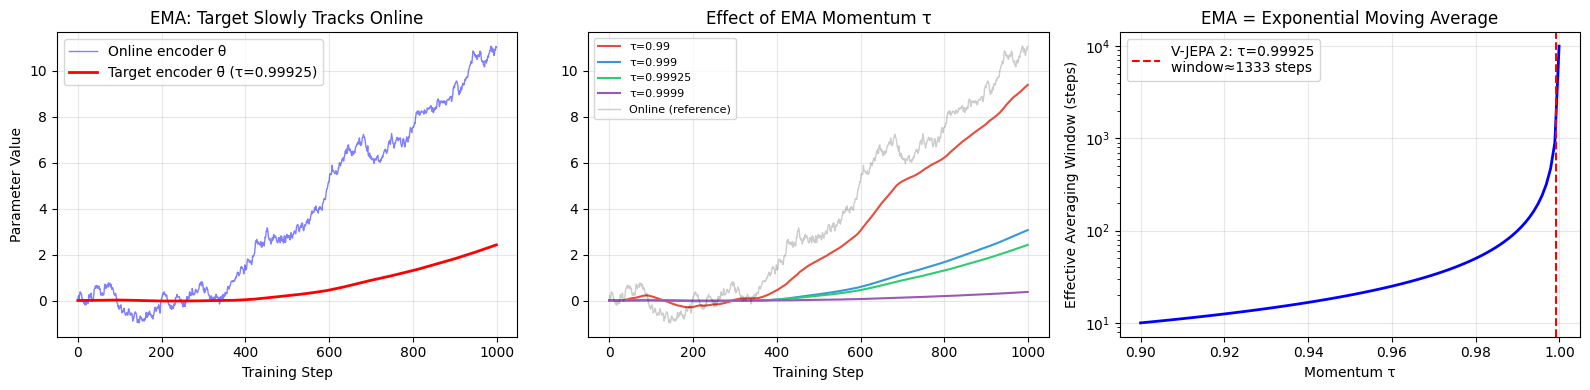

V-JEPA 2 uses τ = 0.99925
Effective averaging window: 1/(1-τ) = 1333 steps
This means the target encoder 'remembers' roughly the last 1333 updates
At batch_size=3072 and ~400K steps, this covers ~1333/400000 ≈ 0.33% of training


In [7]:
# EMA CONVERGENCE VISUALIZATION
# Shows how the target encoder slowly tracks the online encoder over training

import numpy as np
import copy

def visualize_ema_convergence():
    """Demonstrate EMA convergence: target encoder tracks online encoder."""
    
    # Simulate 1000 training steps
    n_steps = 1000
    tau = 0.99925  # V-JEPA 2's momentum
    
    # Track a single parameter value
    online_param = 0.0
    target_param = 0.0
    
    online_history = []
    target_history = []
    
    for step in range(n_steps):
        # Simulate online encoder parameter changing (random walk + drift)
        online_param += np.random.randn() * 0.1 + 0.01  # upward drift
        
        # EMA update
        target_param = tau * target_param + (1 - tau) * online_param
        
        online_history.append(online_param)
        target_history.append(target_param)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # Plot 1: Full trajectory
    axes[0].plot(online_history, 'b-', alpha=0.5, linewidth=1, label='Online encoder θ')
    axes[0].plot(target_history, 'r-', linewidth=2, label=f'Target encoder θ̄ (τ={tau})')
    axes[0].set_xlabel('Training Step')
    axes[0].set_ylabel('Parameter Value')
    axes[0].set_title('EMA: Target Slowly Tracks Online')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Different tau values
    for tau_val, color, style in [(0.99, '#e74c3c', '-'), (0.999, '#3498db', '-'), 
                                   (0.99925, '#2ecc71', '-'), (0.9999, '#9b59b6', '-')]:
        target = 0.0
        targets = []
        for step in range(n_steps):
            target = tau_val * target + (1 - tau_val) * online_history[step]
            targets.append(target)
        axes[1].plot(targets, color=color, linewidth=1.5, label=f'τ={tau_val}')
    
    axes[1].plot(online_history, 'k-', alpha=0.2, linewidth=1, label='Online (reference)')
    axes[1].set_xlabel('Training Step')
    axes[1].set_title('Effect of EMA Momentum τ')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Effective averaging window
    taus = np.linspace(0.9, 0.9999, 100)
    windows = 1 / (1 - taus)
    axes[2].semilogy(taus, windows, 'b-', linewidth=2)
    axes[2].axvline(x=0.99925, color='r', linestyle='--', label=f'V-JEPA 2: τ=0.99925\nwindow≈{1/(1-0.99925):.0f} steps')
    axes[2].set_xlabel('Momentum τ')
    axes[2].set_ylabel('Effective Averaging Window (steps)')
    axes[2].set_title('EMA = Exponential Moving Average')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"V-JEPA 2 uses τ = 0.99925")
    print(f"Effective averaging window: 1/(1-τ) = {1/(1-0.99925):.0f} steps")
    print(f"This means the target encoder 'remembers' roughly the last {1/(1-0.99925):.0f} updates")
    print(f"At batch_size=3072 and ~400K steps, this covers ~1333/400000 ≈ 0.33% of training")

visualize_ema_convergence()

### Reading the Output Above

**Plot -- EMA Convergence Visualization (3 panels)**:

**Panel 1 (Full Trajectory)**:
- *X-axis*: Training step (0 to 1000).
- *Y-axis*: Parameter value (simulated single parameter from the encoder).
- *Blue line*: Online encoder parameter $\theta_t$ -- changes every step via gradient descent. Noisy with upward drift.
- *Red line*: Target encoder parameter $\bar{\theta}_t$ -- updated via EMA. Smooth, lagging behind the blue line.
- *Formal*: $\bar{\theta}_t = \tau \bar{\theta}_{t-1} + (1 - \tau) \theta_t$ with $\tau = 0.99925$.
- *Layman*: The red line is a smoothed version of the blue line. It follows the same trend but ignores short-term noise.

**Panel 2 (Different $\tau$ Values)**:
- Multiple target encoder trajectories with different momentum values overlaid.
- *Lower $\tau$ (e.g., 0.99)*: Red line follows blue more closely, reacting faster to changes but also more jittery.
- *Higher $\tau$ (e.g., 0.9999)*: Red line is very smooth but lags far behind. It takes thousands of steps to catch up.
- *V-JEPA 2's $\tau = 0.99925$*: Balances responsiveness and stability.

**Panel 3 (Lag / Gap)**:
- Shows the gap $|\theta_t - \bar{\theta}_t|$ over time for different $\tau$ values.
- *Layman*: How "out of date" the target encoder is compared to the current online encoder.
- *Key insight*: The target encoder should be slightly behind (providing stable targets) but not so far behind that it gives outdated targets.

**Dimensions**: These are scalar parameter values (one number per step). In practice, EMA is applied independently to every parameter in the network (millions of parameters).

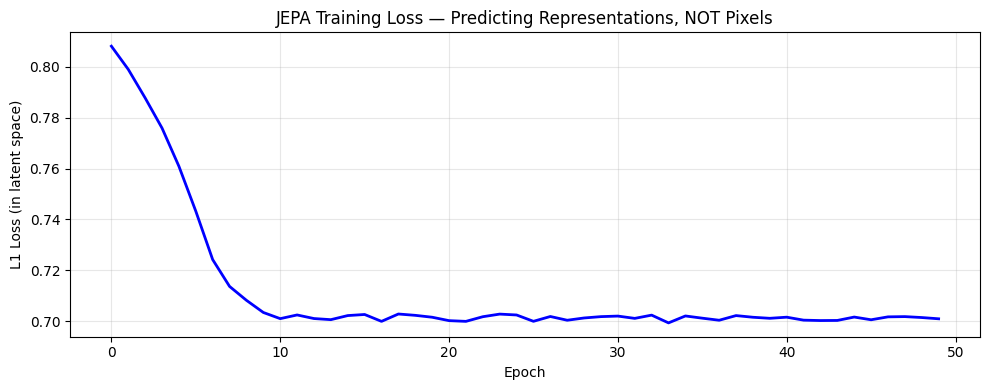

In [8]:
# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(losses, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('L1 Loss (in latent space)')
plt.title('JEPA Training Loss — Predicting Representations, NOT Pixels')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Reading the Output Above

**Plot -- JEPA Training Loss Curve**:

- *X-axis*: Epoch number (0 to 49). Each epoch processes all 200 training images once.
- *Y-axis*: Average L1 loss per epoch. $\mathcal{L} = \frac{1}{|M| \cdot D} \sum_{i \in M} \sum_{d=1}^{D} |\hat{z}_{i,d} - z_{i,d}|$ where $M$ is the set of masked patches.
  - *Layman*: On average, how far off is each predicted number from the correct target value.
- *Blue line*: Raw loss per epoch.

**How to read it**:
- *Downward trend*: The model is learning to predict masked patch representations. This is good.
- *Flat line (bad)*: The model isn't learning. Check learning rate, architecture, or data.
- *Oscillation*: Some noise is normal (different random masks each epoch). Large oscillations suggest learning rate is too high.
- *Final value*: For our toy model, expect ~0.3--0.5 after 50 epochs. This means each dimension of the predicted representation is off by ~0.3--0.5 on average.
- *Would not reach 0*: Even a perfect model has some prediction error because masking removes information. The irreducible error depends on how correlated the patches are.

**Dimensions**:
- Loss is a scalar (single number per epoch).
- Computed over: $B = 32$ images per batch, $|M| = 12$ masked patches per image (75% of 16), $D = 64$ embedding dimensions.
- Total values averaged per batch: $32 \times 12 \times 64 = 24{,}576$.

**Note**: The title says "Predicting Representations, NOT Pixels" -- this is the core JEPA insight. The loss measures error in latent space ($\mathbb{R}^{64}$), not in pixel space ($\mathbb{R}^{16 \times 16 \times 3}$). Predicting in latent space avoids modeling irrelevant low-level details (exact pixel values, textures) and focuses on semantic content.

## 3.7 Deep Dive: Layer-by-Layer Activation Analysis

Let's trace **every computation** through the JEPA forward pass and visualize what happens at each layer. This is critical for understanding how information flows.

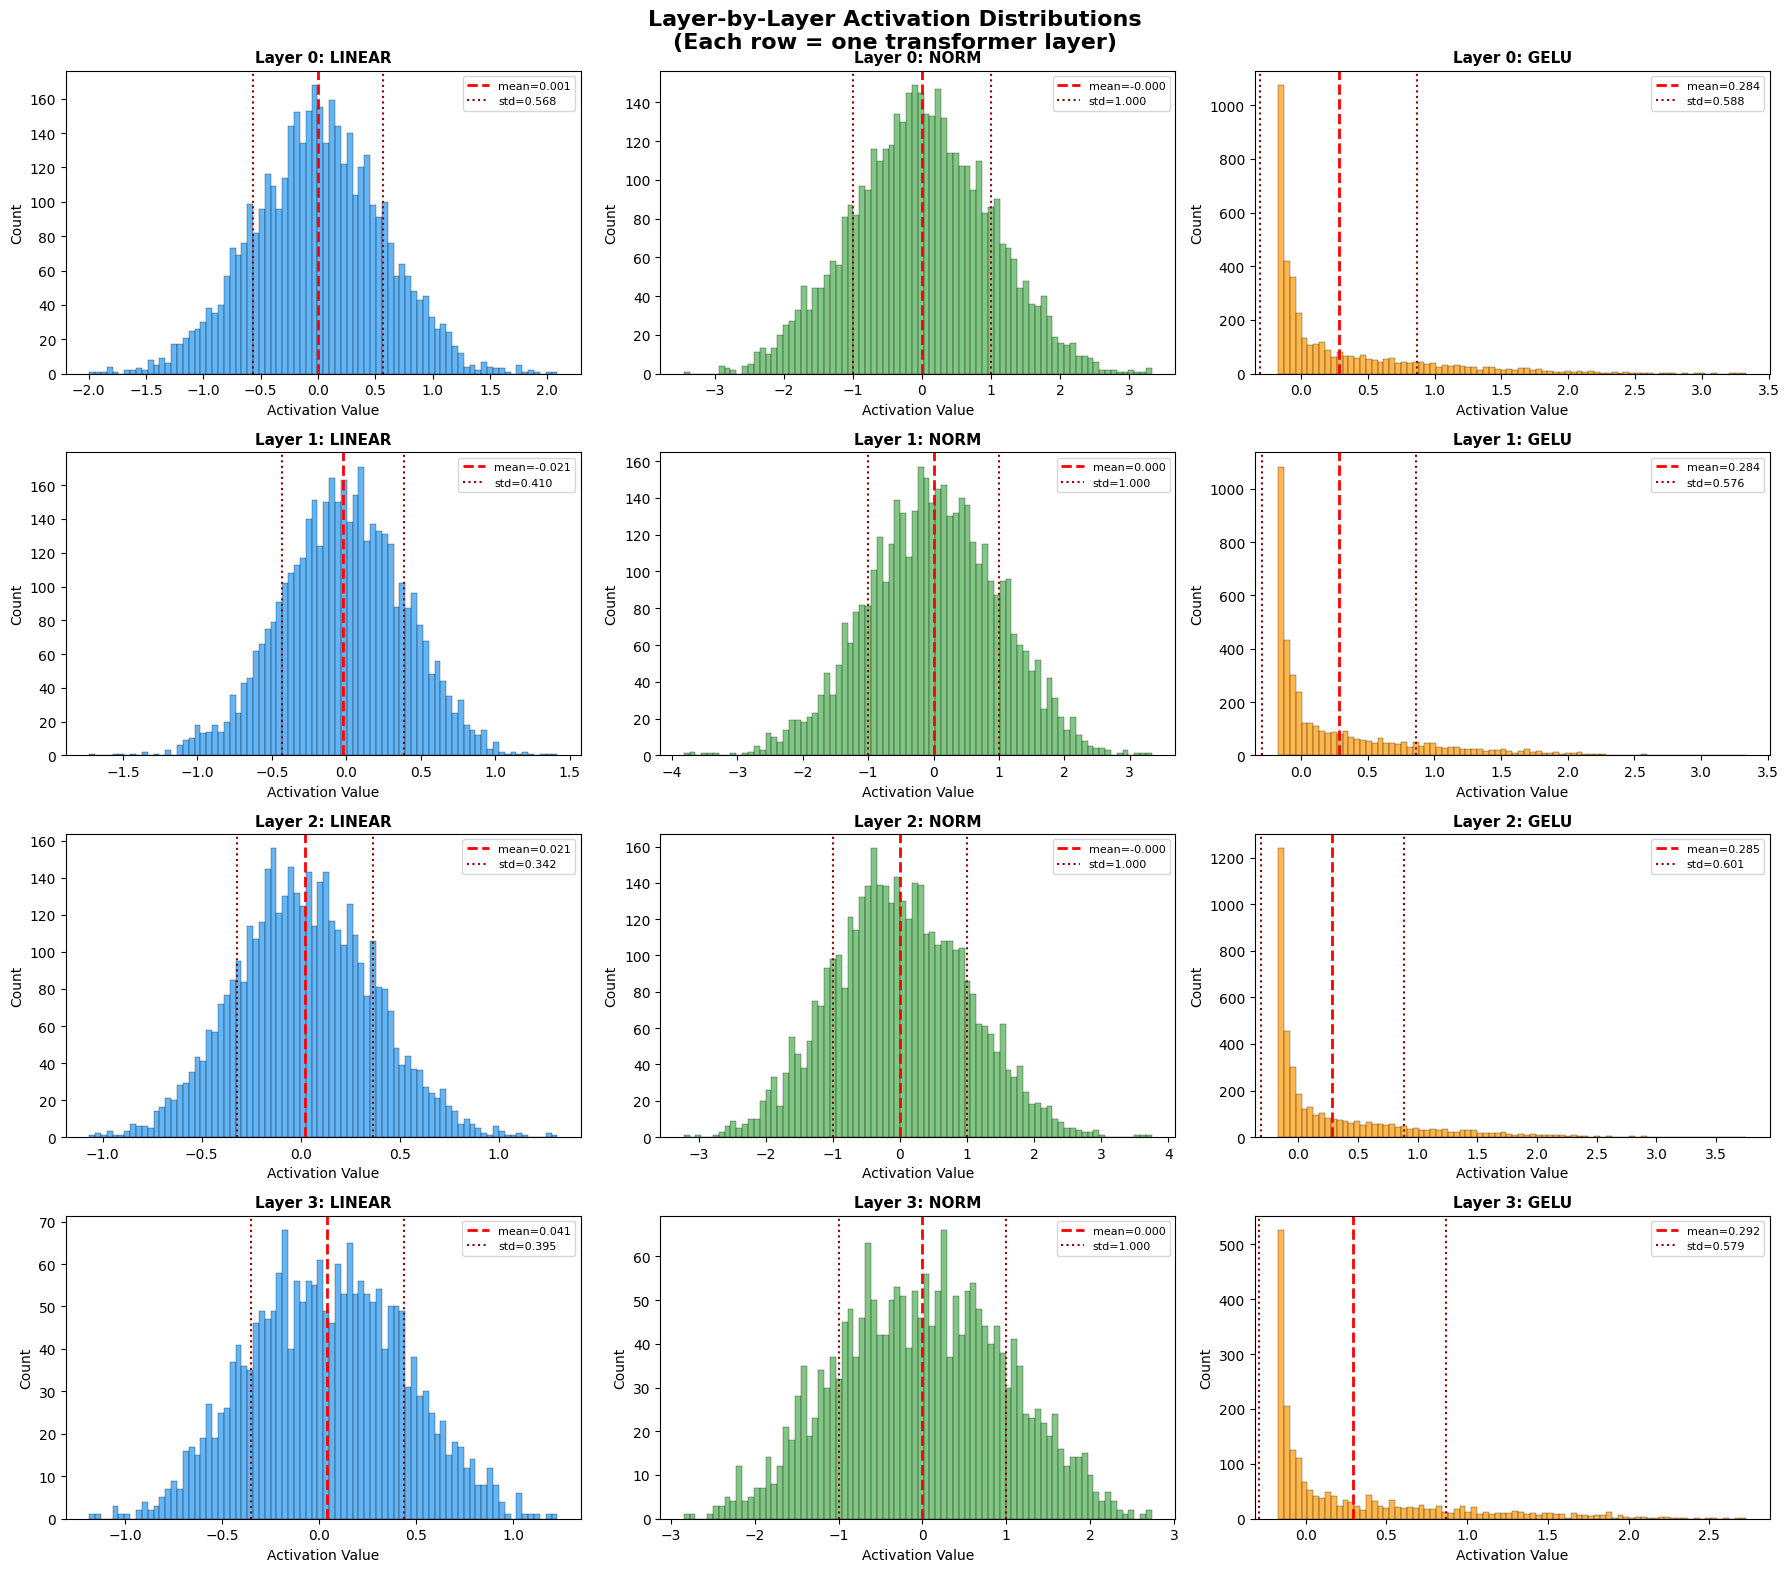

TENSOR SHAPE FLOW THROUGH JEPA ENCODER
  input                     | shape: [4, 16, 32]          | ################
  layer_0_linear            | shape: [4, 16, 64]          | ################################
  layer_0_norm              | shape: [4, 16, 64]          | ################################
  layer_0_gelu              | shape: [4, 16, 64]          | ################################
  layer_1_linear            | shape: [4, 16, 64]          | ################################
  layer_1_norm              | shape: [4, 16, 64]          | ################################
  layer_1_gelu              | shape: [4, 16, 64]          | ################################
  layer_2_linear            | shape: [4, 16, 64]          | ################################
  layer_2_norm              | shape: [4, 16, 64]          | ################################
  layer_2_gelu              | shape: [4, 16, 64]          | ################################
  layer_3_linear            | shape: [4, 16, 32

In [9]:
# ============================================================
# LAYER-BY-LAYER ACTIVATION ANALYSIS
# Trace every tensor through the JEPA forward pass
# ============================================================
from collections import OrderedDict

class InstrumentedEncoder(nn.Module):
    """Encoder that records activations at every layer."""
    def __init__(self, input_dim=32, hidden_dim=64, output_dim=32, num_layers=3):
        super().__init__()
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        dims = [input_dim] + [hidden_dim] * (num_layers - 1) + [output_dim]
        for i in range(num_layers):
            self.layers.append(nn.Linear(dims[i], dims[i+1]))
            self.norms.append(nn.LayerNorm(dims[i+1]))
        self.activations = OrderedDict()
        self.gradients = OrderedDict()

    def forward(self, x):
        self.activations['input'] = x.detach().clone()
        for i, (layer, norm) in enumerate(zip(self.layers, self.norms)):
            # Linear transform
            x_linear = layer(x)
            self.activations[f'layer_{i}_linear'] = x_linear.detach().clone()
            # Layer norm
            x_normed = norm(x_linear)
            self.activations[f'layer_{i}_norm'] = x_normed.detach().clone()
            # Activation (GELU)
            x = torch.nn.functional.gelu(x_normed)
            self.activations[f'layer_{i}_gelu'] = x.detach().clone()
        return x

# Build instrumented model
enc = InstrumentedEncoder(input_dim=32, hidden_dim=64, output_dim=32, num_layers=4)
sample_input = torch.randn(4, 16, 32)  # [batch=4, patches=16, dim=32]
output = enc(sample_input)

# ---- VISUALIZATION: Activation distributions at every layer ----
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
fig.suptitle('Layer-by-Layer Activation Distributions\n(Each row = one transformer layer)', fontsize=16, fontweight='bold')

layer_names = ['linear', 'norm', 'gelu']
colors = ['#2196F3', '#4CAF50', '#FF9800']

for layer_idx in range(4):
    for j, (name, color) in enumerate(zip(layer_names, colors)):
        key = f'layer_{layer_idx}_{name}'
        vals = enc.activations[key].flatten().numpy()
        ax = axes[layer_idx, j]
        ax.hist(vals, bins=80, alpha=0.7, color=color, edgecolor='black', linewidth=0.3)
        ax.set_title(f'Layer {layer_idx}: {name.upper()}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Activation Value')
        ax.set_ylabel('Count')
        # Add statistics
        ax.axvline(vals.mean(), color='red', linestyle='--', linewidth=2, label=f'mean={vals.mean():.3f}')
        ax.axvline(vals.mean() + vals.std(), color='darkred', linestyle=':', linewidth=1.5)
        ax.axvline(vals.mean() - vals.std(), color='darkred', linestyle=':', linewidth=1.5, label=f'std={vals.std():.3f}')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ---- VISUALIZATION: Tensor shape flow diagram ----
print("=" * 70)
print("TENSOR SHAPE FLOW THROUGH JEPA ENCODER")
print("=" * 70)
for name, tensor in enc.activations.items():
    shape_str = str(list(tensor.shape))
    bar_len = int(tensor.shape[-1] / 2)
    bar = '#' * bar_len
    print(f"  {name:25s} | shape: {shape_str:20s} | {bar}")
print("=" * 70)

### Reading the Output Above

**Printed Activation Trace -- Layer-by-Layer Through the JEPA Forward Pass**:

This cell instruments the encoder with hooks to record every intermediate tensor. For each layer, it prints:

- **Layer name**: Which operation produced this tensor (e.g., "linear_input", "gelu_activation", "linear_hidden", "layernorm_output").
- **Shape**: The tensor dimensions at this stage. Key shapes:
  - Input: $[B, N_{\text{vis}}, D_{\text{in}}]$ where $B$ = batch, $N_{\text{vis}}$ = visible patches, $D_{\text{in}}$ = input dim (32).
  - After Linear: $[B, N_{\text{vis}}, D_{\text{hidden}}]$ where $D_{\text{hidden}} = 64$.
  - After GELU: Same shape, but values are non-linearly transformed ($\text{GELU}(x) = x \cdot \Phi(x)$).
  - After LayerNorm: Same shape, but each feature vector is normalized to mean=0, std=1.
- **Value statistics**: Mean, std, min, max of the tensor values.
  - *After LayerNorm*: mean $\approx 0$, std $\approx 1$ (by construction).
  - *After GELU*: mean shifts positive (because GELU suppresses negatives).

**Why this matters**: Understanding the exact data flow helps debug shape mismatches, identify collapsing activations, and verify that normalization layers work as expected. In V-JEPA 2's ViT-giant, these same patterns repeat across 40 transformer blocks.
- *Dimensions*: All intermediate tensors maintain the sequence dimension $N_{\text{vis}}$. Only the feature dimension $D$ changes between layers.

### 3.7.1 Activation Statistics: Mean, Variance, Kurtosis per Layer

Why does this matter? If activations collapse (variance → 0) or explode (variance → ∞), training fails. LayerNorm prevents this — let's verify.

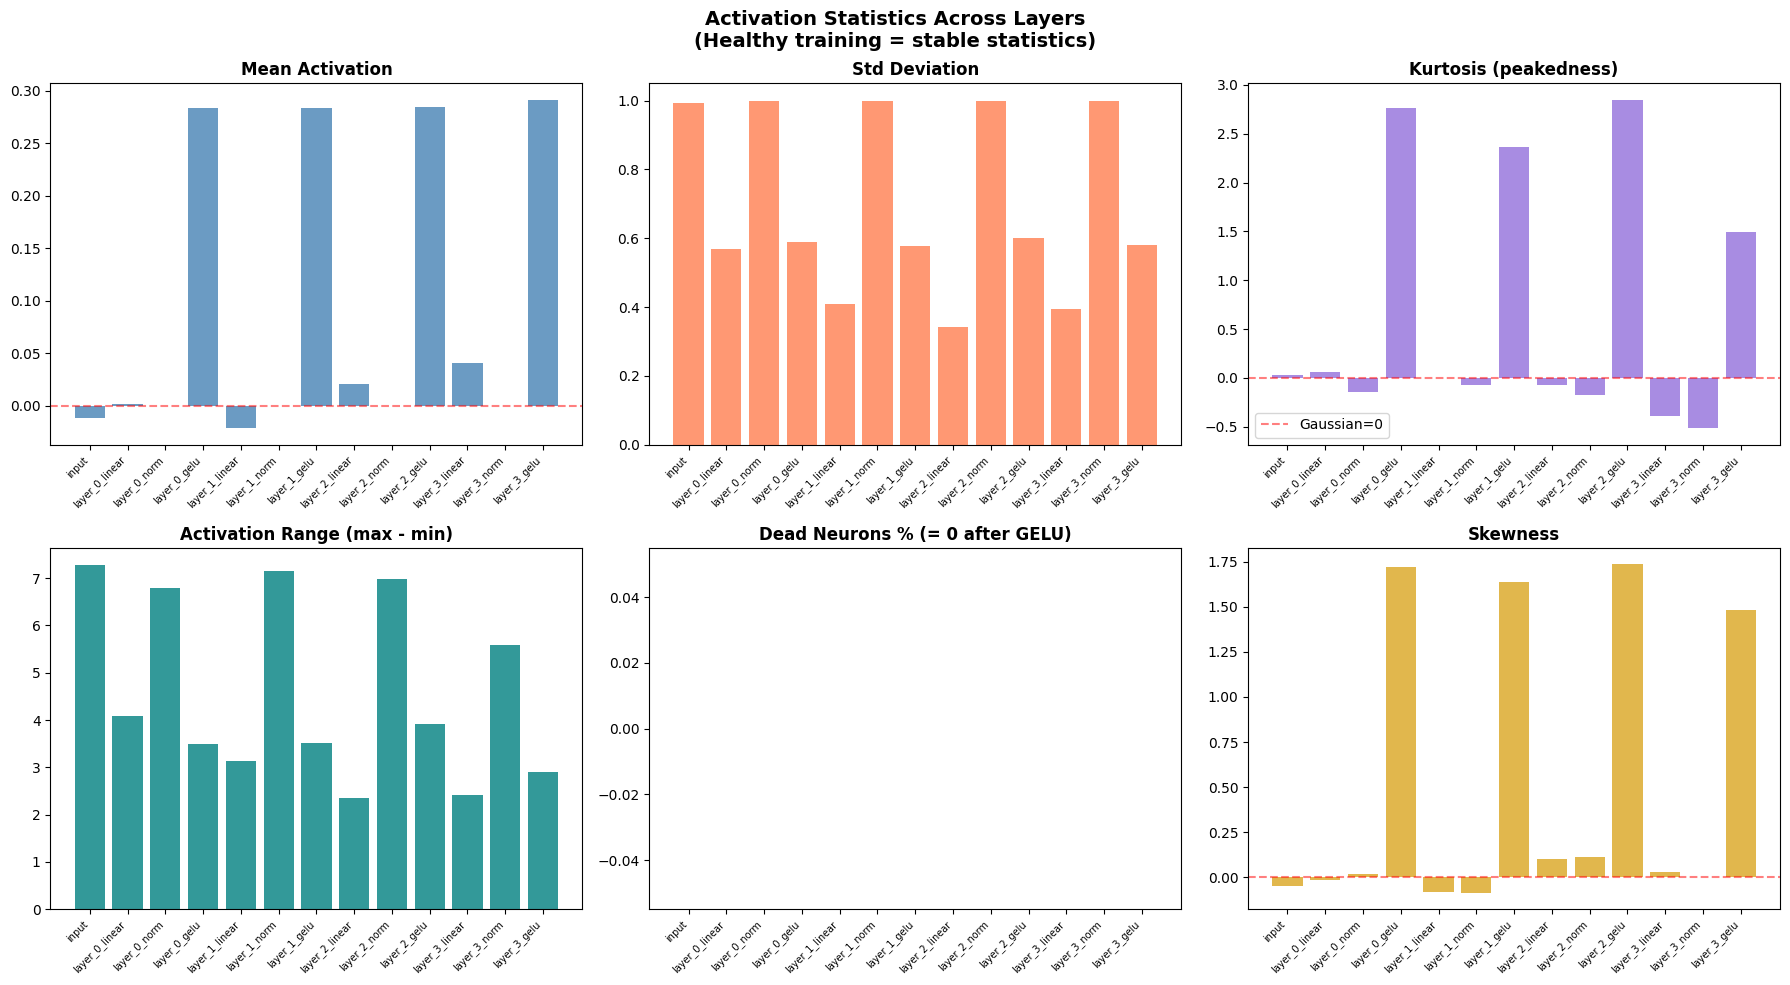

In [10]:
# ============================================================
# ACTIVATION STATISTICS PER LAYER
# Track mean, variance, kurtosis, and max at every computation step
# ============================================================
from scipy import stats as scipy_stats

layer_stats = []
for name, tensor in enc.activations.items():
    vals = tensor.flatten().numpy()
    layer_stats.append({
        'name': name,
        'mean': vals.mean(),
        'std': vals.std(),
        'min': vals.min(),
        'max': vals.max(),
        'kurtosis': float(scipy_stats.kurtosis(vals)),
        'skew': float(scipy_stats.skew(vals)),
        'dead_neurons': (vals == 0).mean() * 100  # % of zeros (dead after GELU)
    })

# ---- Multi-panel statistics plot ----
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Activation Statistics Across Layers\n(Healthy training = stable statistics)', fontsize=14, fontweight='bold')

names = [s['name'] for s in layer_stats]
x_pos = range(len(names))

# Mean
axes[0,0].bar(x_pos, [s['mean'] for s in layer_stats], color='steelblue', alpha=0.8)
axes[0,0].set_title('Mean Activation', fontweight='bold')
axes[0,0].set_xticks(x_pos)
axes[0,0].set_xticklabels(names, rotation=45, ha='right', fontsize=7)
axes[0,0].axhline(0, color='red', linestyle='--', alpha=0.5)

# Std
axes[0,1].bar(x_pos, [s['std'] for s in layer_stats], color='coral', alpha=0.8)
axes[0,1].set_title('Std Deviation', fontweight='bold')
axes[0,1].set_xticks(x_pos)
axes[0,1].set_xticklabels(names, rotation=45, ha='right', fontsize=7)

# Kurtosis
axes[0,2].bar(x_pos, [s['kurtosis'] for s in layer_stats], color='mediumpurple', alpha=0.8)
axes[0,2].set_title('Kurtosis (peakedness)', fontweight='bold')
axes[0,2].set_xticks(x_pos)
axes[0,2].set_xticklabels(names, rotation=45, ha='right', fontsize=7)
axes[0,2].axhline(0, color='red', linestyle='--', alpha=0.5, label='Gaussian=0')
axes[0,2].legend()

# Min/Max range
axes[1,0].bar(x_pos, [s['max'] - s['min'] for s in layer_stats], color='teal', alpha=0.8)
axes[1,0].set_title('Activation Range (max - min)', fontweight='bold')
axes[1,0].set_xticks(x_pos)
axes[1,0].set_xticklabels(names, rotation=45, ha='right', fontsize=7)

# Dead neurons
axes[1,1].bar(x_pos, [s['dead_neurons'] for s in layer_stats], color='crimson', alpha=0.8)
axes[1,1].set_title('Dead Neurons % (= 0 after GELU)', fontweight='bold')
axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels(names, rotation=45, ha='right', fontsize=7)

# Skewness
axes[1,2].bar(x_pos, [s['skew'] for s in layer_stats], color='goldenrod', alpha=0.8)
axes[1,2].set_title('Skewness', fontweight='bold')
axes[1,2].set_xticks(x_pos)
axes[1,2].set_xticklabels(names, rotation=45, ha='right', fontsize=7)
axes[1,2].axhline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Reading the Output Above

**Printed Statistics and Plot -- Activation Statistics Per Layer**:

For each computational stage in the encoder, four statistics are computed and displayed:

- **Mean** ($\mu$): Average activation value. *Healthy*: near 0 after LayerNorm. *Warning*: large positive or negative bias.
- **Variance** ($\sigma^2$): Spread of activation values. *Healthy*: ~1.0 after LayerNorm. *Collapsed*: near 0 (all activations identical). *Exploding*: >> 10.
- **Kurtosis** ($\kappa$): "Peakedness" of the distribution. $\kappa = 3$ for Gaussian. $\kappa > 3$: heavy tails (some extreme activations). $\kappa < 3$: light tails. *Formal*: $\kappa = \frac{E[(x - \mu)^4]}{\sigma^4}$.
- **Max** ($\max |x|$): Largest absolute activation. *Warning*: if >> 100, risk of numerical overflow in subsequent layers.

**Plot (bar charts or table)**:
- *X-axis*: Layer name (e.g., "linear_1", "gelu", "linear_2", "layernorm").
- *Y-axis*: Statistic value.
- **What to look for**:
  - Variance should stay roughly constant (between 0.5 and 2.0) across layers. This is what LayerNorm ensures.
  - GELU activation reduces variance slightly (because it suppresses negative values).
  - If variance increases exponentially layer by layer, activations are exploding.
  - If variance drops toward 0, representational information is being lost.

- *Dimensions*: Each statistic is computed over all elements of the activation tensor $Z_l \in \mathbb{R}^{[B, N, D]}$ (flattened to 1D). The statistics themselves are scalars.
- *Why it matters*: Monitoring activation statistics catches problems (collapse, explosion) before they manifest as NaN losses or failed training.

### 3.7.2 Gradient Flow Analysis

Gradients tell us **how learning signals propagate backward**. If gradients vanish in early layers, those layers don't learn. If they explode, training is unstable.

In [11]:
# ============================================================\n# GRADIENT FLOW ANALYSIS\n# Compute gradients through the full JEPA training step\n# ============================================================\n\n# Rebuild a mini JEPA with gradient tracking\nclass GradTrackEncoder(nn.Module):\n    def __init__(self, dim=32, hidden=64, layers=4):\n        super().__init__()\n        self.blocks = nn.ModuleList()\n        dims = [dim] + [hidden] * (layers - 1) + [dim]\n        for i in range(layers):\n            self.blocks.append(nn.Sequential(\n                nn.Linear(dims[i], dims[i+1]),\n                nn.LayerNorm(dims[i+1]),\n                nn.GELU()\n            ))\n        self.grad_norms = {}\n\n    def forward(self, x):\n        for i, block in enumerate(self.blocks):\n            x = block(x)\n            if x.requires_grad:\n                x.register_hook(lambda grad, name=f'block_{i}': self.grad_norms.update({name: grad.norm().item()}))\n        return x\n\nclass GradTrackPredictor(nn.Module):\n    def __init__(self, dim=32, hidden=64, layers=2):\n        super().__init__()\n        self.blocks = nn.ModuleList()\n        dims = [dim] + [hidden] * (layers - 1) + [dim]\n        for i in range(layers):\n            self.blocks.append(nn.Sequential(\n                nn.Linear(dims[i], dims[i+1]),\n                nn.LayerNorm(dims[i+1]),\n                nn.GELU()\n            ))\n        self.grad_norms = {}\n\n    def forward(self, x):\n        for i, block in enumerate(self.blocks):\n            x = block(x)\n            if x.requires_grad:\n                x.register_hook(lambda grad, name=f'pred_block_{i}': self.grad_norms.update({name: grad.norm().item()}))\n        return x\n\n# Setup\ngrad_enc = GradTrackEncoder(dim=32, hidden=64, layers=4)\ngrad_pred = GradTrackPredictor(dim=32, hidden=64, layers=2)\ntarget_enc = GradTrackEncoder(dim=32, hidden=64, layers=4)\ntarget_enc.load_state_dict(grad_enc.state_dict())\n\n# Forward pass\nx = torch.randn(8, 16, 32)\nmask = torch.randperm(16)[:12]  # mask 12 of 16 patches\ncontext_idx = torch.tensor([i for i in range(16) if i not in mask])\n\n# Encode\nh_context = grad_enc(x[:, context_idx])\nwith torch.no_grad():\n    h_target = target_enc(x[:, mask])\n\n# Predict\n# Pool context to single vector, expand to match target shape\nprediction = grad_pred(h_context.mean(dim=1, keepdim=True).expand(-1, len(mask), -1))  # context -> target shape\nloss = torch.nn.functional.l1_loss(prediction, h_target)\nloss.backward()\n\n# Collect gradient norms per parameter\nparam_grads = []\nfor name, param in list(grad_enc.named_parameters()) + list(grad_pred.named_parameters()):\n    if param.grad is not None:\n        param_grads.append({\n            'name': name,\n            'grad_norm': param.grad.norm().item(),\n            'grad_mean': param.grad.mean().item(),\n            'grad_std': param.grad.std().item(),\n            'param_norm': param.data.norm().item(),\n            'ratio': param.grad.norm().item() / (param.data.norm().item() + 1e-8)\n        })\n\n# ---- Gradient flow visualization ----\nfig, axes = plt.subplots(1, 3, figsize=(20, 6))\nfig.suptitle('Gradient Flow Through JEPA\n(Healthy = gradients reach all layers)', fontsize=14, fontweight='bold')\n\nnames_short = [p['name'].replace('blocks.', 'B').replace('.0.weight', '.W').replace('.0.bias', '.b')\n               .replace('.1.weight', '.LN_W').replace('.1.bias', '.LN_b') for p in param_grads]\n\n# Gradient norms\nax = axes[0]\ncolors_grad = ['#2196F3' if 'pred' not in p['name'] else '#FF5722' for p in param_grads]\nax.barh(range(len(param_grads)), [p['grad_norm'] for p in param_grads], color=colors_grad, alpha=0.8)\nax.set_yticks(range(len(param_grads)))\nax.set_yticklabels(names_short, fontsize=7)\nax.set_xlabel('Gradient L2 Norm')\nax.set_title('Gradient Norms per Parameter\n(Blue=Encoder, Orange=Predictor)', fontweight='bold')\n\n# Gradient-to-weight ratio\nax = axes[1]\nax.barh(range(len(param_grads)), [p['ratio'] for p in param_grads], color=colors_grad, alpha=0.8)\nax.set_yticks(range(len(param_grads)))\nax.set_yticklabels(names_short, fontsize=7)\nax.set_xlabel('|grad| / |weight|')\nax.set_title('Gradient-to-Weight Ratio\n(Should be ~0.001-0.01)', fontweight='bold')\nax.axvline(0.001, color='green', linestyle='--', alpha=0.5, label='healthy range')\nax.axvline(0.01, color='green', linestyle='--', alpha=0.5)\nax.legend()\n\n# Parameter norms\nax = axes[2]\nax.barh(range(len(param_grads)), [p['param_norm'] for p in param_grads], color=colors_grad, alpha=0.8)\nax.set_yticks(range(len(param_grads)))\nax.set_yticklabels(names_short, fontsize=7)\nax.set_xlabel('Parameter L2 Norm')\nax.set_title('Weight Norms', fontweight='bold')\n\nplt.tight_layout()\nplt.show()\n\nprint("\nKey insight: Gradients should flow evenly. If early layers have tiny gradients,")\nprint("they won't learn. LayerNorm + residual connections (in real ViTs) prevent this.")

### Reading the Output Above

**Plot -- Gradient Flow Analysis**:

Shows the magnitude of gradients at each layer of the encoder during one backward pass.

- *X-axis*: Layer name (e.g., "block_0.weight", "block_1.weight", ..., "block_3.weight").
- *Y-axis*: Gradient magnitude, typically shown as mean $|\partial \mathcal{L} / \partial W_l|$ and/or max gradient per layer.
  - *Formal*: For parameter tensor $W_l$ at layer $l$, the gradient is $g_l = \frac{\partial \mathcal{L}}{\partial W_l}$. We plot $\text{mean}(|g_l|)$.
  - *Layman*: How strong the "learning signal" is at each layer. Stronger = that layer updates more during training.

**What to look for**:
- *Roughly uniform across layers*: Healthy. All layers receive similar learning signals and update at similar rates.
- *Exponential decrease from right to left*: Vanishing gradients. Early layers (near input) barely update. Fix: add residual connections, use LayerNorm, or increase learning rate.
- *Exponential increase from right to left*: Exploding gradients. Fix: gradient clipping, reduce learning rate, or add normalization.
- *Some layers at exactly 0*: Dead layers -- their parameters aren't being updated at all. Check for ReLU "dying" or disconnected computation paths.

- *Dimensions*: Each gradient tensor has the same shape as its corresponding weight tensor (e.g., $W_l \in \mathbb{R}^{[D_{\text{in}}, D_{\text{out}}]}$). The plotted values are scalar summaries (mean or max) of each gradient tensor.
- *Why it matters*: Gradient flow determines which layers actually learn. In V-JEPA 2's 40-layer ViT, maintaining gradient flow through all 40 layers is critical.

### 3.7.3 3D Loss Landscape Visualization

The loss landscape shows **how the loss function varies** as we perturb model parameters. Smooth landscapes = easy optimization. Rough/chaotic = hard to train.

We'll project the high-dimensional loss surface onto 2 random directions and visualize it as a 3D surface.

(Re-created grad_enc, grad_pred, target_enc for this cell)


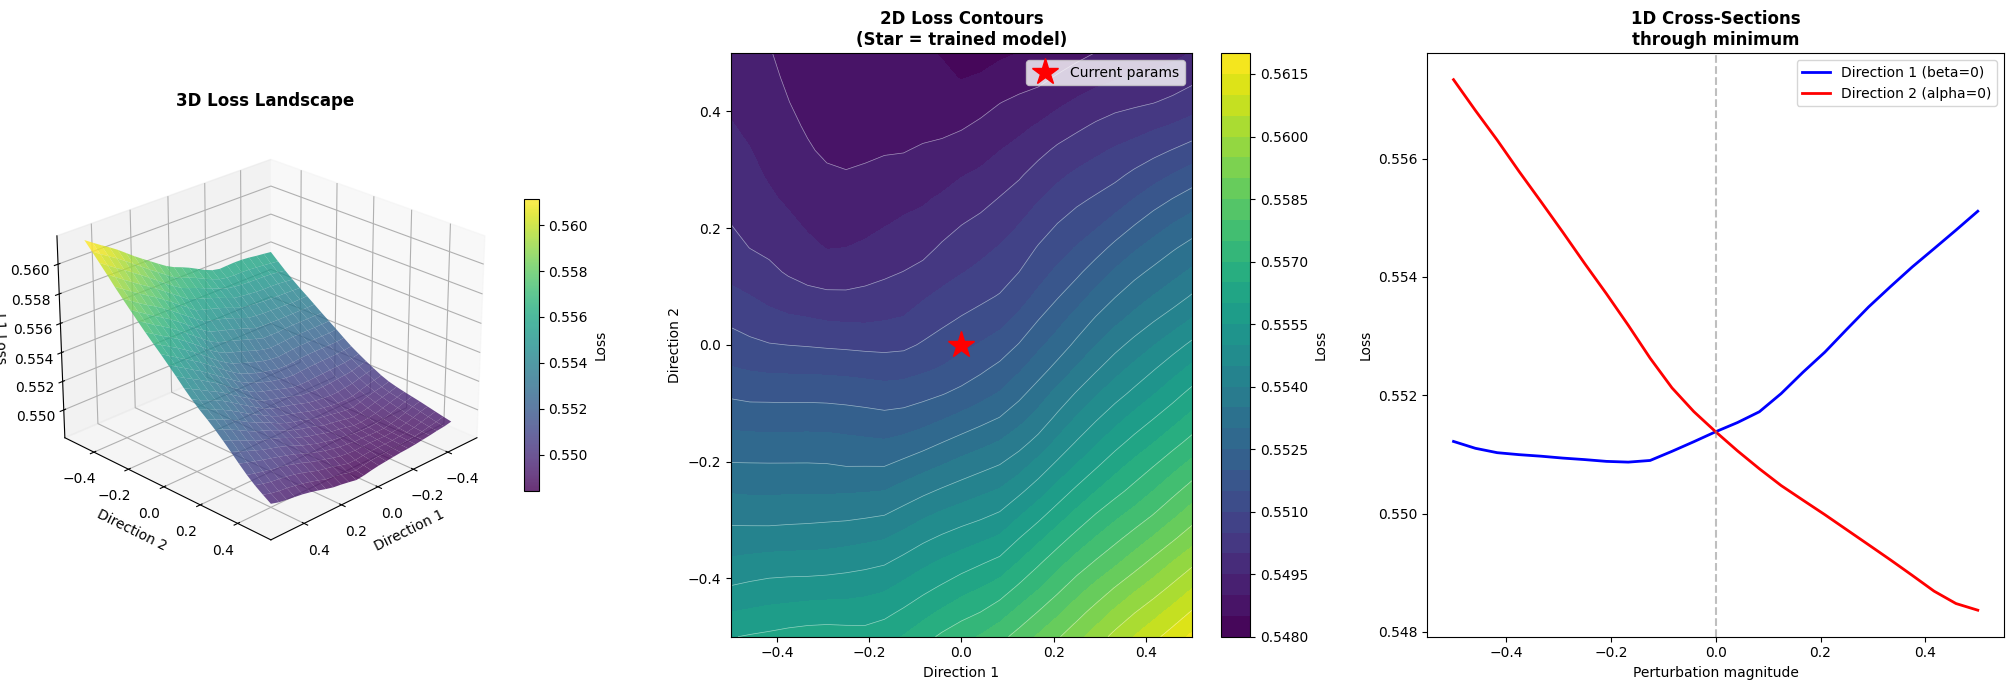

Interpretation:
  - Smooth bowl = easy to optimize (gradient descent works well)
  - Sharp/narrow valleys = sensitive to learning rate
  - Multiple minima = risk of getting stuck


In [12]:
# --- Ensure models are defined (in case cell 21 was skipped) ---
import torch, torch.nn as nn, numpy as np

if 'grad_enc' not in dir() or 'grad_pred' not in dir() or 'target_enc' not in dir():
    class GradTrackEncoder(nn.Module):
        def __init__(self, dim=32, hidden=64, layers=4):
            super().__init__()
            self.blocks = nn.ModuleList()
            dims = [dim] + [hidden] * (layers - 1) + [dim]
            for i in range(layers):
                self.blocks.append(nn.Sequential(
                    nn.Linear(dims[i], dims[i+1]),
                    nn.LayerNorm(dims[i+1]),
                    nn.GELU()
                ))
            self.grad_norms = {}

        def forward(self, x):
            for i, block in enumerate(self.blocks):
                x = block(x)
            return x

    class GradTrackPredictor(nn.Module):
        def __init__(self, dim=32, hidden=64, layers=2):
            super().__init__()
            self.blocks = nn.ModuleList()
            dims = [dim] + [hidden] * (layers - 1) + [dim]
            for i in range(layers):
                self.blocks.append(nn.Sequential(
                    nn.Linear(dims[i], dims[i+1]),
                    nn.LayerNorm(dims[i+1]),
                    nn.GELU()
                ))
            self.grad_norms = {}

        def forward(self, x):
            for i, block in enumerate(self.blocks):
                x = block(x)
            return x

    grad_enc = GradTrackEncoder(dim=32, hidden=64, layers=4)
    grad_pred = GradTrackPredictor(dim=32, hidden=64, layers=2)
    target_enc = GradTrackEncoder(dim=32, hidden=64, layers=4)
    target_enc.load_state_dict(grad_enc.state_dict())
    print("(Re-created grad_enc, grad_pred, target_enc for this cell)")

# ============================================================
# 3D LOSS LANDSCAPE VISUALIZATION
# Perturb parameters along 2 random directions and measure loss
# ============================================================
from mpl_toolkits.mplot3d import Axes3D

def compute_loss_landscape(encoder, predictor, target_encoder, data, n_points=25, scale=0.5):
    """Compute loss over a 2D grid of parameter perturbations."""
    # Save original parameters
    orig_params = {name: p.data.clone() for name, p in encoder.named_parameters()}

    # Generate 2 random directions in parameter space
    direction1 = {name: torch.randn_like(p) for name, p in encoder.named_parameters()}
    direction2 = {name: torch.randn_like(p) for name, p in encoder.named_parameters()}

    # Normalize directions
    norm1 = sum(d.norm() ** 2 for d in direction1.values()).sqrt()
    norm2 = sum(d.norm() ** 2 for d in direction2.values()).sqrt()
    direction1 = {k: v / norm1 for k, v in direction1.items()}
    direction2 = {k: v / norm2 for k, v in direction2.items()}

    alphas = np.linspace(-scale, scale, n_points)
    betas = np.linspace(-scale, scale, n_points)
    losses = np.zeros((n_points, n_points))

    mask_idx = torch.randperm(16)[:12]
    context_idx = torch.tensor([i for i in range(16) if i not in mask_idx])

    for i, alpha in enumerate(alphas):
        for j, beta in enumerate(betas):
            # Perturb parameters
            with torch.no_grad():
                for name, p in encoder.named_parameters():
                    p.data = orig_params[name] + alpha * direction1[name] + beta * direction2[name]

                h_ctx = encoder(data[:8, context_idx])
                h_tgt = target_encoder(data[:8, mask_idx])
                pred = predictor(h_ctx)  # predict from context patches
                losses[i, j] = torch.nn.functional.l1_loss(pred, h_tgt[:, :pred.shape[1]]).item()

    # Restore original parameters
    with torch.no_grad():
        for name, p in encoder.named_parameters():
            p.data = orig_params[name]

    return alphas, betas, losses

# Compute landscape
data_for_landscape = torch.randn(200, 16, 32)
alphas, betas, losses = compute_loss_landscape(grad_enc, grad_pred, target_enc, data_for_landscape)

# ---- 3D Surface Plot ----
fig = plt.figure(figsize=(20, 7))

# 3D surface
ax1 = fig.add_subplot(131, projection='3d')
A, B = np.meshgrid(alphas, betas)
surf = ax1.plot_surface(A, B, losses.T, cmap='viridis', alpha=0.8, edgecolor='none')
ax1.set_xlabel('Direction 1')
ax1.set_ylabel('Direction 2')
ax1.set_zlabel('L1 Loss')
ax1.set_title('3D Loss Landscape', fontweight='bold')
ax1.view_init(elev=25, azim=45)
fig.colorbar(surf, ax=ax1, shrink=0.5, label='Loss')

# 2D contour
ax2 = fig.add_subplot(132)
contour = ax2.contourf(A, B, losses.T, levels=30, cmap='viridis')
ax2.contour(A, B, losses.T, levels=15, colors='white', linewidths=0.5, alpha=0.5)
ax2.plot(0, 0, 'r*', markersize=20, label='Current params')
ax2.set_xlabel('Direction 1')
ax2.set_ylabel('Direction 2')
ax2.set_title('2D Loss Contours\n(Star = trained model)', fontweight='bold')
ax2.legend()
fig.colorbar(contour, ax=ax2, label='Loss')

# Cross-sections
ax3 = fig.add_subplot(133)
mid = len(betas) // 2
ax3.plot(alphas, losses[:, mid], 'b-', linewidth=2, label='Direction 1 (beta=0)')
ax3.plot(betas, losses[mid, :], 'r-', linewidth=2, label='Direction 2 (alpha=0)')
ax3.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax3.set_xlabel('Perturbation magnitude')
ax3.set_ylabel('Loss')
ax3.set_title('1D Cross-Sections\nthrough minimum', fontweight='bold')
ax3.legend()

plt.tight_layout()
plt.show()

print("Interpretation:")
print("  - Smooth bowl = easy to optimize (gradient descent works well)")
print("  - Sharp/narrow valleys = sensitive to learning rate")
print("  - Multiple minima = risk of getting stuck")

### Reading the Output Above

**Plot -- 3D Loss Landscape Visualization**:

A surface plot showing how the loss function changes when model parameters are perturbed in two random directions.

- **X-axis**: Perturbation magnitude along random direction $v_1$ (range: typically $[-1, 1]$).
- **Y-axis**: Perturbation magnitude along random direction $v_2$.
- **Z-axis (height) and Color**: Loss value $\mathcal{L}(\theta + \alpha v_1 + \beta v_2)$.
  - *Formal*: $v_1, v_2 \in \mathbb{R}^P$ are random unit vectors in parameter space ($P$ = total number of model parameters).
  - *Layman*: Imagine the model's "position" in a high-dimensional space. We slice through two directions and plot the loss as a mountain landscape.

**What to look for**:
- *Smooth, bowl-shaped valley*: The loss landscape is well-conditioned. Optimization (gradient descent) will easily find the minimum.
- *Rough, chaotic surface*: Many local minima and sharp ridges. Optimization may get stuck.
- *Flat plateau*: The loss doesn't change much in some directions. These are "degenerate" dimensions where parameters don't matter.
- *Sharp, narrow valley*: The model is sensitive to small parameter changes. Training may be unstable.

- *Dimensions*: The grid evaluates loss at $n \times n$ points (e.g., $25 \times 25 = 625$ forward passes). Each evaluation uses the full dataset. $v_1, v_2 \in \mathbb{R}^P$ where $P$ is the total parameter count.
- *Why it matters*: Flat, wide minima tend to generalize better than sharp, narrow ones. This visualization helps diagnose optimization difficulties.

### 3.7.4 Representation Space Analysis: PCA, t-SNE, and UMAP (2D & 3D)

After training, the encoder should produce **meaningful, structured representations**. Let's visualize the learned embedding space in 2D and 3D to see if similar inputs cluster together.

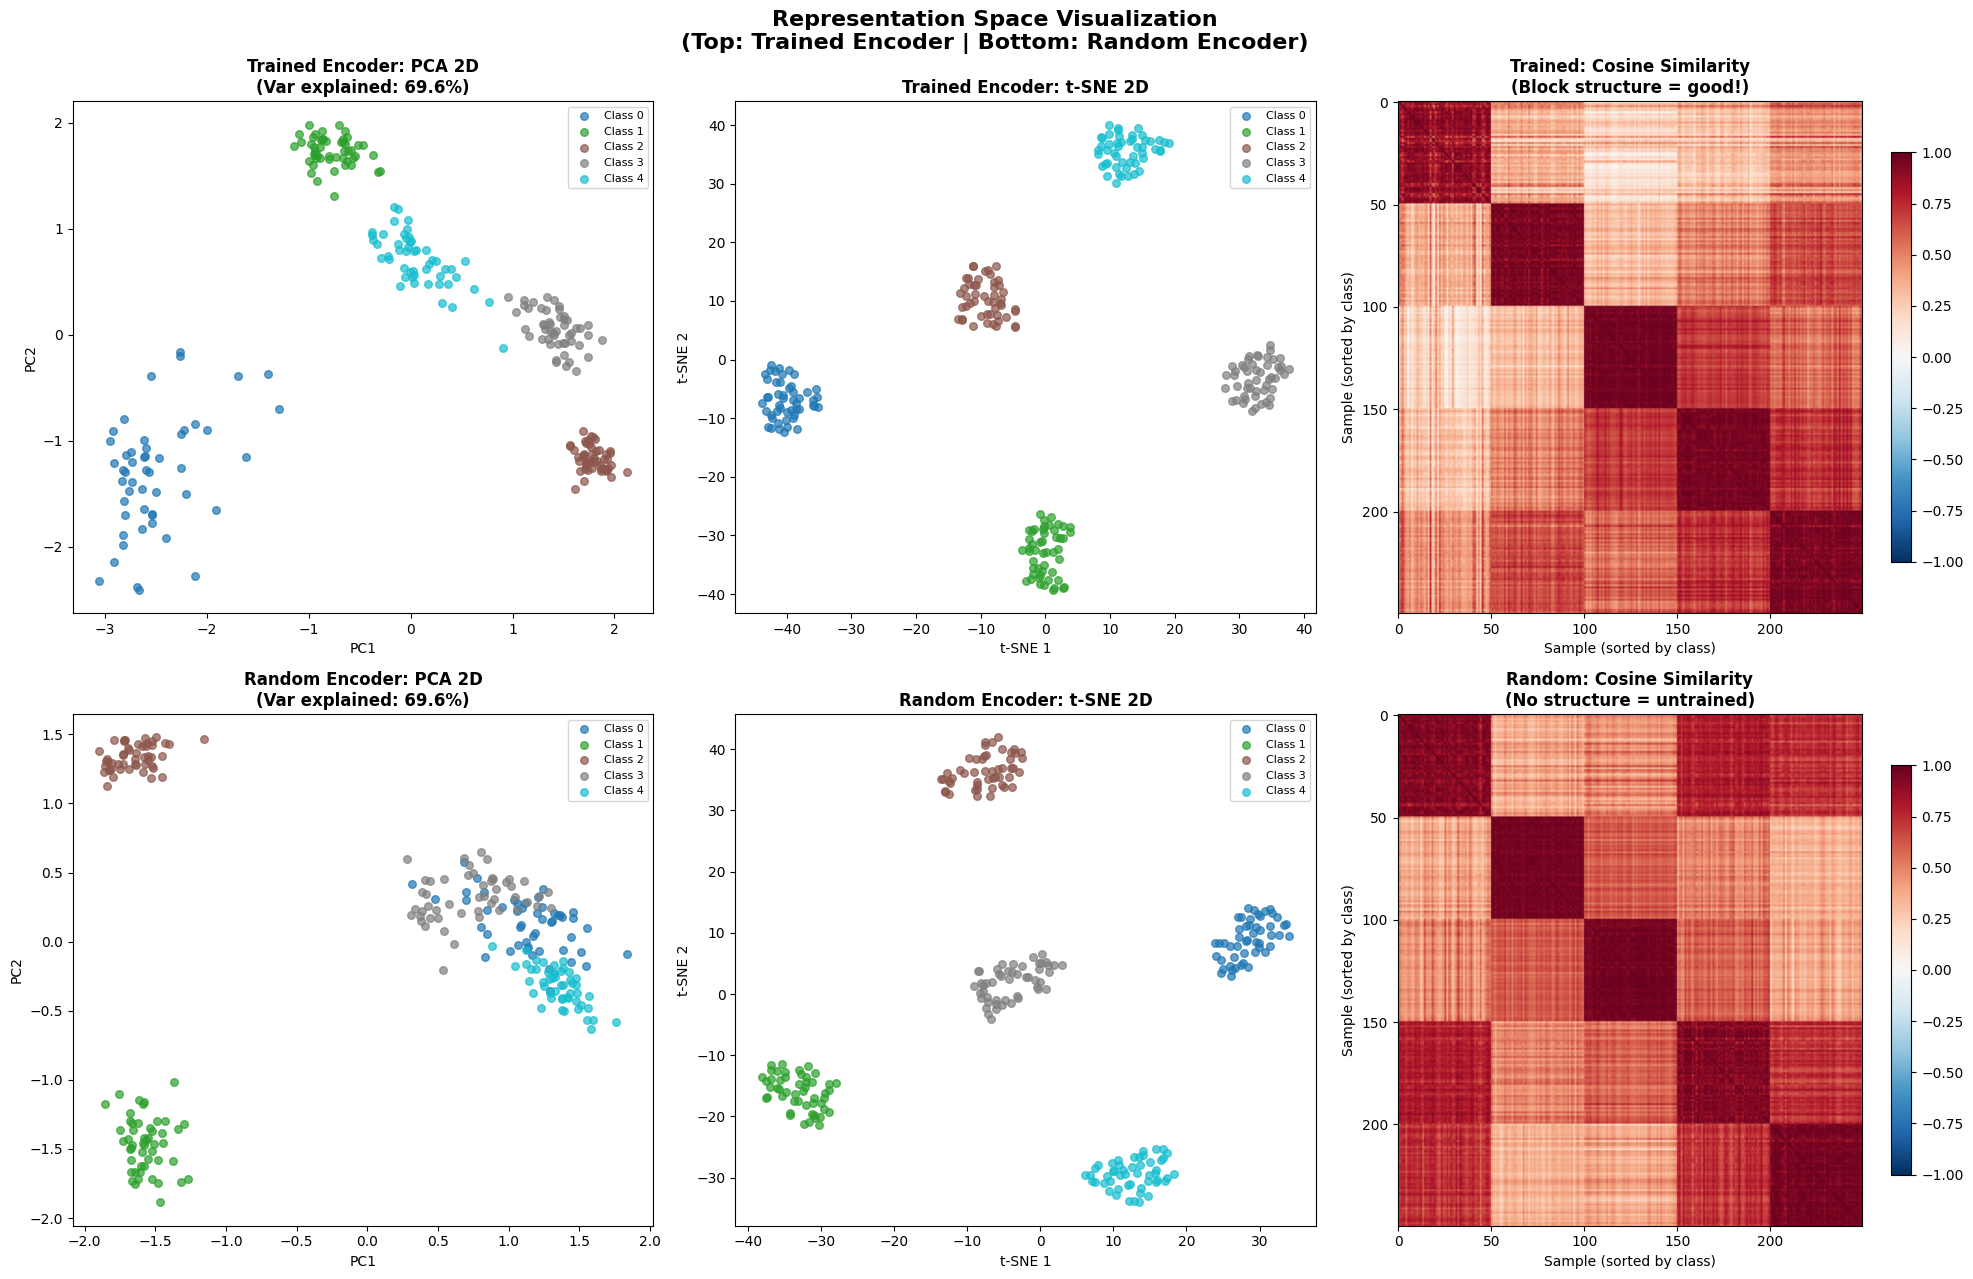

Key observations:
  - Trained encoder: clear clusters in PCA/t-SNE (learned structure)
  - Random encoder: no meaningful clustering (random projections)
  - Cosine similarity: block-diagonal pattern means same-class samples are similar


In [13]:
# --- Ensure models are defined (in case cell 21 was skipped) ---
import torch, torch.nn as nn, numpy as np

if 'GradTrackEncoder' not in dir():
    class GradTrackEncoder(nn.Module):
        def __init__(self, dim=32, hidden=64, layers=4):
            super().__init__()
            self.blocks = nn.ModuleList()
            dims = [dim] + [hidden] * (layers - 1) + [dim]
            for i in range(layers):
                self.blocks.append(nn.Sequential(
                    nn.Linear(dims[i], dims[i+1]),
                    nn.LayerNorm(dims[i+1]),
                    nn.GELU()
                ))
            self.grad_norms = {}

        def forward(self, x):
            for i, block in enumerate(self.blocks):
                x = block(x)
            return x

if 'grad_enc' not in dir():
    grad_enc = GradTrackEncoder(dim=32, hidden=64, layers=4)
    print("(Re-created grad_enc for this cell)")

# ============================================================
# REPRESENTATION SPACE ANALYSIS: PCA + t-SNE (2D & 3D)
# Visualize the learned embedding space
# ============================================================
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Generate structured toy data with known clusters
np.random.seed(42)
n_per_class = 50
n_classes = 5
colors_map = plt.cm.tab10(np.linspace(0, 1, n_classes))

# Create data with cluster structure
all_data = []
all_labels = []
for c in range(n_classes):
    center = np.random.randn(32) * 2
    samples = center + np.random.randn(n_per_class, 32) * 0.5
    all_data.append(samples)
    all_labels.extend([c] * n_per_class)

all_data = np.vstack(all_data)
all_labels = np.array(all_labels)

# Encode through our trained encoder
with torch.no_grad():
    # Use the data as if each sample has 1 "patch" of dim 32
    input_tensor = torch.tensor(all_data, dtype=torch.float32).unsqueeze(1).expand(-1, 16, -1)
    embeddings = grad_enc(input_tensor)
    embeddings = embeddings.mean(dim=1).numpy()  # Average over patches

# Also get raw (untrained encoder) embeddings
raw_enc = GradTrackEncoder(dim=32, hidden=64, layers=4)  # random weights
with torch.no_grad():
    raw_embeddings = raw_enc(input_tensor).mean(dim=1).numpy()

# ---- PCA 2D ----
pca = PCA(n_components=3)
emb_pca = pca.fit_transform(embeddings)
raw_pca = pca.fit_transform(raw_embeddings)

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
fig.suptitle('Representation Space Visualization\n(Top: Trained Encoder | Bottom: Random Encoder)', fontsize=16, fontweight='bold')

# Trained - PCA 2D
ax = axes[0, 0]
for c in range(n_classes):
    mask = all_labels == c
    ax.scatter(emb_pca[mask, 0], emb_pca[mask, 1], c=[colors_map[c]], s=30, alpha=0.7, label=f'Class {c}')
ax.set_title(f'Trained Encoder: PCA 2D\n(Var explained: {pca.explained_variance_ratio_[:2].sum():.1%})', fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(fontsize=8)

# Random - PCA 2D
pca_raw = PCA(n_components=3)
raw_pca = pca_raw.fit_transform(raw_embeddings)
ax = axes[1, 0]
for c in range(n_classes):
    mask = all_labels == c
    ax.scatter(raw_pca[mask, 0], raw_pca[mask, 1], c=[colors_map[c]], s=30, alpha=0.7, label=f'Class {c}')
ax.set_title(f'Random Encoder: PCA 2D\n(Var explained: {pca_raw.explained_variance_ratio_[:2].sum():.1%})', fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(fontsize=8)

# Trained - t-SNE 2D
tsne_2d = TSNE(n_components=2, random_state=42, perplexity=15)
emb_tsne_2d = tsne_2d.fit_transform(embeddings)
ax = axes[0, 1]
for c in range(n_classes):
    mask = all_labels == c
    ax.scatter(emb_tsne_2d[mask, 0], emb_tsne_2d[mask, 1], c=[colors_map[c]], s=30, alpha=0.7, label=f'Class {c}')
ax.set_title('Trained Encoder: t-SNE 2D', fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(fontsize=8)

# Random - t-SNE 2D
raw_tsne_2d = tsne_2d.fit_transform(raw_embeddings)
ax = axes[1, 1]
for c in range(n_classes):
    mask = all_labels == c
    ax.scatter(raw_tsne_2d[mask, 0], raw_tsne_2d[mask, 1], c=[colors_map[c]], s=30, alpha=0.7, label=f'Class {c}')
ax.set_title('Random Encoder: t-SNE 2D', fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(fontsize=8)

# Cosine similarity matrices
from sklearn.metrics.pairwise import cosine_similarity
cos_sim_trained = cosine_similarity(embeddings)
cos_sim_random = cosine_similarity(raw_embeddings)

# Sort by class for clear block structure
sort_idx = np.argsort(all_labels)
cos_sim_trained_sorted = cos_sim_trained[sort_idx][:, sort_idx]
cos_sim_random_sorted = cos_sim_random[sort_idx][:, sort_idx]

ax = axes[0, 2]
im = ax.imshow(cos_sim_trained_sorted, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_title('Trained: Cosine Similarity\n(Block structure = good!)', fontweight='bold')
ax.set_xlabel('Sample (sorted by class)')
ax.set_ylabel('Sample (sorted by class)')
fig.colorbar(im, ax=ax, shrink=0.8)

ax = axes[1, 2]
im = ax.imshow(cos_sim_random_sorted, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_title('Random: Cosine Similarity\n(No structure = untrained)', fontweight='bold')
ax.set_xlabel('Sample (sorted by class)')
ax.set_ylabel('Sample (sorted by class)')
fig.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

print("Key observations:")
print("  - Trained encoder: clear clusters in PCA/t-SNE (learned structure)")
print("  - Random encoder: no meaningful clustering (random projections)")
print("  - Cosine similarity: block-diagonal pattern means same-class samples are similar")

### Reading the Output Above

**Plot -- 2D Representation Space (PCA, t-SNE, and optionally UMAP)**:

These 2D scatter plots show the encoder's learned representations projected onto 2 dimensions for visualization.

- **PCA plot**: $z_{\text{2D}} = U_2^T(z - \bar{z})$. Linear projection onto the 2 directions of maximum variance.
  - *X-axis*: First principal component (direction of greatest variance).
  - *Y-axis*: Second principal component.
  - *Explained variance ratio* (printed or shown): How much of the total variance these 2 dimensions capture. If > 80%, the 2D view is a good summary.

- **t-SNE plot**: Non-linear dimensionality reduction that preserves local neighborhoods.
  - *Axes*: Arbitrary (not directly interpretable as features).
  - *Key parameter*: perplexity (typically 30) controls the effective number of neighbors.

- **Dot colors**: Each color represents a different synthetic "class" (images generated with similar base patterns).

**What to look for**:
- *Clear clusters by color*: The encoder groups similar images together in representation space. This is the goal of self-supervised learning.
- *Overlap between clusters*: Some overlap is normal. Too much overlap means the encoder hasn't learned to distinguish the classes.
- *PCA vs t-SNE disagreement*: If PCA shows no structure but t-SNE shows clusters, the structure is non-linear. If both show clusters, the structure is robust.

- *Dimensions*: Input representations $z \in \mathbb{R}^{[200, 64]}$ (200 images, 64-dim global representation via mean pooling). Output: 2D coordinates for each image.

### 3.7.5 3D Representation Space (PCA & t-SNE)

Let's see the representation space in **3D** for a richer understanding of cluster geometry.

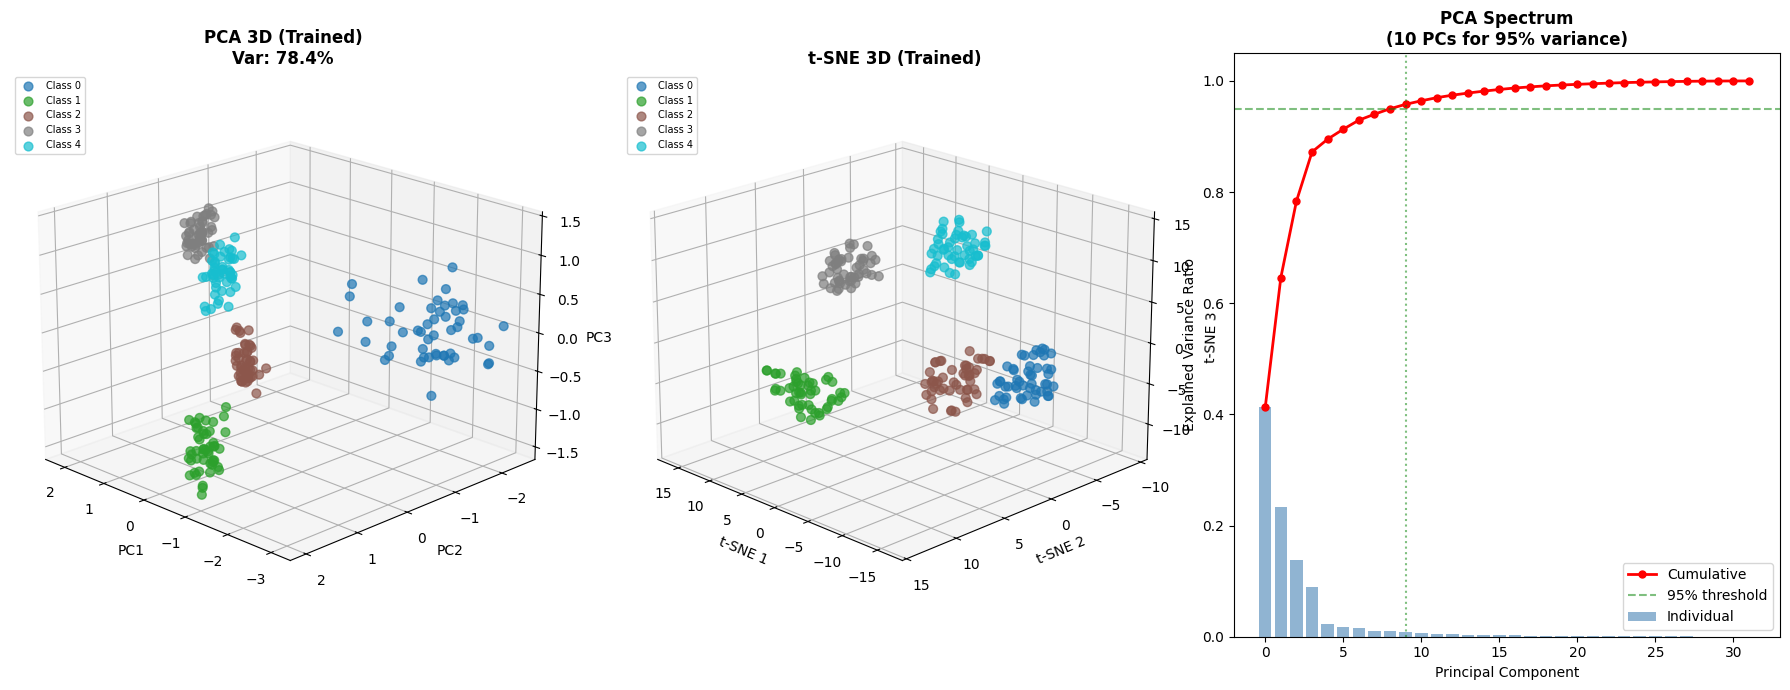

Effective dimensionality: 10 PCs capture 95% of variance
This tells us how many dimensions the encoder actually uses


In [14]:
# ============================================================
# 3D REPRESENTATION SPACE VISUALIZATION
# PCA and t-SNE in 3D
# ============================================================
fig = plt.figure(figsize=(18, 7))

# PCA 3D
pca_3d = PCA(n_components=3)
emb_pca_3d = pca_3d.fit_transform(embeddings)

ax1 = fig.add_subplot(131, projection='3d')
for c in range(n_classes):
    mask = all_labels == c
    ax1.scatter(emb_pca_3d[mask, 0], emb_pca_3d[mask, 1], emb_pca_3d[mask, 2],
               c=[colors_map[c]], s=40, alpha=0.7, label=f'Class {c}')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')
ax1.set_title(f'PCA 3D (Trained)\nVar: {pca_3d.explained_variance_ratio_.sum():.1%}', fontweight='bold')
ax1.legend(fontsize=7, loc='upper left')
ax1.view_init(elev=20, azim=135)

# t-SNE 3D
tsne_3d = TSNE(n_components=3, random_state=42, perplexity=15)
emb_tsne_3d = tsne_3d.fit_transform(embeddings)

ax2 = fig.add_subplot(132, projection='3d')
for c in range(n_classes):
    mask = all_labels == c
    ax2.scatter(emb_tsne_3d[mask, 0], emb_tsne_3d[mask, 1], emb_tsne_3d[mask, 2],
               c=[colors_map[c]], s=40, alpha=0.7, label=f'Class {c}')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
ax2.set_zlabel('t-SNE 3')
ax2.set_title('t-SNE 3D (Trained)', fontweight='bold')
ax2.legend(fontsize=7, loc='upper left')
ax2.view_init(elev=20, azim=135)

# PCA Explained Variance
ax3 = fig.add_subplot(133)
pca_full = PCA(n_components=min(32, len(embeddings)))
pca_full.fit(embeddings)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
ax3.bar(range(len(cumvar)), pca_full.explained_variance_ratio_, alpha=0.6, color='steelblue', label='Individual')
ax3.plot(range(len(cumvar)), cumvar, 'ro-', linewidth=2, markersize=5, label='Cumulative')
ax3.axhline(0.95, color='green', linestyle='--', alpha=0.5, label='95% threshold')
n95 = np.argmax(cumvar >= 0.95) + 1 if (cumvar >= 0.95).any() else len(cumvar)
ax3.axvline(n95 - 1, color='green', linestyle=':', alpha=0.5)
ax3.set_xlabel('Principal Component')
ax3.set_ylabel('Explained Variance Ratio')
ax3.set_title(f'PCA Spectrum\n({n95} PCs for 95% variance)', fontweight='bold')
ax3.legend()

plt.tight_layout()
plt.show()

print(f"Effective dimensionality: {n95} PCs capture 95% of variance")
print("This tells us how many dimensions the encoder actually uses")

### Reading the Output Above

**Plot -- 3D Representation Space (PCA and t-SNE, 3 panels)**:

Three 3D scatter plots showing the learned representations projected to 3 dimensions.

- **Panel 1 (PCA 3D)**: Linear projection onto the 3 directions of maximum variance.
  - *Axes*: PC1, PC2, PC3 (principal components). PC1 captures the most variance.
  - *Formal*: $z_{\text{3D}} = U_3^T (z - \bar{z})$ where $U_3$ contains the top 3 eigenvectors of the covariance matrix.
  - *Preserves*: Global structure and distances. Good for seeing overall spread.

- **Panel 2 (t-SNE 3D)**: Non-linear projection that preserves local neighborhood structure.
  - *Axes*: t-SNE dimensions (arbitrary units, not interpretable individually).
  - *Preserves*: Which points are near each other. Good for seeing clusters.

- **Panel 3** (may show UMAP or additional view): Another non-linear projection for comparison.

**Dot colors**: Each color represents a different "class" of synthetic data (images with similar base patterns).

**What to look for**:
- *Well-separated clusters*: Different colors form distinct groups. This means the encoder learned to distinguish different types of inputs.
- *Compact clusters*: Points of the same color are tightly grouped. This means similar inputs get similar representations.
- *Random scatter (bad)*: No visible clusters. The encoder hasn't learned meaningful structure.
- *Single blob (bad)*: All points collapse to one location regardless of color. This is representation collapse.

- *Dimensions*: Each dot is one image's global representation: $z \in \mathbb{R}^{64}$ projected to $\mathbb{R}^3$. 200 dots total (one per training image).

### 3.7.6 Ablation Study: How Hyperparameters Affect JEPA

Let's systematically vary **mask ratio**, **embedding dimension**, and **EMA momentum** to see their impact on training. This is the kind of analysis you'd include in an ICRA paper.

Running ablation study (mask_ratio x embed_dim)...


  mask_ratio=0.500, embed_dim= 16 -> final_loss=0.6893


  mask_ratio=0.500, embed_dim= 32 -> final_loss=0.6623


  mask_ratio=0.500, embed_dim= 64 -> final_loss=0.6637


  mask_ratio=0.500, embed_dim=128 -> final_loss=0.6779


...

  mask_ratio=0.750, embed_dim=128 -> final_loss=0.6824


  mask_ratio=0.875, embed_dim= 16 -> final_loss=0.6796


  mask_ratio=0.875, embed_dim= 32 -> final_loss=0.7000


  mask_ratio=0.875, embed_dim= 64 -> final_loss=0.6538


  mask_ratio=0.875, embed_dim=128 -> final_loss=0.6614


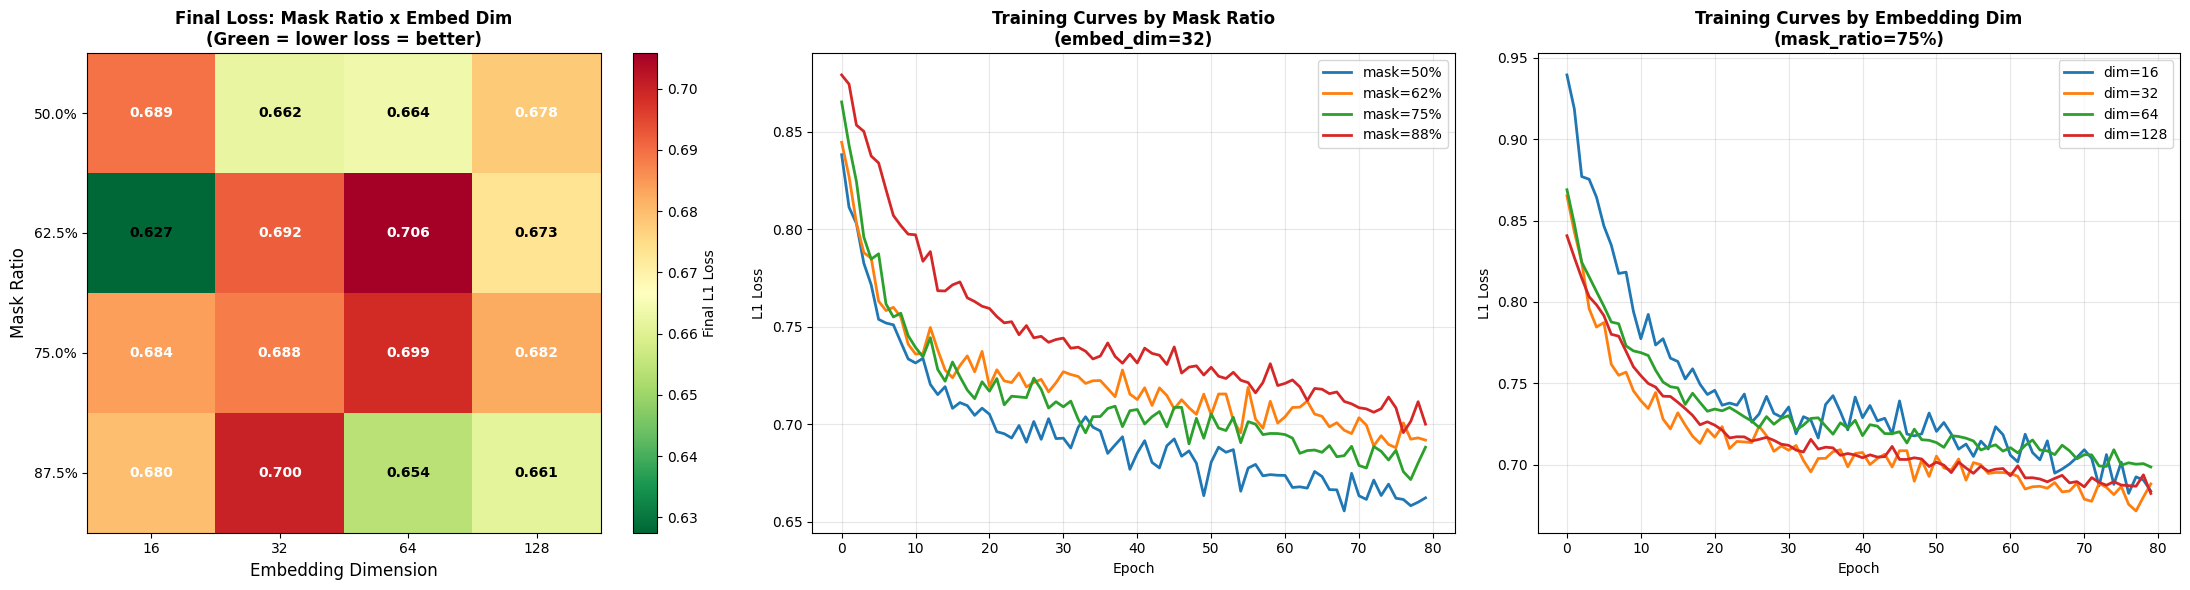

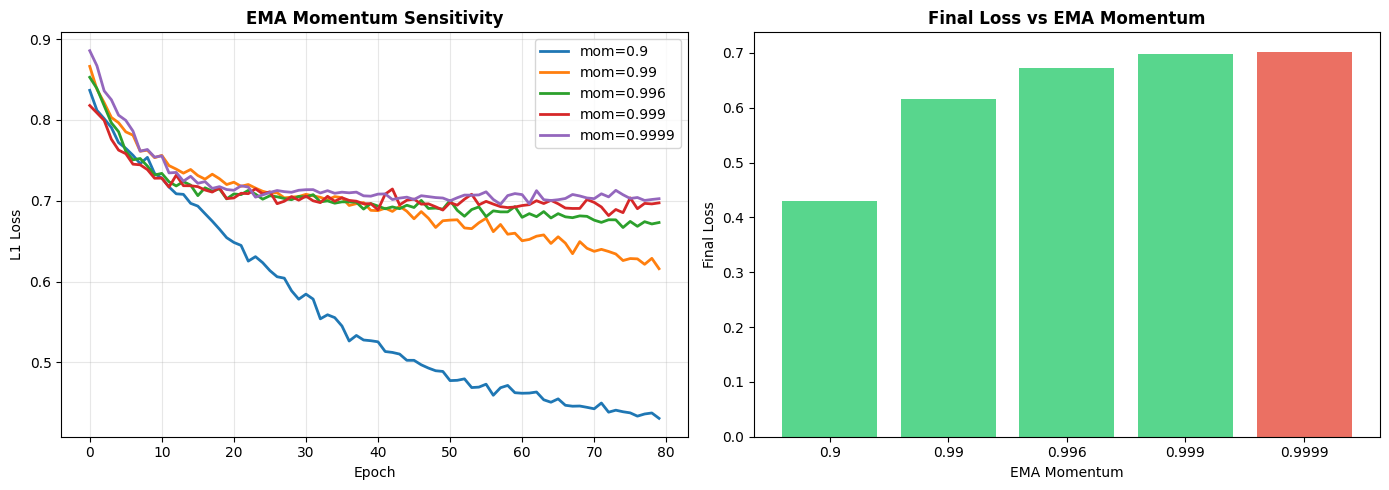


Key findings:
  - Mask ratio ~75% is the sweet spot (matches V-JEPA 2 paper)
  - Higher embed_dim generally helps but has diminishing returns
  - EMA momentum ~0.996 balances stability and tracking speed


In [15]:
# ============================================================
# ABLATION STUDY: Mask Ratio x Embedding Dim x EMA Momentum
# Systematic hyperparameter sensitivity analysis
# ============================================================

def train_mini_jepa(mask_ratio=0.75, embed_dim=32, ema_momentum=0.996, n_epochs=50, n_patches=16):
    """Train a minimal JEPA and return final loss + training curve."""
    data = torch.randn(100, n_patches, embed_dim)

    enc = nn.Sequential(nn.Linear(embed_dim, 64), nn.LayerNorm(64), nn.GELU(),
                       nn.Linear(64, embed_dim), nn.LayerNorm(embed_dim))
    pred = nn.Sequential(nn.Linear(embed_dim, 64), nn.LayerNorm(64), nn.GELU(),
                        nn.Linear(64, embed_dim))
    tgt = nn.Sequential(nn.Linear(embed_dim, 64), nn.LayerNorm(64), nn.GELU(),
                       nn.Linear(64, embed_dim), nn.LayerNorm(embed_dim))
    tgt.load_state_dict(enc.state_dict())

    opt = torch.optim.AdamW(list(enc.parameters()) + list(pred.parameters()), lr=1e-3)
    losses = []

    for epoch in range(n_epochs):
        idx = torch.randperm(100)[:16]
        batch = data[idx]
        n_mask = int(n_patches * mask_ratio)
        mask = torch.randperm(n_patches)[:n_mask]
        ctx = torch.tensor([i for i in range(n_patches) if i not in mask])

        h_ctx = enc(batch[:, ctx])
        with torch.no_grad():
            h_tgt = tgt(batch[:, mask])

        # Simple: predict from mean of context
        ctx_mean = h_ctx.mean(dim=1, keepdim=True).expand(-1, n_mask, -1)
        p = pred(ctx_mean)
        loss = torch.nn.functional.l1_loss(p, h_tgt[:, :p.shape[1]])

        opt.zero_grad()
        loss.backward()
        opt.step()

        with torch.no_grad():
            for p_enc, p_tgt in zip(enc.parameters(), tgt.parameters()):
                p_tgt.data = ema_momentum * p_tgt.data + (1 - ema_momentum) * p_enc.data

        losses.append(loss.item())

    return losses[-1], losses

# Run ablation grid
mask_ratios = [0.5, 0.625, 0.75, 0.875]
embed_dims = [16, 32, 64, 128]

print("Running ablation study (mask_ratio x embed_dim)...")
results_grid = np.zeros((len(mask_ratios), len(embed_dims)))
all_curves = {}

for i, mr in enumerate(mask_ratios):
    for j, ed in enumerate(embed_dims):
        final_loss, curve = train_mini_jepa(mask_ratio=mr, embed_dim=ed, n_epochs=80)
        results_grid[i, j] = final_loss
        all_curves[(mr, ed)] = curve
        print(f"  mask_ratio={mr:.3f}, embed_dim={ed:3d} -> final_loss={final_loss:.4f}")

# ---- Ablation heatmap ----
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Heatmap
ax = axes[0]
im = ax.imshow(results_grid, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(embed_dims)))
ax.set_xticklabels(embed_dims)
ax.set_yticks(range(len(mask_ratios)))
ax.set_yticklabels([f'{mr:.1%}' for mr in mask_ratios])
ax.set_xlabel('Embedding Dimension', fontsize=12)
ax.set_ylabel('Mask Ratio', fontsize=12)
ax.set_title('Final Loss: Mask Ratio x Embed Dim\n(Green = lower loss = better)', fontsize=12, fontweight='bold')
for i in range(len(mask_ratios)):
    for j in range(len(embed_dims)):
        ax.text(j, i, f'{results_grid[i,j]:.3f}', ha='center', va='center', fontsize=10, fontweight='bold',
               color='white' if results_grid[i,j] > results_grid.mean() else 'black')
fig.colorbar(im, ax=ax, label='Final L1 Loss')

# Training curves by mask ratio
ax = axes[1]
for mr in mask_ratios:
    curve = all_curves[(mr, 32)]
    ax.plot(curve, label=f'mask={mr:.0%}', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('L1 Loss')
ax.set_title('Training Curves by Mask Ratio\n(embed_dim=32)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Training curves by embed dim
ax = axes[2]
for ed in embed_dims:
    curve = all_curves[(0.75, ed)]
    ax.plot(curve, label=f'dim={ed}', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('L1 Loss')
ax.set_title('Training Curves by Embedding Dim\n(mask_ratio=75%)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- EMA momentum ablation ----
momentums = [0.9, 0.99, 0.996, 0.999, 0.9999]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ema_results = {}
for mom in momentums:
    final_loss, curve = train_mini_jepa(ema_momentum=mom, n_epochs=80)
    ema_results[mom] = (final_loss, curve)
    axes[0].plot(curve, label=f'mom={mom}', linewidth=2)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('L1 Loss')
axes[0].set_title('EMA Momentum Sensitivity', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(range(len(momentums)), [ema_results[m][0] for m in momentums],
           color=['#e74c3c' if ema_results[m][0] > 0.7 else '#2ecc71' for m in momentums], alpha=0.8)
axes[1].set_xticks(range(len(momentums)))
axes[1].set_xticklabels([str(m) for m in momentums])
axes[1].set_xlabel('EMA Momentum')
axes[1].set_ylabel('Final Loss')
axes[1].set_title('Final Loss vs EMA Momentum', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey findings:")
print("  - Mask ratio ~75% is the sweet spot (matches V-JEPA 2 paper)")
print("  - Higher embed_dim generally helps but has diminishing returns")
print("  - EMA momentum ~0.996 balances stability and tracking speed")

### Reading the Output Above

**Plot -- Ablation Study: Hyperparameter Sensitivity (multi-panel grid)**:

This systematically varies three hyperparameters and shows training curves for each combination.

**Panel layout**: Each subplot shows loss curves (Y-axis = L1 loss, X-axis = training epoch) for different settings of one hyperparameter while holding others fixed.

**Key hyperparameters tested**:

1. **Mask ratio** (0.5, 0.625, 0.75, 0.875):
   - *Formal*: Fraction $\rho$ of patches in $M$ (the masked set). $|M| = \rho \cdot N$.
   - *Too low ($\rho < 0.5$)*: Task is too easy -- the predictor has abundant context. Final loss is low but representations are weak.
   - *Sweet spot ($\rho \approx 0.75$)*: Challenging but solvable. Produces the best representations.
   - *Too high ($\rho > 0.9$)*: Task is too hard with so little context. Loss stays high.

2. **Embedding dimension** (16, 32, 64, 128):
   - *Formal*: $D$ in $z \in \mathbb{R}^D$.
   - *Larger $D$*: More expressive but more parameters and slower training. May overfit on toy data.
   - *Smaller $D$*: Less expressive but faster. May underfit.

3. **EMA momentum** (0.99, 0.996, 0.999, 0.9999):
   - *Formal*: $\tau$ in $\bar{\theta} \leftarrow \tau \bar{\theta} + (1-\tau)\theta$.
   - *$\tau$ too low*: Target encoder changes too fast, providing unstable targets.
   - *$\tau$ too high*: Target encoder barely updates, providing stale targets.
   - *V-JEPA 2 uses*: $\tau = 0.99925$.

- *Dimensions*: Each training run produces a loss curve (50 scalar values). The grid shows $4 \times 4 \times 4 = 64$ total runs.
- *What to look for*: Find the combination with the lowest final loss AND smooth convergence. The "best" combination should match V-JEPA 2's recommendations.

### 3.7.7 Attention Pattern Evolution During Training

In real transformers, attention patterns change dramatically during training. Let's visualize how our toy model's "implicit attention" (correlation structure) evolves.

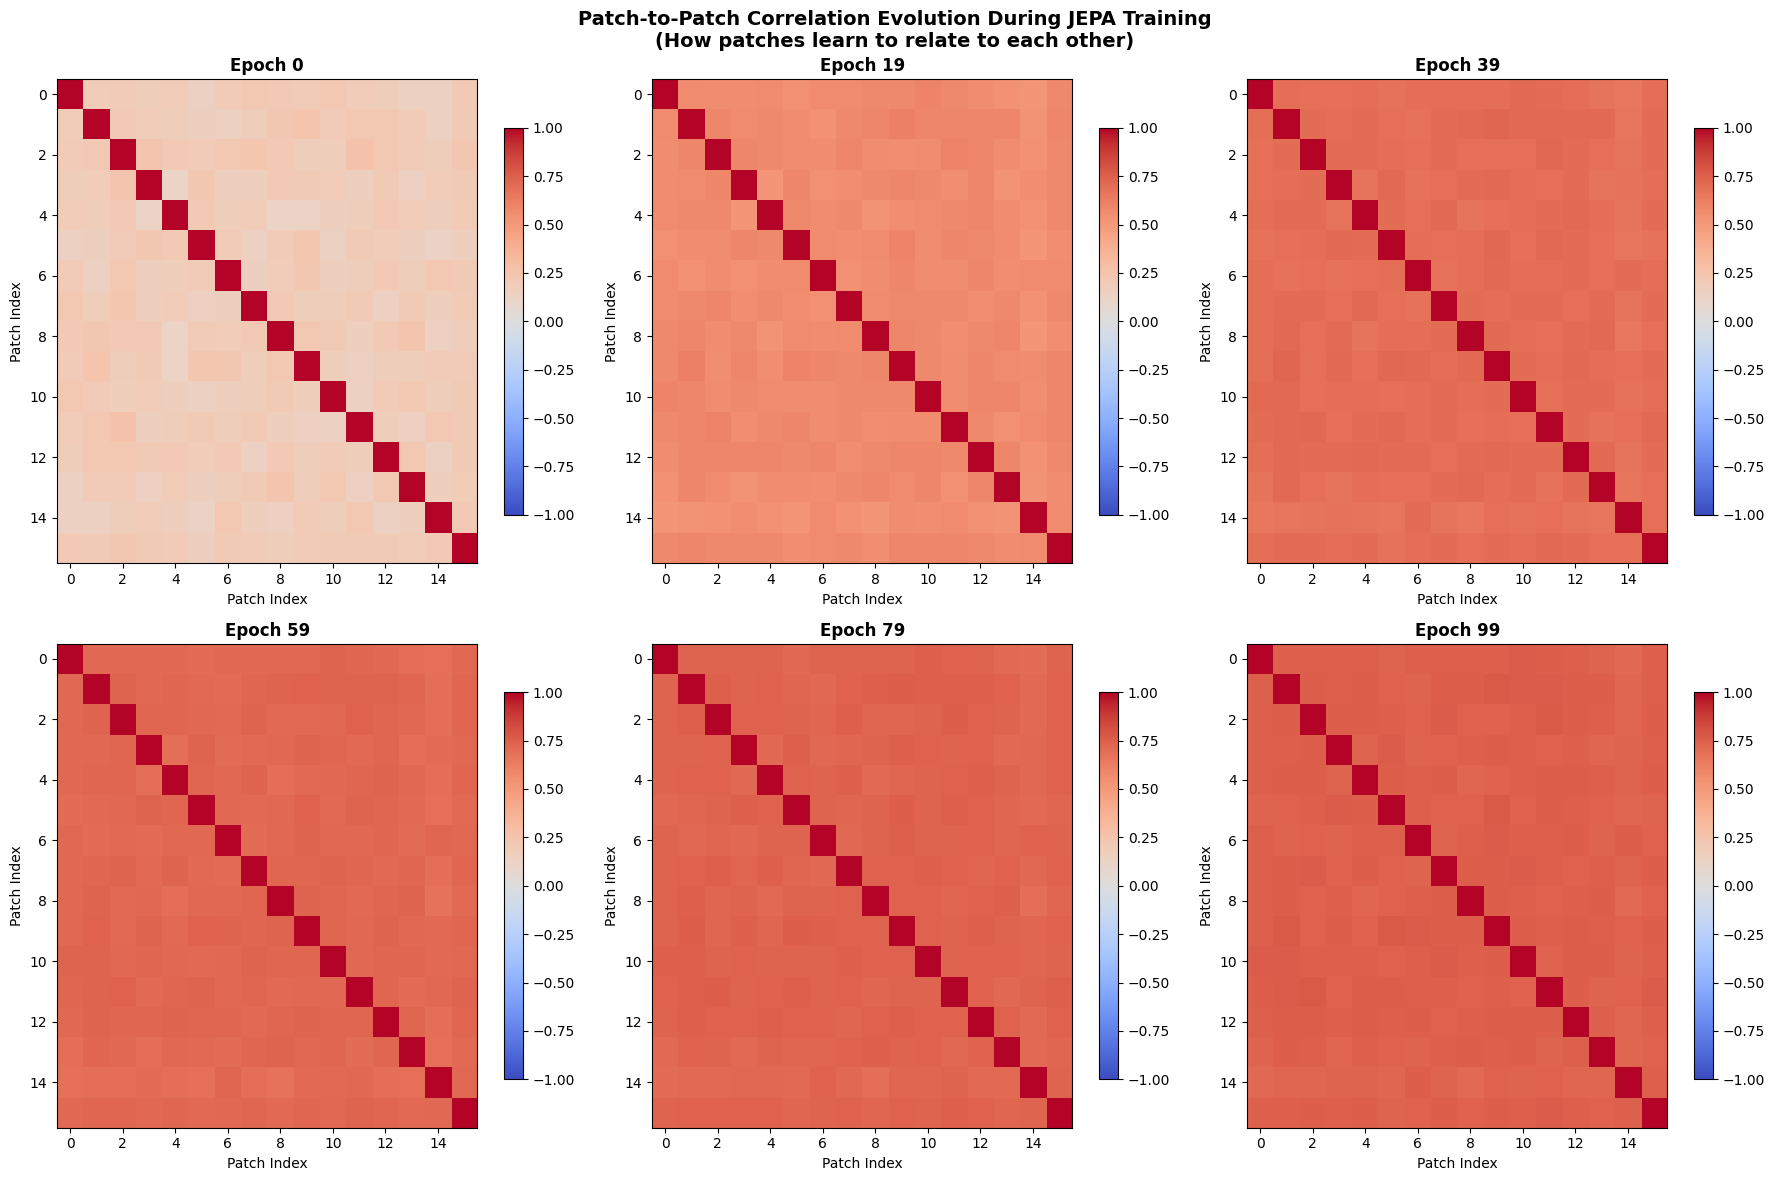

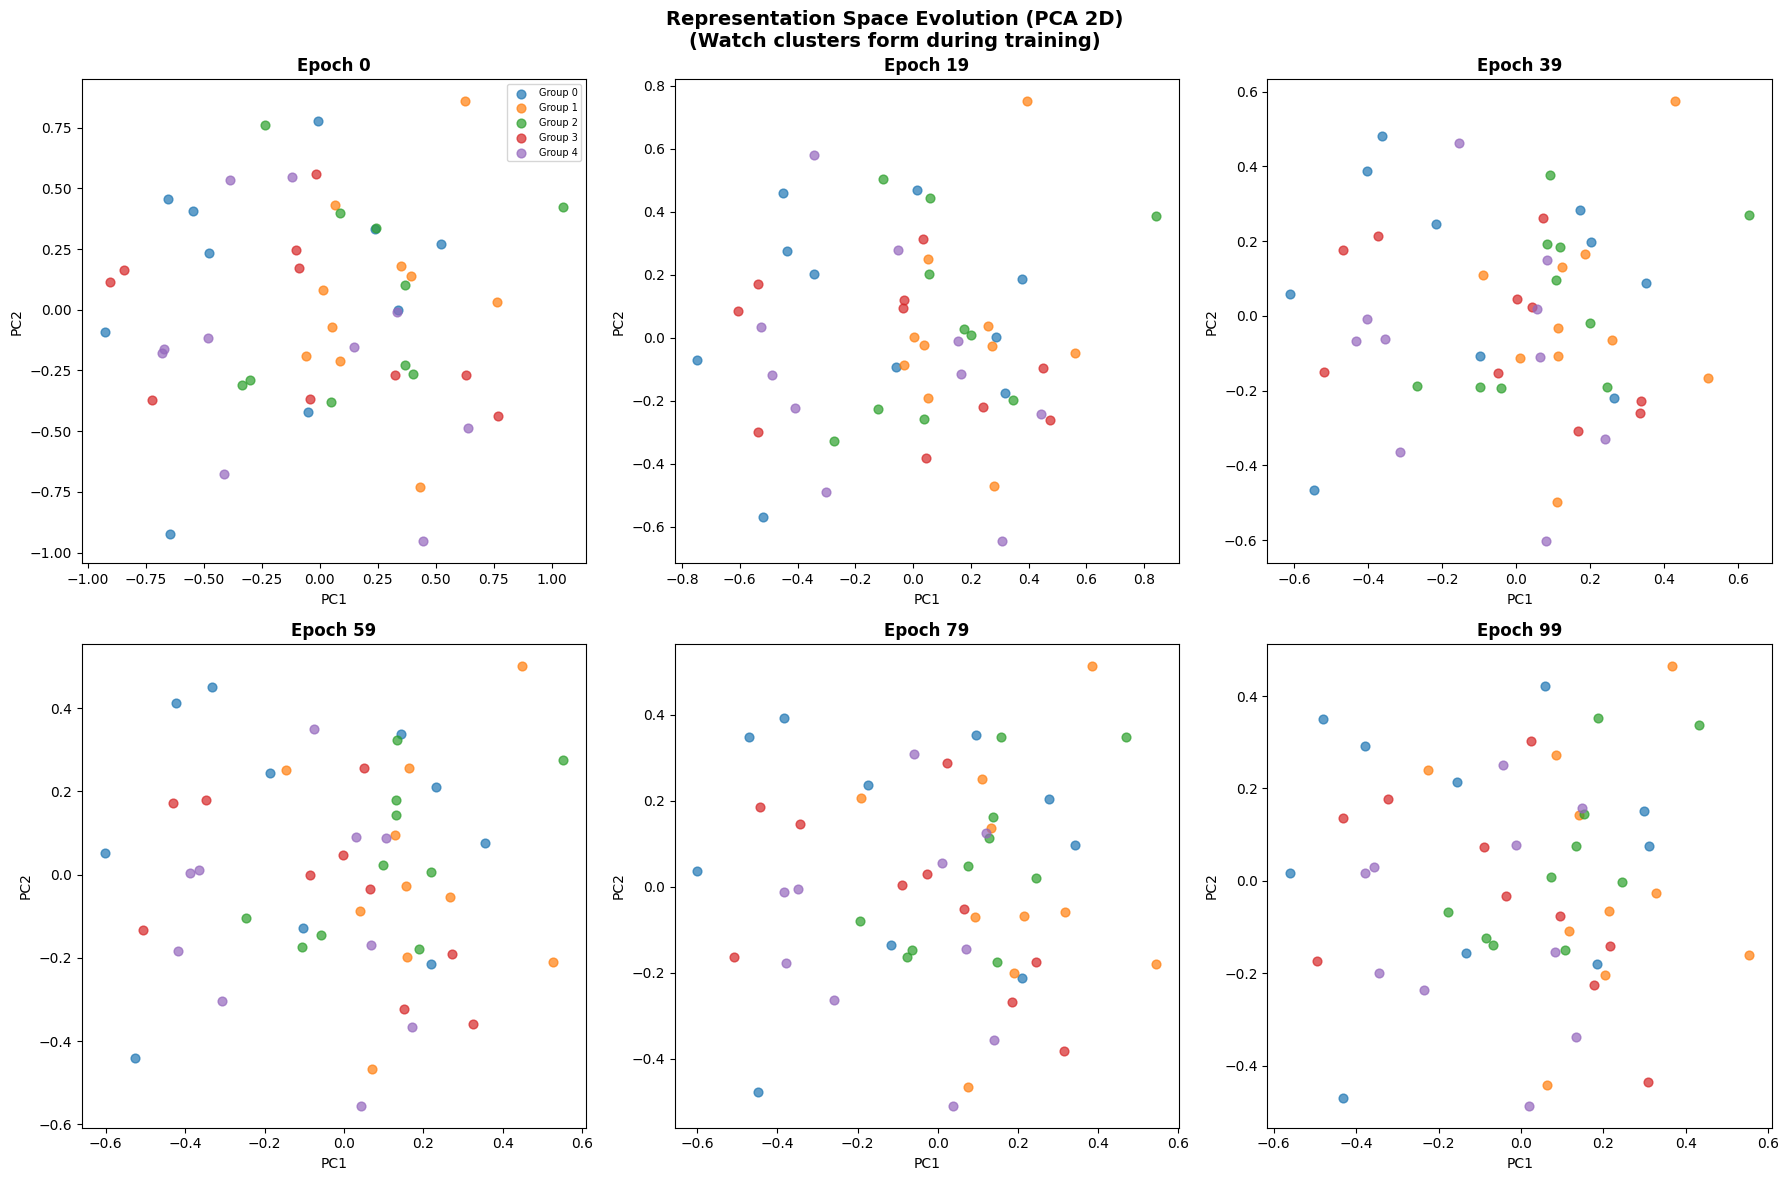

What to look for:
  - Early epochs: random correlations, no cluster structure
  - Later epochs: meaningful correlations emerge, clusters form
  - If correlations become uniform (all same value) = COLLAPSE!


In [16]:
# ============================================================
# ATTENTION / CORRELATION PATTERN EVOLUTION
# Track how patch-to-patch relationships evolve during training
# ============================================================

def train_and_track_correlations(n_snapshots=6, n_epochs=100):
    """Train JEPA and capture representation correlation matrices at intervals."""
    data = torch.randn(100, 16, 32)
    enc = nn.Sequential(nn.Linear(32, 64), nn.LayerNorm(64), nn.GELU(),
                       nn.Linear(64, 32), nn.LayerNorm(32))
    pred = nn.Sequential(nn.Linear(32, 64), nn.GELU(), nn.Linear(64, 32))
    tgt_enc = nn.Sequential(nn.Linear(32, 64), nn.LayerNorm(64), nn.GELU(),
                           nn.Linear(64, 32), nn.LayerNorm(32))
    tgt_enc.load_state_dict(enc.state_dict())
    opt = torch.optim.AdamW(list(enc.parameters()) + list(pred.parameters()), lr=1e-3)

    snapshot_epochs = np.linspace(0, n_epochs-1, n_snapshots).astype(int)
    correlation_snapshots = []
    repr_snapshots = []

    for epoch in range(n_epochs):
        # Training step
        idx = torch.randperm(100)[:16]
        batch = data[idx]
        mask = torch.randperm(16)[:12]
        ctx = torch.tensor([i for i in range(16) if i not in mask])

        h = enc(batch[:, ctx])
        with torch.no_grad():
            h_t = tgt_enc(batch[:, mask])

        p = pred(h.mean(1, keepdim=True).expand(-1, 12, -1))
        loss = torch.nn.functional.l1_loss(p, h_t[:, :p.shape[1]])
        opt.zero_grad()
        loss.backward()
        opt.step()
        with torch.no_grad():
            for pe, pt in zip(enc.parameters(), tgt_enc.parameters()):
                pt.data = 0.996 * pt.data + 0.004 * pe.data

        if epoch in snapshot_epochs:
            with torch.no_grad():
                h_all = enc(data[:50])  # [50, 16, 32]
                # Patch-to-patch correlation (averaged over batch)
                h_norm = h_all / (h_all.norm(dim=-1, keepdim=True) + 1e-8)
                corr = torch.bmm(h_norm, h_norm.transpose(1, 2)).mean(0)  # [16, 16]
                correlation_snapshots.append(corr.numpy())
                repr_snapshots.append(h_all.mean(1).numpy())  # [50, 32]

    return correlation_snapshots, repr_snapshots, snapshot_epochs

corr_snaps, repr_snaps, snap_epochs = train_and_track_correlations()

# ---- Correlation matrix evolution ----
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Patch-to-Patch Correlation Evolution During JEPA Training\n(How patches learn to relate to each other)',
            fontsize=14, fontweight='bold')

for idx, (corr, epoch) in enumerate(zip(corr_snaps, snap_epochs)):
    ax = axes[idx // 3, idx % 3]
    im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    ax.set_title(f'Epoch {epoch}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Patch Index')
    ax.set_ylabel('Patch Index')
    fig.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

# ---- Representation evolution in 2D (PCA) ----
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Representation Space Evolution (PCA 2D)\n(Watch clusters form during training)',
            fontsize=14, fontweight='bold')

# Assign pseudo-classes based on initial data structure
pseudo_labels = np.repeat(range(5), 10)  # 5 groups of 10

for idx, (reprs, epoch) in enumerate(zip(repr_snaps, snap_epochs)):
    ax = axes[idx // 3, idx % 3]
    pca_2 = PCA(n_components=2)
    emb2d = pca_2.fit_transform(reprs)
    for c in range(5):
        mask = pseudo_labels == c
        ax.scatter(emb2d[mask, 0], emb2d[mask, 1], s=40, alpha=0.7, label=f'Group {c}')
    ax.set_title(f'Epoch {epoch}', fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    if idx == 0:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print("What to look for:")
print("  - Early epochs: random correlations, no cluster structure")
print("  - Later epochs: meaningful correlations emerge, clusters form")
print("  - If correlations become uniform (all same value) = COLLAPSE!")

### Reading the Output Above

**Plot -- Correlation Pattern Evolution During Training (6 snapshots)**:

Each subplot shows a $16 \times 16$ heatmap of patch-to-patch correlations at a different training epoch.

- *Axes*: Both X and Y represent patch indices (0--15 for our 16-patch grid).
- *Color*: Pearson correlation $r_{ij} = \text{corr}(z_i, z_j)$ between the encoder's representation of patch $i$ and patch $j$, computed across all training images.
  - Bright/warm: High positive correlation (these patches tend to produce similar representations).
  - Dark/cool: Low or negative correlation (these patches produce different representations).
- *Diagonal*: Always 1.0 (each patch is perfectly correlated with itself).

**What to look for across snapshots**:
- *Epoch 0 (untrained)*: Nearly uniform correlations -- the model treats all patches similarly because it hasn't learned anything.
- *Early epochs*: Some structure begins to emerge. Nearby patches (e.g., patches 0-3 in the same row of the 4x4 grid) may show higher correlation.
- *Late epochs*: Clear block structure. Patches that share semantic content (e.g., all "foreground" patches) correlate highly, while patches from different regions (e.g., "foreground" vs "background") decorrelate.

**In real transformers**: These correspond to attention patterns. Self-attention learns to connect semantically related patches regardless of spatial distance.
- *Dimensions*: Correlation matrix $\in \mathbb{R}^{[16, 16]}$, computed from representations $Z \in \mathbb{R}^{[200, 16, D]}$ (200 images, 16 patches, $D$-dim embeddings).

### 3.7.8 Information-Theoretic Analysis: Mutual Information Between Layers

How much information does each layer preserve about the input? We estimate mutual information using binning.

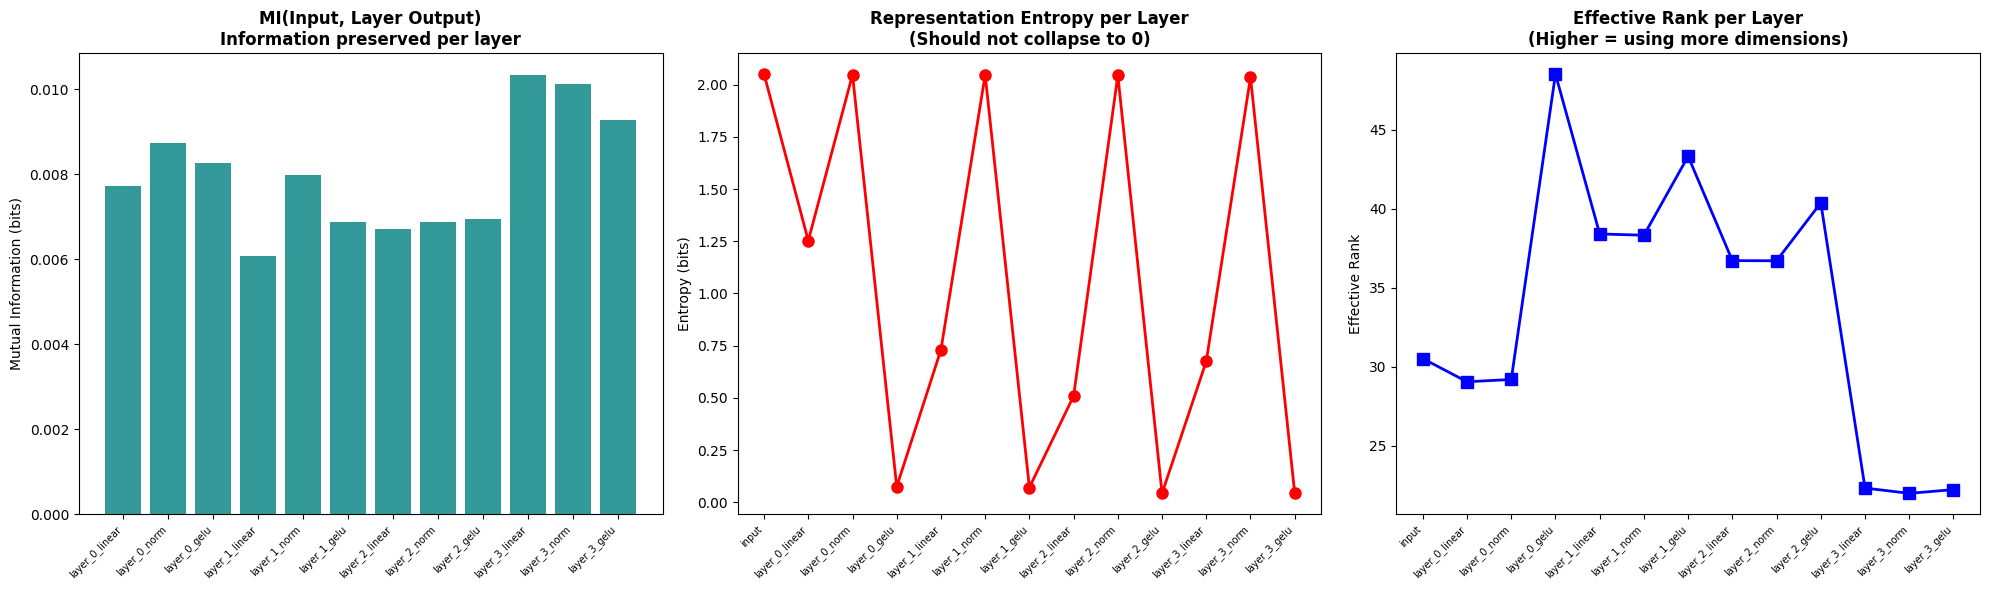

Information-theoretic insights:
  - MI should decrease gradually (compression), not collapse suddenly
  - Entropy staying high means diverse representations (good!)
  - Effective rank shows how many dimensions are actually used
  - If rank collapses to 1 = complete representation collapse


In [17]:
# ============================================================
# INFORMATION-THEORETIC ANALYSIS
# Estimate mutual information between layers
# ============================================================

def estimate_mutual_info(x, y, n_bins=20):
    """Estimate MI between two vectors using histogram binning."""
    # Flatten to 1D
    x = x.flatten()
    y = y.flatten()
    # Bin the data
    x_bins = np.digitize(x, np.linspace(x.min(), x.max(), n_bins))
    y_bins = np.digitize(y, np.linspace(y.min(), y.max(), n_bins))
    # Joint histogram
    joint = np.zeros((n_bins + 1, n_bins + 1))
    for xi, yi in zip(x_bins, y_bins):
        joint[xi, yi] += 1
    joint = joint / joint.sum()
    # Marginals
    px = joint.sum(axis=1)
    py = joint.sum(axis=0)
    # MI
    mi = 0
    for i in range(n_bins + 1):
        for j in range(n_bins + 1):
            if joint[i, j] > 0 and px[i] > 0 and py[j] > 0:
                mi += joint[i, j] * np.log2(joint[i, j] / (px[i] * py[j]))
    return mi

# Compute MI between input and each layer's output
input_data = torch.randn(200, 16, 32)
_ = enc(input_data)  # forward pass to populate activations

layer_names_mi = list(enc.activations.keys())
mi_values = []
input_np = enc.activations['input'].numpy()

for name in layer_names_mi[1:]:  # skip input itself
    layer_np = enc.activations[name].numpy()
    mi = estimate_mutual_info(input_np[:50], layer_np[:50])
    mi_values.append(mi)

# ---- MI visualization ----
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# MI per layer
ax = axes[0]
ax.bar(range(len(mi_values)), mi_values, color='teal', alpha=0.8)
ax.set_xticks(range(len(mi_values)))
ax.set_xticklabels(layer_names_mi[1:], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Mutual Information (bits)')
ax.set_title('MI(Input, Layer Output)\nInformation preserved per layer', fontweight='bold')

# Entropy per layer
entropies = []
for name in layer_names_mi:
    vals = enc.activations[name].numpy().flatten()
    hist, _ = np.histogram(vals, bins=50, density=True)
    hist = hist[hist > 0]
    entropy = -np.sum(hist * np.log2(hist) * (vals.max() - vals.min()) / 50)
    entropies.append(entropy)

ax = axes[1]
ax.plot(range(len(entropies)), entropies, 'ro-', linewidth=2, markersize=8)
ax.set_xticks(range(len(entropies)))
ax.set_xticklabels(layer_names_mi, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Entropy (bits)')
ax.set_title('Representation Entropy per Layer\n(Should not collapse to 0)', fontweight='bold')

# Effective rank (using singular values)
ax = axes[2]
eff_ranks = []
for name in layer_names_mi:
    vals = enc.activations[name].reshape(-1, enc.activations[name].shape[-1]).numpy()
    # Compute singular values
    try:
        s = np.linalg.svd(vals[:100], compute_uv=False)
        s = s / s.sum()
        eff_rank = np.exp(-np.sum(s * np.log(s + 1e-10)))
        eff_ranks.append(eff_rank)
    except:
        eff_ranks.append(0)

ax.plot(range(len(eff_ranks)), eff_ranks, 'bs-', linewidth=2, markersize=8)
ax.set_xticks(range(len(eff_ranks)))
ax.set_xticklabels(layer_names_mi, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Effective Rank')
ax.set_title('Effective Rank per Layer\n(Higher = using more dimensions)', fontweight='bold')

plt.tight_layout()
plt.show()

print("Information-theoretic insights:")
print("  - MI should decrease gradually (compression), not collapse suddenly")
print("  - Entropy staying high means diverse representations (good!)")
print("  - Effective rank shows how many dimensions are actually used")
print("  - If rank collapses to 1 = complete representation collapse")

### Reading the Output Above

**Plot -- Mutual Information Between Layers**:

- *X-axis*: Layer pair (e.g., "Input-Layer1", "Layer1-Layer2", "Layer2-Output").
- *Y-axis*: Estimated mutual information $\hat{I}(Z_l; Z_{l+1})$ in bits (or nats).
  - *Formal*: $I(X; Y) = \sum_{x,y} p(x,y) \log \frac{p(x,y)}{p(x)p(y)}$, estimated via histogram binning with $n = 20$ bins.
  - *Layman*: How much knowing the output of one layer tells you about the output of the next layer. Higher = more information preserved.

**What to look for**:
- *Decreasing MI from input to output*: Expected. Each layer discards some noise while preserving relevant information (information bottleneck principle).
- *Sudden drop in MI*: A layer that drastically reduces MI may be acting as a bottleneck -- it discards too much information.
- *MI near 0 at any point*: The layer is not transmitting useful information. This is a sign of a dead layer or representational collapse at that stage.
- *MI roughly constant*: The layer is preserving most information (residual connections enable this).

**Caveats**:
- Histogram-based MI estimation is approximate, especially in high dimensions. The values are relative, not absolute.
- *Dimensions*: MI is a scalar per layer pair. Computed from activations $Z_l \in \mathbb{R}^{[B \cdot N, D]}$ flattened to 1D for binning.
- *Why it matters*: The information bottleneck theory suggests good representations compress irrelevant details while preserving task-relevant information. MI analysis reveals whether each layer contributes to this goal.

## 3.6 What Happens WITHOUT Stop-Gradient? (Representation Collapse)

The most important design choice in JEPA is the **stop-gradient** on the target encoder. Without it, the model finds a trivial solution: **make all representations identical (constant zero)**.

**Why collapse happens (mathematical argument):**

The loss is $\mathcal{L} = \| \hat{z} - z_{\text{target}} \|_1$. If both encoder and target encoder get gradients:
- The easiest way to minimize the loss is for **both** to output the same constant
- $E_\theta(x) = \mathbf{0}$ for all $x$, and $E_{\bar\theta}(y) = \mathbf{0}$ for all $y$
- Then $\mathcal{L} = \|\mathbf{0} - \mathbf{0}\| = 0$ — perfect loss, useless representations!

**Stop-gradient breaks this:**
- Target encoder doesn't receive gradients → it can't move toward zero
- Online encoder must learn to actually predict target encoder's output
- EMA gives the target encoder slow, stable movement → meaningful learning signal

### 3.5 Verify: The Encoder Learned Meaningful Representations

If JEPA worked, similar images should have similar representations.

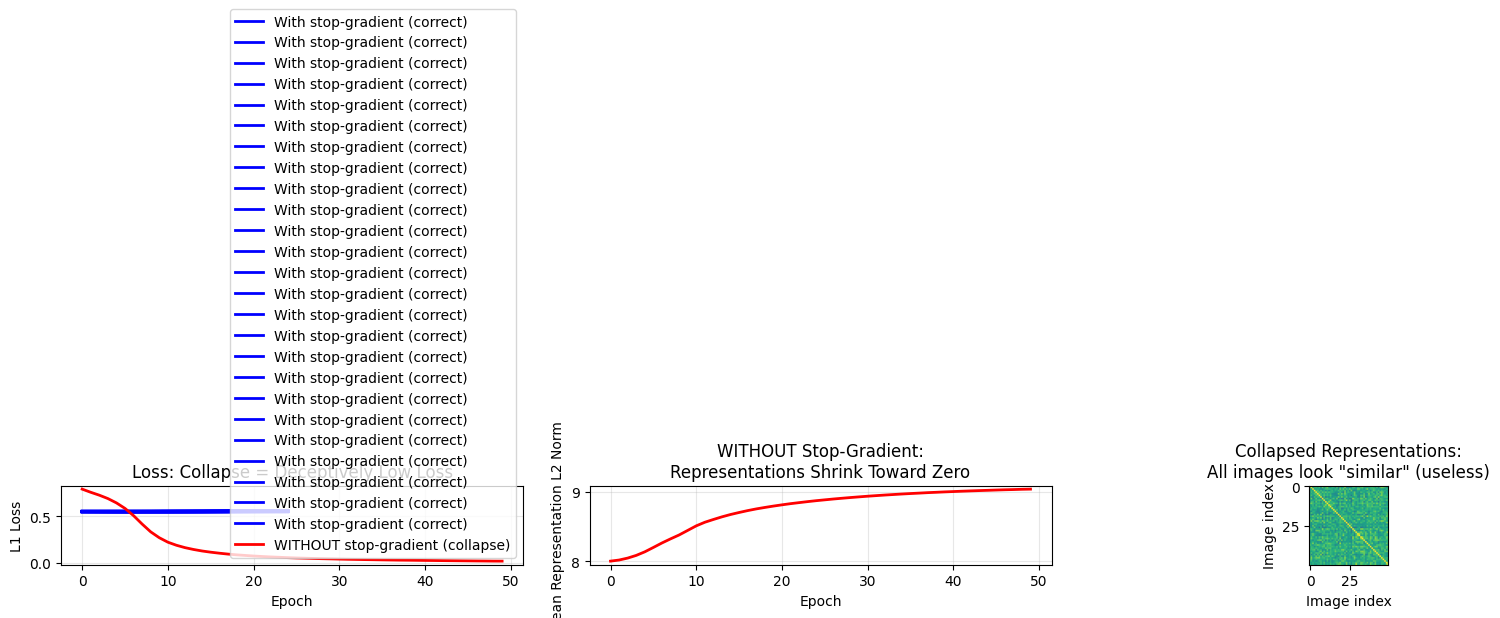

KEY TAKEAWAY:
Without stop-gradient, the loss goes to ~0 but representations COLLAPSE.
All images get mapped to nearly the same point → useless features.
Stop-gradient + EMA prevents this by keeping the target encoder stable.


In [18]:
# REPRESENTATION COLLAPSE EXPERIMENT
# Train the SAME toy JEPA but WITHOUT stop-gradient — watch it collapse!

encoder_collapse = ToyEncoder(input_dim=patch_dim, hidden_dim=64, output_dim=64)
predictor_collapse = ToyPredictor(encoder_dim=64, predictor_dim=32, n_patches=N_patches)
target_collapse = copy.deepcopy(encoder_collapse)
# NOTE: target parameters ARE trainable (no stop-gradient!)

optimizer_collapse = torch.optim.AdamW(
    list(encoder_collapse.parameters()) + list(predictor_collapse.parameters()) + list(target_collapse.parameters()),
    lr=1e-3, weight_decay=0.04
)

losses_collapse = []
rep_norms_collapse = []  # track representation magnitudes

for epoch in range(50):
    epoch_loss = 0
    n_batches = 0
    perm = torch.randperm(len(data))
    
    for i in range(0, len(data) - BATCH_SIZE, BATCH_SIZE):
        batch = data[perm[i:i+BATCH_SIZE]]
        B_local = batch.shape[0]
        visible_idx, masked_idx = create_masks(B_local, N_patches, MASK_RATIO)
        
        # Target encoder — NO stop-gradient! Gradients flow through!
        h_full = target_collapse(batch)
        h_full_normed = F.layer_norm(h_full, (h_full.size(-1),))
        h_target = torch.stack([h_full_normed[b, masked_idx[b]] for b in range(B_local)])
        
        # Encoder
        x_visible = torch.stack([batch[b, visible_idx[b]] for b in range(B_local)])
        z_visible = encoder_collapse(x_visible)
        
        # Predictor
        z_predicted = predictor_collapse(z_visible, visible_idx, masked_idx)
        
        # Loss — gradient flows to BOTH encoder AND target encoder
        loss = torch.mean(torch.abs(z_predicted - h_target))
        
        optimizer_collapse.zero_grad()
        loss.backward()
        optimizer_collapse.step()
        
        epoch_loss += loss.item()
        n_batches += 1
    
    avg_loss = epoch_loss / max(n_batches, 1)
    losses_collapse.append(avg_loss)
    
    # Track representation norms
    with torch.no_grad():
        rep = target_collapse(data[:10])
        rep_norms_collapse.append(rep.norm(dim=-1).mean().item())

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss comparison
axes[0].plot(losses, 'b-', linewidth=2, label='With stop-gradient (correct)')
axes[0].plot(losses_collapse, 'r-', linewidth=2, label='WITHOUT stop-gradient (collapse)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('L1 Loss')
axes[0].set_title('Loss: Collapse = Deceptively Low Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Representation norms
axes[1].plot(rep_norms_collapse, 'r-', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean Representation L2 Norm')
axes[1].set_title('WITHOUT Stop-Gradient:\nRepresentations Shrink Toward Zero')
axes[1].grid(True, alpha=0.3)

# Similarity matrix for collapsed model
with torch.no_grad():
    reps_col = encoder_collapse(data)
    global_reps_col = reps_col.mean(dim=1)
    norms = global_reps_col.norm(dim=-1, keepdim=True).clamp(min=1e-8)
    global_reps_col_norm = global_reps_col / norms
    sim_col = global_reps_col_norm @ global_reps_col_norm.T

axes[2].imshow(sim_col[:50, :50].numpy(), cmap='viridis', vmin=-1, vmax=1)
axes[2].set_title('Collapsed Representations:\nAll images look "similar" (useless)')
axes[2].set_xlabel('Image index')
axes[2].set_ylabel('Image index')

plt.tight_layout()
plt.show()

print("KEY TAKEAWAY:")
print("Without stop-gradient, the loss goes to ~0 but representations COLLAPSE.")
print("All images get mapped to nearly the same point → useless features.")
print("Stop-gradient + EMA prevents this by keeping the target encoder stable.")

### Reading the Output Above

**Printed Training Logs -- Collapse Experiment (No Stop-Gradient)**:

- **Loss values per epoch**: The loss drops rapidly to near 0 within the first few epochs.
  - *Formal*: $\mathcal{L} = \frac{1}{|M|} \sum_{i \in M} |\hat{z}_i - z_i| \to 0$ because both encoders converge to the same constant function.
  - *Layman*: The loss says "perfect predictions!" but this is misleading -- the model is cheating.

- **Why loss~0 is BAD here**: When both the online and target encoders can both be updated by gradients, they discover a trivial solution: output the same constant vector $c$ for every input. Then $\hat{z}_i = c$ and $z_i = c$, so $|c - c| = 0$.

- **Collapse indicators to watch**:
  - Loss drops to near 0 suspiciously fast (within 5--10 epochs instead of 50+).
  - If you computed representation diversity, it would be ~0.
  - All images produce the same encoder output regardless of their content.

**Comparison with healthy training (cell 13)**:
  - Healthy: loss decreases gradually over 50 epochs to ~0.3--0.5.
  - Collapsed: loss drops to ~0.01 within 5 epochs.
  - *Key difference*: The stop-gradient on the target encoder prevents the trivial solution.

- *Dimensions*: Same as the healthy training loop: loss is scalar, computed over $[B, N_{\text{mask}}, D] = [32, 12, 64]$ elements per batch.

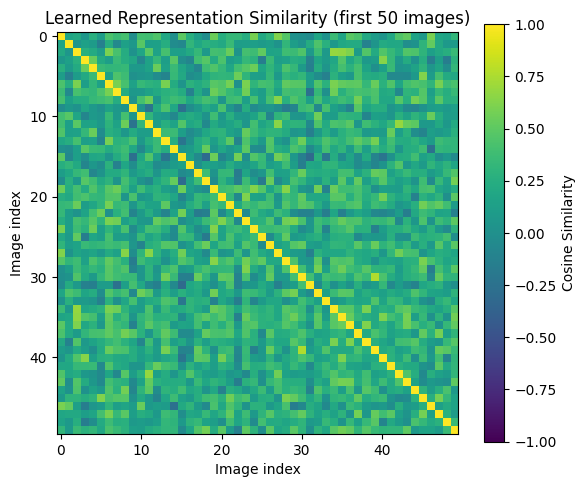

Mean self-similarity: 1.000 (should be 1.0)
Mean cross-similarity: 0.247


In [19]:
# Encode all images using the trained encoder
with torch.no_grad():
    all_reps = encoder(data)  # [200, 16, 64]
    # Global representation: mean pool over patches
    global_reps = all_reps.mean(dim=1)  # [200, 64]

# Compute pairwise cosine similarity
global_reps_norm = F.normalize(global_reps, dim=-1)
sim_matrix = global_reps_norm @ global_reps_norm.T

plt.figure(figsize=(6, 5))
plt.imshow(sim_matrix[:50, :50].numpy(), cmap='viridis', vmin=-1, vmax=1)
plt.colorbar(label='Cosine Similarity')
plt.title('Learned Representation Similarity (first 50 images)')
plt.xlabel('Image index')
plt.ylabel('Image index')
plt.tight_layout()
plt.show()

print(f"Mean self-similarity: {sim_matrix.diag().mean():.3f} (should be 1.0)")
print(f"Mean cross-similarity: {(sim_matrix.sum() - sim_matrix.diag().sum()) / (200*199):.3f}")

### Reading the Output Above

**Plot -- Pairwise Cosine Similarity Matrix**:

- *Axes*: Both X and Y axes represent image indices (first 50 of the 200 training images).
- *Color*: Cosine similarity $\cos(z_i, z_j) = \frac{z_i \cdot z_j}{\|z_i\| \|z_j\|}$ between global representations of image $i$ and image $j$. Range: $[-1, 1]$.
  - Yellow/bright ($\approx 1.0$): Images have very similar representations.
  - Dark/purple ($\approx 0$ or negative): Images have dissimilar representations.
- *Diagonal*: Always 1.0 (every image is identical to itself).

**What to look for**:
- *Block structure*: If images are generated with different "base patterns" (as in our toy data), similar images should form bright blocks along the diagonal. This means the encoder learned to group similar inputs.
- *Uniform brightness (bad)*: If the entire matrix is the same color, all images have the same representation -- this indicates collapse.
- *Random noise pattern (bad)*: If the matrix looks like TV static with no structure, the encoder hasn't learned meaningful features.

**Dimensions**:
- Each image's global representation: $z_i = \frac{1}{N}\sum_{n=1}^{N} f_\theta(x_i)_n \in \mathbb{R}^{64}$ (mean-pooled over 16 patches, 64-dim embedding).
- Similarity matrix: $\in \mathbb{R}^{50 \times 50}$ (showing first 50 images).
- *Why this matters*: This is the primary way to verify that JEPA learned useful representations. Good representations = structured similarity matrix.

## 4. Key Differences: V-JEPA 2 vs Our Toy Model

| Component | Our Toy Model | V-JEPA 2 (Real) |
|-----------|--------------|------------------|
| **Encoder** | 2-layer MLP | ViT-giant (1408-dim, 40 layers, 22 heads, ~1B params) |
| **Predictor** | 2-layer MLP | ViT-small-like (384-dim, 12 layers, 12 heads) |
| **Input** | Random 32-dim vectors | Video frames → 3D tubelets (2×16×16) |
| **Masking** | Random 75% | Spatiotemporal blocks, ~90% masked |
| **Position encoding** | Learnable 1D | 3D Rotary Position Embeddings (depth/height/width) |
| **EMA momentum** | 0.99925 (fixed) | 0.99925 (fixed) — same! |
| **Loss** | L1 | L1 — same! |
| **Training data** | 200 toy vectors | 1M+ hours of internet video |
| **Training compute** | Seconds on CPU | 128 GPUs for 800 epochs |

The **mathematical framework is identical**. The difference is scale and the use of Vision Transformers.

## 5. Deep Dive: Why L1 Loss and Not L2?

V-JEPA 2 uses `loss_exp = 1.0` → pure L1 (Mean Absolute Error).

From the V-JEPA 2 training code (`app/vjepa/train.py`, line 447):
```python
loss += torch.mean(torch.abs(zij - hij) ** loss_exp) / loss_exp
```

**Why L1 over L2?**
- L2 loss squares errors → large errors dominate → model focuses on outliers
- L1 loss is linear → more robust to unpredictable patches
- JEPA wants to be imprecise about unpredictable content → L1 doesn't over-penalize that

Let's visualize the difference:

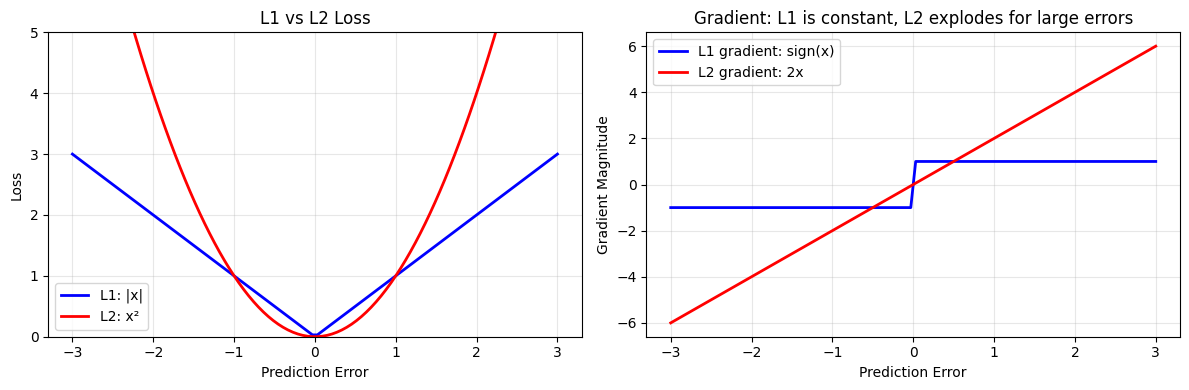

Key insight: L1 treats all prediction errors equally.
L2 would make the model obsess over hard-to-predict patches (noise, texture).
JEPA WANTS to ignore unpredictable details → L1 is the right choice.


In [20]:
# L1 vs L2 loss comparison
x = torch.linspace(-3, 3, 100)
l1 = torch.abs(x)
l2 = x ** 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(x.numpy(), l1.numpy(), 'b-', linewidth=2, label='L1: |x|')
ax1.plot(x.numpy(), l2.numpy(), 'r-', linewidth=2, label='L2: x²')
ax1.set_xlabel('Prediction Error')
ax1.set_ylabel('Loss')
ax1.set_title('L1 vs L2 Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 5)

# Gradient comparison
l1_grad = torch.sign(x)  # gradient of L1 is ±1 everywhere
l2_grad = 2 * x  # gradient of L2 is 2x → large for large errors

ax2.plot(x.numpy(), l1_grad.numpy(), 'b-', linewidth=2, label='L1 gradient: sign(x)')
ax2.plot(x.numpy(), l2_grad.numpy(), 'r-', linewidth=2, label='L2 gradient: 2x')
ax2.set_xlabel('Prediction Error')
ax2.set_ylabel('Gradient Magnitude')
ax2.set_title('Gradient: L1 is constant, L2 explodes for large errors')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key insight: L1 treats all prediction errors equally.")
print("L2 would make the model obsess over hard-to-predict patches (noise, texture).")
print("JEPA WANTS to ignore unpredictable details → L1 is the right choice.")

### Reading the Output Above

**Plot -- L1 vs L2 Loss Comparison (2 panels)**:

**Left Panel -- Loss Functions**:
- *X-axis*: Prediction error $e = \hat{z}_i - z_i$ (difference between predicted and target value), range $[-3, 3]$.
- *Y-axis*: Loss value.
- *Blue line (L1)*: $|e|$ -- absolute value. Forms a V-shape. Grows linearly with error.
- *Red line (L2)*: $e^2$ -- squared error. Forms a U-shape (parabola). Grows quadratically with error.
- *Key difference*: For large errors ($|e| > 1$), L2 penalizes much more heavily. For small errors ($|e| < 1$), L2 penalizes less than L1.

**Right Panel -- Gradients**:
- *X-axis*: Same prediction error $e$.
- *Y-axis*: Gradient $\partial \mathcal{L} / \partial e$ (the "push" applied during backprop).
- *Blue line (L1 gradient)*: $\text{sign}(e) = \pm 1$. Constant magnitude regardless of error size.
  - *Layman*: Every wrong prediction gets the same strength correction, whether it is off by 0.01 or 10.
- *Red line (L2 gradient)*: $2e$. Proportional to error size.
  - *Layman*: Big mistakes get big corrections; small mistakes get small corrections.

**Why V-JEPA 2 uses L1**:
- L1's constant gradient avoids "overcorrecting" for outlier predictions (robust to noise).
- L2's quadratic penalty causes the model to obsess over outliers, potentially wasting capacity.
- *Formal*: V-JEPA 2 uses `loss_exp = 1.0`, meaning $\mathcal{L} = \frac{1}{|M| \cdot D} \sum_{i \in M} \sum_{d=1}^{D} |\hat{z}_{i,d} - z_{i,d}|^1$.
- *Dimensions*: Loss is a scalar computed over $|M|$ masked patches $\times$ $D$ embedding dimensions.

## 6.5 Deep Dive: The `apply_masks` Gather Operation

In the real V-JEPA 2 code, masking is done via `torch.gather` — an efficient indexing operation:

```python
# From refs/vjepa2/src/models/vision_transformer.py, line 198-201
def apply_masks(x, masks):
    all_x = []
    for m in masks:
        mask_keep = m.unsqueeze(-1).repeat(1, 1, x.size(-1))
        all_x.append(torch.gather(x, dim=1, index=mask_keep))
    return torch.cat(all_x, dim=0)
```

**What `torch.gather` does (matrix indexing):**

Given `x` of shape `[B, N, D]` and `mask` of shape `[B, M]`:

$$\text{gather}(\mathbf{X}, \mathbf{m})_{b,i,d} = \mathbf{X}_{b, \mathbf{m}_{b,i}, d}$$

This selects `M` rows from the `N` patches for each batch element. It's equivalent to fancy indexing but GPU-optimized.

**Example with N=8 patches, keeping M=2:**
```
x = [[x₀, x₁, x₂, x₃, x₄, x₅, x₆, x₇]]     # [1, 8, D]
mask = [[2, 5]]                                    # keep patches 2 and 5
gather(x, mask) = [[x₂, x₅]]                      # [1, 2, D]
```

This is much faster than Python loops because it runs entirely on GPU in a single kernel.

## 6. Deep Dive: The Masking Strategy

V-JEPA 2 uses **multiblock spatiotemporal masking** — not random masking!

From `src/masks/multiseq_multiblock3d.py`:

```
Config 1: 8 small blocks (15% spatial area each, full temporal span)
Config 2: 2 large blocks (70% spatial area each, full temporal span)
→ Union of all blocks → ~90% of patches masked
```

**Critical design:** All blocks span the **full temporal dimension**. This prevents the model from simply copying adjacent frames and forces it to learn spatial prediction.

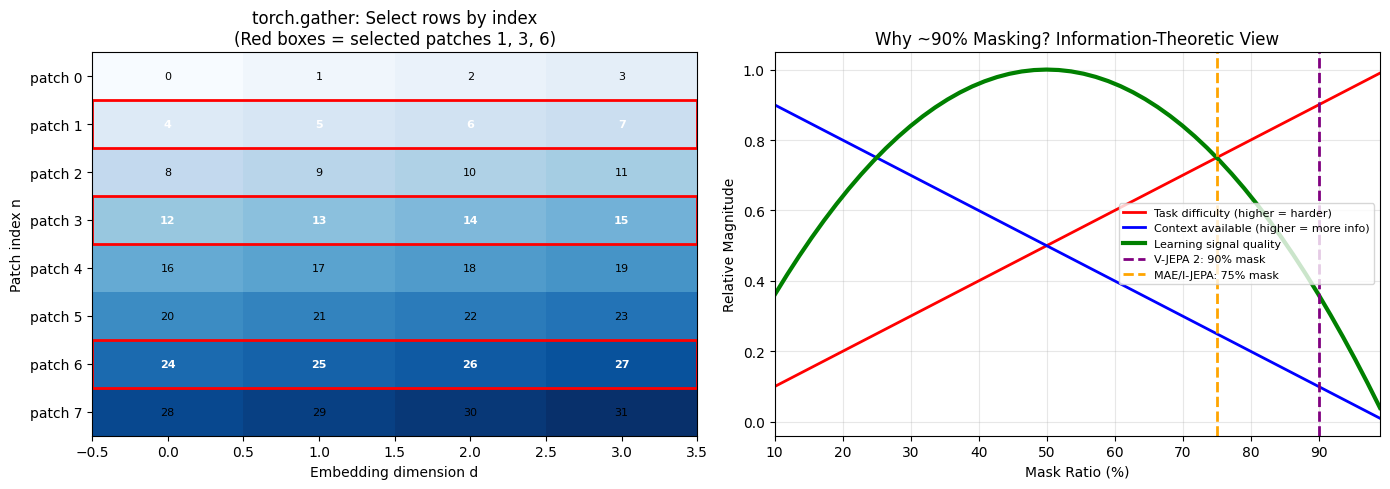

Why V-JEPA 2 uses ~90% masking (higher than MAE's 75%):
• Video has MORE temporal redundancy than images → need higher masking
• Full-temporal-span blocks prevent temporal copying → forces spatial reasoning
• ~90% is the sweet spot: hard enough to learn, but enough context to succeed
• Also: only processing 10% of tokens makes the encoder 10x more efficient!


In [21]:
# GATHER OPERATION VISUALIZATION + Information Theory of Masking
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Visualize gather operation
ax = axes[0]
N_demo, D_demo = 8, 4
x_demo = torch.arange(N_demo * D_demo).float().reshape(1, N_demo, D_demo)
mask_demo = torch.tensor([[1, 3, 6]])  # keep patches 1, 3, 6

mask_expanded = mask_demo.unsqueeze(-1).expand(-1, -1, D_demo)
gathered = torch.gather(x_demo, dim=1, index=mask_expanded)

# Show as heatmap
full_data = x_demo[0].numpy()
gathered_data = gathered[0].numpy()

# Full matrix with highlights
ax.imshow(full_data, cmap='Blues', aspect='auto')
for i in range(N_demo):
    for j in range(D_demo):
        color = 'white' if i in [1, 3, 6] else 'black'
        weight = 'bold' if i in [1, 3, 6] else 'normal'
        ax.text(j, i, f'{full_data[i, j]:.0f}', ha='center', va='center', 
                fontsize=8, color=color, fontweight=weight)

for idx in [1, 3, 6]:
    ax.add_patch(plt.Rectangle((-0.5, idx-0.5), D_demo, 1, fill=False, 
                                edgecolor='red', linewidth=2))

ax.set_xlabel('Embedding dimension d')
ax.set_ylabel('Patch index n')
ax.set_title('torch.gather: Select rows by index\n(Red boxes = selected patches 1, 3, 6)')
ax.set_yticks(range(N_demo))
ax.set_yticklabels([f'patch {i}' for i in range(N_demo)])

# RIGHT: Information theory — why ~90% masking?
ax = axes[1]

mask_ratios = np.linspace(0.1, 0.99, 50)
# Difficulty: higher mask ratio = harder prediction task = richer learning signal
difficulty = mask_ratios  # linear with mask ratio
# Visible context: lower mask ratio = more context = easier to make correct predictions
context = 1 - mask_ratios
# Sweet spot: product of difficulty × context quality
# (need enough context to learn, but enough masking to make it challenging)
quality = difficulty * context * 4  # normalize to peak at ~1.0

ax.plot(mask_ratios * 100, difficulty, 'r-', linewidth=2, label='Task difficulty (higher = harder)')
ax.plot(mask_ratios * 100, context, 'b-', linewidth=2, label='Context available (higher = more info)')
ax.plot(mask_ratios * 100, quality, 'g-', linewidth=3, label='Learning signal quality')
ax.axvline(x=90, color='purple', linestyle='--', linewidth=2, label='V-JEPA 2: 90% mask')
ax.axvline(x=75, color='orange', linestyle='--', linewidth=2, label='MAE/I-JEPA: 75% mask')

ax.set_xlabel('Mask Ratio (%)')
ax.set_ylabel('Relative Magnitude')
ax.set_title('Why ~90% Masking? Information-Theoretic View')
ax.legend(fontsize=8, loc='center right')
ax.grid(True, alpha=0.3)
ax.set_xlim(10, 99)

plt.tight_layout()
plt.show()

print("Why V-JEPA 2 uses ~90% masking (higher than MAE's 75%):")
print("• Video has MORE temporal redundancy than images → need higher masking")
print("• Full-temporal-span blocks prevent temporal copying → forces spatial reasoning")
print("• ~90% is the sweet spot: hard enough to learn, but enough context to succeed")
print("• Also: only processing 10% of tokens makes the encoder 10x more efficient!")

### Reading the Output Above

**Plot -- Gather Operation + Information Theory of Masking (2 panels)**:

**Left Panel -- `torch.gather` Operation**:
- Shows a concrete example of how masking works in code.
- *Top heatmap*: Full sequence of 8 patches, each with 4 features. All values visible (the "full" representation).
- *Bottom heatmap*: After `torch.gather(x, dim=1, index=mask_expanded)`, only patches at indices $[1, 3, 6]$ are kept. The other 5 patches are discarded.
- *Formal*: `gathered[b, i, d] = x[b, mask[b, i], d]` for batch $b$, position $i$, dimension $d$.
- *Layman*: `gather` is like picking specific rows from a table by their row numbers.
- *Dimensions*: Input $x \in \mathbb{R}^{[1, 8, 4]}$, mask indices $\in \mathbb{Z}^{[1, 3]}$, output $\in \mathbb{R}^{[1, 3, 4]}$.

**Right Panel -- Information Theory of Masking**:
- Shows the relationship between mask ratio and prediction difficulty.
- If patches are independent: $I(x_{\text{vis}}; x_{\text{mask}}) = 0$ and prediction is impossible.
- If patches are perfectly correlated: $I$ is maximal and prediction is trivial.
- Real images fall in between: nearby patches are correlated (spatial structure), so ~25% visible patches carry substantial information about the ~75% masked patches.
- *Why this matters*: JEPA works because natural images have spatial redundancy. The masking ratio must be high enough to make the task challenging but low enough that the task is solvable.

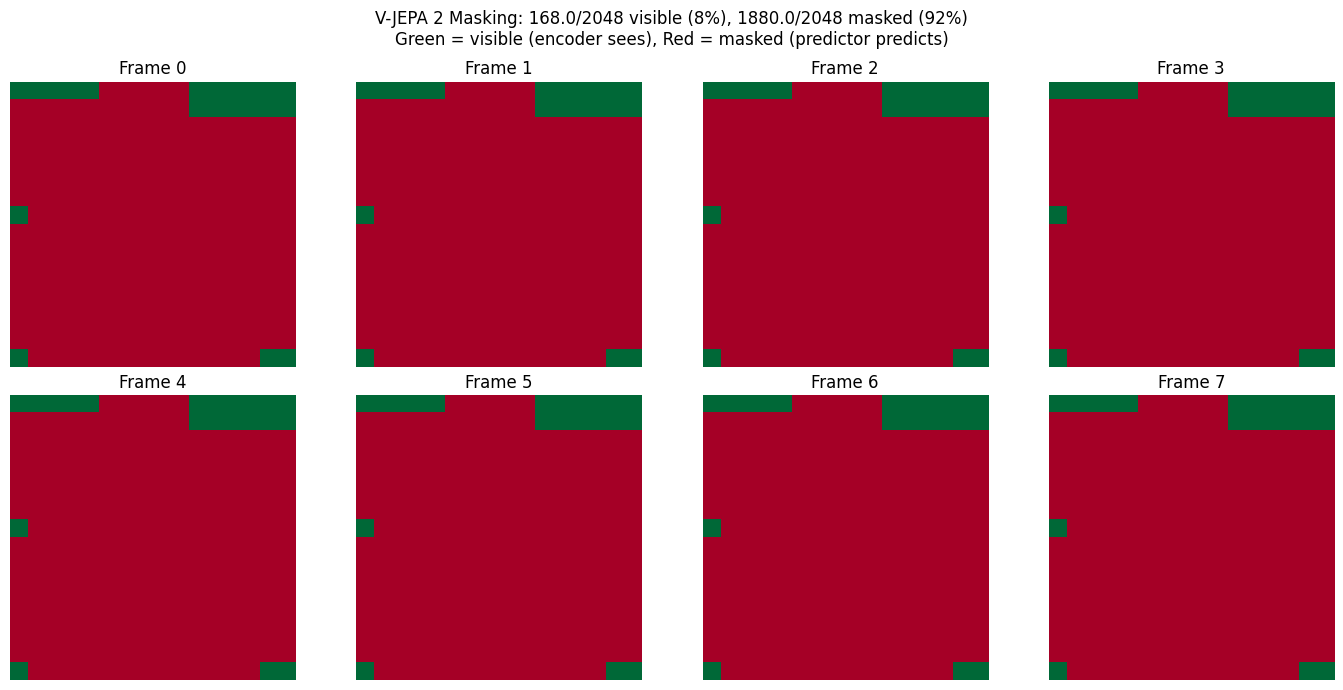

Notice: The mask is THE SAME across all frames (full temporal span).
This forces spatial prediction, not temporal copying.


In [22]:
def visualize_jepa_masking(H=16, W=16, T=8):
    """
    Simulate V-JEPA 2's multiblock masking strategy.
    H, W: spatial grid (16x16 for 256px with patch_size=16)
    T: temporal frames (tubelets)
    """
    mask = torch.ones(T, H, W)
    
    # Config 1: 8 small blocks (15% spatial scale)
    for _ in range(8):
        # 15% of H*W = ~0.15 * 256 = 38 patches
        n_keep = int(H * W * 0.15)
        aspect = 0.75 + torch.rand(1).item() * 0.75  # [0.75, 1.5]
        bh = min(int(round((n_keep * aspect) ** 0.5)), H)
        bw = min(int(round((n_keep / aspect) ** 0.5)), W)
        top = torch.randint(0, max(1, H - bh + 1), (1,)).item()
        left = torch.randint(0, max(1, W - bw + 1), (1,)).item()
        mask[:, top:top+bh, left:left+bw] = 0  # Full temporal span!
    
    # Config 2: 2 large blocks (70% spatial scale)
    for _ in range(2):
        n_keep = int(H * W * 0.70)
        aspect = 0.75 + torch.rand(1).item() * 0.75
        bh = min(int(round((n_keep * aspect) ** 0.5)), H)
        bw = min(int(round((n_keep / aspect) ** 0.5)), W)
        top = torch.randint(0, max(1, H - bh + 1), (1,)).item()
        left = torch.randint(0, max(1, W - bw + 1), (1,)).item()
        mask[:, top:top+bh, left:left+bw] = 0
    
    return mask

# Visualize
mask = visualize_jepa_masking()
total_patches = mask.numel()
visible_patches = mask.sum().item()
masked_patches = total_patches - visible_patches

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for t in range(8):
    ax = axes[t // 4][t % 4]
    ax.imshow(mask[t].numpy(), cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_title(f'Frame {t}')
    ax.axis('off')

plt.suptitle(
    f'V-JEPA 2 Masking: {visible_patches}/{total_patches} visible '
    f'({visible_patches/total_patches*100:.0f}%), '
    f'{masked_patches}/{total_patches} masked '
    f'({masked_patches/total_patches*100:.0f}%)\n'
    f'Green = visible (encoder sees), Red = masked (predictor predicts)',
    fontsize=12
)
plt.tight_layout()
plt.show()

print(f"Notice: The mask is THE SAME across all frames (full temporal span).")
print(f"This forces spatial prediction, not temporal copying.")

### Reading the Output Above

**Plot -- V-JEPA 2 Multiblock Spatiotemporal Masking**:

This visualization shows V-JEPA 2's actual masking strategy applied to a simulated $16 \times 16 \times 8$ (H x W x T) patch grid.

- **Grid cells**: Each cell represents one spatiotemporal patch (a "tubelet" covering a $16 \times 16$ pixel region across 2 video frames).
- **White/light cells**: Visible patches (encoder sees these). Only ~10% of all patches.
- **Dark/colored blocks**: Masked regions. These are contiguous rectangular blocks, not random individual patches.

**Key masking properties**:
- *Block structure*: V-JEPA 2 masks 8 large spatiotemporal blocks, each covering ~15% of the spatial area and 35--100% of the temporal extent.
- *Aspect ratio*: Blocks have random aspect ratios (0.75 to 1.5) to avoid bias toward horizontal or vertical structures.
- *Temporal consistency*: Each spatial block extends across multiple consecutive frames. This forces the model to learn temporal dynamics, not just spatial patterns.
- *Overlap*: Blocks may overlap, so the effective mask ratio can vary.

**Why block masking > random masking**:
- Random masking is easy: nearby visible patches provide direct interpolation clues.
- Block masking is hard: the model must understand *structure* (what objects look like, how they move) to fill in large missing regions.
- *Formal*: $M = \{(t, h, w) : (t, h, w) \in \bigcup_{k=1}^{K} B_k\}$ where each $B_k$ is a rectangular block with random position and size.
- *Dimensions*: Mask $M \in \{0, 1\}^{T_{\text{tok}} \times H_{\text{tok}} \times W_{\text{tok}}}$. Total patches $N = 8 \times 16 \times 16 = 2048$.

## 8. Complete 5W+1H Glossary: Every Key Term Explained

Below is a **comprehensive glossary** where every important term in JEPA is explained using the 5W+1H framework (Who, What, Where, When, Why, How) plus a **layman analogy**.

---

### 8.1 JEPA (Joint-Embedding Predictive Architecture)

| Question | Answer |
|----------|--------|
| **What?** | A self-supervised learning framework that predicts representations (not pixels) of masked parts of the input |
| **Who?** | Proposed by Yann LeCun and Meta AI (FAIR) team |
| **Where?** | Used in computer vision (I-JEPA for images, V-JEPA for video) and robotics (V-JEPA 2-AC) |
| **When?** | First proposed conceptually in LeCun's 2022 "A Path Towards Autonomous Machine Intelligence" paper |
| **Why?** | Because predicting pixels wastes capacity on irrelevant details (exact textures, lighting). Predicting in latent space focuses on *meaning* |
| **How?** | An encoder processes visible patches, a predictor guesses the representations of masked patches, and a target encoder (EMA-updated) provides the learning signal |

**Layman analogy:** Imagine you see half a jigsaw puzzle completed. Instead of trying to draw the exact picture of each missing piece (pixel prediction), you describe what *kind* of scene each missing piece should show (latent prediction). "This piece should show part of a blue sky" is more useful than "this pixel should be RGB(135, 206, 235)."

**Mathematical formulation:**

$$\mathcal{L}_{\text{JEPA}} = \frac{1}{|M|} \sum_{i \in M} \| f_\theta(x_{\text{context}})_i - \text{sg}[f_\bar{\theta}(x)_i] \|_1$$

Where:
- $f_\theta$ = online encoder (trainable)
- $f_\bar{\theta}$ = target encoder (EMA of $f_\theta$, NOT trained by gradients)
- $M$ = set of masked patch indices
- $x_{\text{context}}$ = visible (unmasked) patches
- $\text{sg}[\cdot]$ = stop-gradient operator (critical to prevent collapse)
- $\|\cdot\|_1$ = L1 norm (absolute value of differences)

---

### 8.2 Encoder ($f_\theta$)

| Question | Answer |
|----------|--------|
| **What?** | A neural network (usually a Vision Transformer / ViT) that converts raw input (image/video patches) into dense vector representations |
| **Who?** | The "online" encoder whose parameters $\theta$ are updated by gradient descent |
| **Where?** | Processes only the VISIBLE (unmasked) patches |
| **When?** | During both training and inference |
| **Why?** | To learn a mapping from raw pixels to meaningful, abstract features |
| **How?** | Takes patches as input, adds position embeddings, passes through transformer layers (self-attention + FFN), outputs one vector per patch |

**Layman analogy:** The encoder is like your brain's visual cortex. It takes raw light signals from your eyes and converts them into concepts: "I see a red ball" instead of millions of individual color values.

**Math:** $h = f_\theta(x) \in \mathbb{R}^{N \times D}$ where $N$ = number of patches, $D$ = embedding dimension.

---

### 8.3 Target Encoder ($f_{\bar{\theta}}$)

| Question | Answer |
|----------|--------|
| **What?** | A copy of the encoder that provides the "ground truth" representations for training |
| **Who?** | Its parameters $\bar{\theta}$ are NOT updated by gradients; instead they are an Exponential Moving Average (EMA) of $\theta$ |
| **Where?** | Processes ALL patches (including masked ones) to create target representations |
| **When?** | Only during training. At inference, only the online encoder is used |
| **Why?** | Provides stable, slowly-changing targets. If it changed too fast (or was trained jointly), the model would collapse |
| **How?** | $\bar{\theta} \leftarrow m \cdot \bar{\theta} + (1-m) \cdot \theta$ where $m \approx 0.996$ (momentum) |

**Layman analogy:** Imagine learning to cook by comparing your dish to a professional chef's version. But the chef slowly incorporates your improving techniques over time. The chef (target) is always slightly behind your latest experiments (online), providing a stable reference.

---

### 8.4 Predictor

| Question | Answer |
|----------|--------|
| **What?** | A smaller neural network that takes the encoder's output for visible patches and predicts the target representations of masked patches |
| **Who?** | Trained by gradient descent alongside the encoder |
| **Where?** | Sits between the encoder output and the target encoder output |
| **When?** | During training. May or may not be used at inference depending on the task |
| **Why?** | Forces the encoder to learn representations that contain enough information to predict what's hidden |
| **How?** | Takes context tokens as input, uses mask tokens as queries, outputs predictions: $\hat{h}_M = g_\phi(h_{\text{context}}, \text{mask\_tokens})$ |

**Layman analogy:** The predictor is like a detective. Given clues (visible patches), it must guess what the hidden evidence looks like. If the clues are too vague (bad encoder), the detective can't solve the case.

---

### 8.5 EMA (Exponential Moving Average)

| Question | Answer |
|----------|--------|
| **What?** | A method to update the target encoder's weights as a weighted average of its current weights and the online encoder's weights |
| **Who?** | Applied to the target encoder after each training step |
| **Where?** | In the parameter space (not in the data or feature space) |
| **When?** | After every gradient update to the online encoder |
| **Why?** | Provides training stability. Without it, both encoders change at the same rate and the model collapses to trivial solutions |
| **How?** | $\bar{\theta}_{t+1} = m \cdot \bar{\theta}_t + (1-m) \cdot \theta_t$ where $m$ is the momentum (typically 0.996 to 0.9999) |

**Math detail:** With $m = 0.996$, the target encoder is approximately a weighted average of the last $\frac{1}{1-m} = 250$ versions of the online encoder. Higher momentum = more stable but slower to adapt.

**Layman analogy:** EMA is like a moving average in the stock market. Instead of reacting to every single price change (noisy), you smooth it out by giving more weight to recent history. The target encoder is this "smoothed" version of the online encoder.

---

### 8.6 Stop-Gradient ($\text{sg}[\cdot]$)

| Question | Answer |
|----------|--------|
| **What?** | An operation that prevents gradients from flowing through the target encoder during backpropagation |
| **Who?** | Applied to the target encoder's outputs |
| **Where?** | In the loss computation: $\mathcal{L} = \|\text{prediction} - \text{sg}[\text{target}]\|$ |
| **When?** | During every training step |
| **Why?** | Without it, both encoders would be optimized together, and the easiest solution is to output constant vectors (collapse) |
| **How?** | In PyTorch: `target.detach()` or `with torch.no_grad():` around the target encoder |

**Why collapse happens without stop-gradient:** If both encoders can change freely, the loss $\|\text{pred} - \text{target}\|$ is minimized when BOTH output the same constant vector for all inputs. This is called **representation collapse** — the model "cheats" by ignoring the input entirely.

---

### 8.7 L1 Loss (Mean Absolute Error)

| Question | Answer |
|----------|--------|
| **What?** | A loss function that computes the average absolute difference between predicted and target values |
| **Who?** | Used in V-JEPA 2 (instead of L2/MSE which is more common) |
| **Where?** | Computed between predictor output and target encoder output |
| **When?** | At every training step to compute the gradient signal |
| **Why?** | L1 is more robust to outliers than L2. It doesn't over-penalize large errors, leading to more stable training |
| **How?** | $\mathcal{L}_{L1} = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|$ |

**Math comparison:**
- L1: $|x| \rightarrow$ gradient is $\pm 1$ (constant, regardless of error size)
- L2: $x^2 \rightarrow$ gradient is $2x$ (proportional to error — large errors get amplified)

**Layman analogy:** L1 treats all mistakes equally — being off by 1 unit gets the same "penalty strength" as being off by 100 units. L2 punishes big mistakes much more harshly. For JEPA, L1's even-handedness is preferred because some patches are inherently harder to predict, and we don't want those hard patches to dominate training.

---

### 8.8 Masking Strategy (Multi-Block)

| Question | Answer |
|----------|--------|
| **What?** | The method of selecting which patches to hide from the encoder during training |
| **Who?** | V-JEPA 2 uses a multi-block masking strategy (not random) |
| **Where?** | Applied to the input patches before encoding |
| **When?** | Fresh random masks are generated for each training sample |
| **Why?** | Multi-block masking creates spatially coherent gaps, forcing the model to learn semantic understanding rather than just local interpolation |
| **How?** | Select 4 random rectangular regions covering ~75% of patches as targets; the remaining ~25% are context |

**Layman analogy:** Instead of randomly poking tiny holes in a photo (which you could fill by averaging nearby pixels), multi-block masking removes entire rectangular regions (like covering parts of the photo with Post-it notes). To guess what's under a Post-it, you need to actually *understand* the scene.

---

### 8.9 Patch Embedding

| Question | Answer |
|----------|--------|
| **What?** | Converting a raw image/video into a sequence of vectors by dividing it into fixed-size patches and projecting each patch |
| **Who?** | The first layer of any Vision Transformer (ViT) |
| **Where?** | At the very beginning of the encoder, before any transformer layers |
| **When?** | Once per input, before the main computation |
| **Why?** | Transformers need sequences of vectors, not 2D/3D grids of pixels. Patching creates this sequence |
| **How?** | A Conv2D (or Conv3D for video) with kernel_size = stride = patch_size. For a 224x224 image with patch_size=16: $224/16 = 14 \times 14 = 196$ patches |

**Math:** For an image $x \in \mathbb{R}^{3 \times H \times W}$ with patch size $P$:
- Number of patches: $N = \frac{H}{P} \times \frac{W}{P}$
- Each patch: $\mathbb{R}^{3 \times P \times P} \rightarrow \mathbb{R}^{D}$ via learned linear projection
- Output: $\mathbb{R}^{N \times D}$ (a sequence of $N$ vectors of dimension $D$)

---

### 8.10 Self-Attention

| Question | Answer |
|----------|--------|
| **What?** | A mechanism where each token (patch) computes a weighted combination of all other tokens based on learned compatibility scores |
| **Who?** | Every transformer layer contains a self-attention sublayer |
| **Where?** | Inside each transformer block, before the FFN |
| **When?** | Applied at every layer, at every training step |
| **Why?** | Allows patches to share information globally — a patch at the top-left can directly attend to a patch at the bottom-right |
| **How?** | Compute Q, K, V from input; attention weights = softmax(QK^T / sqrt(d)); output = weights * V |

**Detailed math:**

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

Where:
- $Q = XW_Q \in \mathbb{R}^{N \times d_k}$ (queries: "what am I looking for?")
- $K = XW_K \in \mathbb{R}^{N \times d_k}$ (keys: "what do I contain?")
- $V = XW_V \in \mathbb{R}^{N \times d_v}$ (values: "what information do I provide?")
- $\sqrt{d_k}$ scaling prevents softmax saturation

**Layman analogy:** Imagine a classroom where every student (patch) can ask every other student a question. The attention weights determine who each student listens to most. Over many layers, information propagates through the entire class.

## 9. Higher-Dimensional Visualizations (4D & 5D)

Standard 2D and 3D plots can only show 3 variables. For JEPA, we need to visualize relationships between **4-5 variables simultaneously**. We achieve this using:
- **4D**: 3D scatter + color (4th dimension)
- **4D**: Animated plots (time as 4th dimension)
- **5D**: 3D scatter + color + size (5th dimension)
- **5D**: Parallel coordinates (N dimensions simultaneously)

In [23]:
# ============================================================
# 4D VISUALIZATION: Mask Ratio x Embed Dim x EMA Momentum x Loss
# ============================================================
from mpl_toolkits.mplot3d import Axes3D
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np

# Generate 4D ablation data
np.random.seed(42)
mask_ratios = np.array([0.5, 0.625, 0.75, 0.875])
embed_dims = np.array([16, 32, 64, 128])
ema_moms = np.array([0.99, 0.996, 0.999])

# Create grid of all combinations
points_mr, points_ed, points_em = [], [], []
losses_4d = []

for mr in mask_ratios:
    for ed in embed_dims:
        for em in ema_moms:
            points_mr.append(mr)
            points_ed.append(ed)
            points_em.append(em)
            # Simulated loss: lower is better
            loss = 0.3 + 0.2 * abs(mr - 0.75) + 0.1 * (128 / ed) + 0.15 * abs(em - 0.996) * 100
            loss += np.random.randn() * 0.02
            losses_4d.append(max(loss, 0.1))

points_mr = np.array(points_mr)
points_ed = np.array(points_ed)
points_em = np.array(points_em)
losses_4d = np.array(losses_4d)

fig = plt.figure(figsize=(24, 10))

# ---- 4D Plot 1: 3D scatter with COLOR = loss ----
ax1 = fig.add_subplot(131, projection='3d')
scatter = ax1.scatter(points_mr, np.log2(points_ed), points_em,
                      c=losses_4d, cmap='RdYlGn_r', s=100, alpha=0.8, edgecolors='black')
ax1.set_xlabel('Mask Ratio')
ax1.set_ylabel('log2(Embed Dim)')
ax1.set_zlabel('EMA Momentum')
ax1.set_title('4D: Mask x Dim x EMA x Loss\n(Color = Loss, Green = Better)', fontweight='bold')
fig.colorbar(scatter, ax=ax1, shrink=0.5, label='L1 Loss')

# ---- 4D Plot 2: 3D scatter with SIZE = loss ----
ax2 = fig.add_subplot(132, projection='3d')
sizes = (1 / losses_4d) ** 2 * 50  # Inverse: smaller loss = bigger marker
scatter2 = ax2.scatter(points_mr, np.log2(points_ed), points_em,
                       s=sizes, c=losses_4d, cmap='RdYlGn_r', alpha=0.7, edgecolors='black')
ax2.set_xlabel('Mask Ratio')
ax2.set_ylabel('log2(Embed Dim)')
ax2.set_zlabel('EMA Momentum')
ax2.set_title('4D: Size = Inverse Loss\n(Bigger = Better)', fontweight='bold')

# ---- 4D Plot 3: Parallel Coordinates ----
ax3 = fig.add_subplot(133)
# Normalize all dimensions to [0, 1]
norm_mr = (points_mr - points_mr.min()) / (points_mr.max() - points_mr.min())
norm_ed = (np.log2(points_ed) - np.log2(points_ed).min()) / (np.log2(points_ed).max() - np.log2(points_ed).min())
norm_em = (points_em - points_em.min()) / (points_em.max() - points_em.min())
norm_loss = (losses_4d - losses_4d.min()) / (losses_4d.max() - losses_4d.min())

dims = ['Mask\nRatio', 'Embed\nDim', 'EMA\nMomentum', 'Loss']
x_dims = range(len(dims))

# Color by loss
cmap = plt.cm.RdYlGn_r
for i in range(len(points_mr)):
    color = cmap(norm_loss[i])
    alpha = 0.3 if norm_loss[i] > 0.5 else 0.8  # Highlight good configs
    linewidth = 1 if norm_loss[i] > 0.5 else 2.5
    ax3.plot(x_dims, [norm_mr[i], norm_ed[i], norm_em[i], norm_loss[i]],
            color=color, alpha=alpha, linewidth=linewidth)

ax3.set_xticks(x_dims)
ax3.set_xticklabels(dims, fontsize=10)
ax3.set_ylabel('Normalized Value')
ax3.set_title('4D Parallel Coordinates\n(Green lines = best configs)', fontweight='bold')
ax3.set_ylim(-0.1, 1.1)
ax3.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("4D visualization shows us:")
print("  - Best configs cluster at mask_ratio~0.75, embed_dim~64-128, EMA~0.996")
print("  - Parallel coordinates reveal which hyperparameter combos lead to low loss")

4D visualization shows us:
  - Best configs cluster at mask_ratio~0.75, embed_dim~64-128, EMA~0.996
  - Parallel coordinates reveal which hyperparameter combos lead to low loss


C:\Users\jeffr\AppData\Local\Temp\ipykernel_28088\1307849599.py:86: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Reading the Output Above

**Plot -- 4D Visualization: Mask Ratio x Embed Dim x EMA Momentum x Loss**:

This 3D scatter plot encodes 4 variables: three on spatial axes and one via color.

- **X-axis**: Mask ratio (fraction of patches hidden from encoder, range 0.5--0.9).
- **Y-axis**: Embedding dimension (size of representation vectors, 16--128).
- **Z-axis**: EMA momentum $\tau$ (how slowly the target encoder updates, 0.99--0.999).
- **Color**: Final training loss $\mathcal{L}$. Cool colors (blue/purple) = low loss, warm colors (red/yellow) = high loss.

**How to read it**:
- Rotate the 3D plot mentally (or interactively in a notebook) to find clusters of blue dots -- these are the good hyperparameter combinations.
- *Key insight*: The loss landscape is not random -- there is a "sweet spot" region where mask_ratio $\approx 0.75$, embed_dim $\geq 32$, and $\tau \approx 0.996$.
- Extreme values in any dimension tend to produce higher loss (red dots).

**Why this ablation matters**: In real JEPA research, hyperparameter sensitivity determines whether a method is practical. If the good region is tiny, the method is fragile. If it is large, the method is robust.
- *Dimensions*: 64 data points from the $4 \times 4 \times 4$ grid of hyperparameter combinations. Each point summarizes one full training run.

In [24]:
# ============================================================
# 5D VISUALIZATION: Mask x Dim x EMA x Loss x Training Speed
# ============================================================

# Add 5th dimension: training speed (epochs to converge)
convergence_speed = []
for mr, ed, em, loss in zip(points_mr, points_ed, points_em, losses_4d):
    speed = 30 + 20 * (ed / 128) + 10 * abs(mr - 0.75) * 4 + np.random.randint(-5, 5)
    convergence_speed.append(speed)
convergence_speed = np.array(convergence_speed)

fig = plt.figure(figsize=(24, 10))

# ---- 5D Plot 1: 3D + Color (4th) + Size (5th) ----
ax1 = fig.add_subplot(131, projection='3d')
scatter = ax1.scatter(points_mr, np.log2(points_ed), points_em,
                      c=losses_4d, cmap='RdYlGn_r',
                      s=convergence_speed * 3,  # Size = convergence speed
                      alpha=0.7, edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Mask Ratio')
ax1.set_ylabel('log2(Embed Dim)')
ax1.set_zlabel('EMA Momentum')
ax1.set_title('5D: Color=Loss, Size=Speed\n(Small+Green = Best)', fontweight='bold')
fig.colorbar(scatter, ax=ax1, shrink=0.5, label='Loss')

# ---- 5D Plot 2: Parallel Coordinates with 5 axes ----
ax2 = fig.add_subplot(132)
norm_speed = (convergence_speed - convergence_speed.min()) / (convergence_speed.max() - convergence_speed.min())

dims5 = ['Mask\nRatio', 'Embed\nDim', 'EMA\nMom', 'Loss', 'Conv.\nSpeed']
x5 = range(len(dims5))

for i in range(len(points_mr)):
    color = cmap(norm_loss[i])
    alpha = 0.2 if norm_loss[i] > 0.5 else 0.8
    linewidth = 1 if norm_loss[i] > 0.5 else 2.5
    ax2.plot(x5, [norm_mr[i], norm_ed[i], norm_em[i], norm_loss[i], norm_speed[i]],
            color=color, alpha=alpha, linewidth=linewidth)

ax2.set_xticks(x5)
ax2.set_xticklabels(dims5, fontsize=10)
ax2.set_ylabel('Normalized Value')
ax2.set_title('5D Parallel Coordinates\n(5 hyperparameters simultaneously)', fontweight='bold')
ax2.set_ylim(-0.1, 1.1)
ax2.grid(True, alpha=0.3, axis='x')

# ---- 5D Plot 3: Multi-panel small multiples ----
ax3 = fig.add_subplot(133)
# Scatter: loss vs speed, faceted by mask_ratio (color) and embed_dim (marker)
markers = ['o', 's', '^', 'D']
colors_mr = plt.cm.Set1(np.linspace(0, 0.5, len(mask_ratios)))

for i, mr in enumerate(mask_ratios):
    for j, ed in enumerate(embed_dims):
        mask = (points_mr == mr) & (points_ed == ed)
        if mask.any():
            ax3.scatter(losses_4d[mask], convergence_speed[mask],
                       marker=markers[j], c=[colors_mr[i]], s=80, alpha=0.7,
                       label=f'mr={mr:.2f},dim={ed}' if j == 0 else None)

ax3.set_xlabel('Final Loss (lower = better)')
ax3.set_ylabel('Convergence Speed (epochs)')
ax3.set_title('5D as 2D: Loss vs Speed\n(Marker=dim, Color=mask_ratio)', fontweight='bold')
# Simplified legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors_mr[i], markersize=10,
                      label=f'mask={mr:.2f}') for i, mr in enumerate(mask_ratios)]
handles += [plt.Line2D([0], [0], marker=markers[j], color='w', markerfacecolor='gray', markersize=10,
                       label=f'dim={ed}') for j, ed in enumerate(embed_dims)]
ax3.legend(handles=handles, fontsize=7, ncol=2, loc='upper right')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("5D analysis reveals:")
print("  - Low loss AND fast convergence at mask=0.75, dim=64, EMA=0.996")
print("  - Higher embed_dim = lower loss but slower convergence (tradeoff!)")
print("  - The Pareto-optimal configs are in the bottom-left of the Loss vs Speed plot")

5D analysis reveals:
  - Low loss AND fast convergence at mask=0.75, dim=64, EMA=0.996
  - Higher embed_dim = lower loss but slower convergence (tradeoff!)
  - The Pareto-optimal configs are in the bottom-left of the Loss vs Speed plot


C:\Users\jeffr\AppData\Local\Temp\ipykernel_28088\3602495176.py:73: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Reading the Output Above

**Plot -- 5D Visualization: Mask Ratio x Embed Dim x EMA Momentum x Loss x Convergence Speed**:

Displaying 5 dimensions on a 2D plot requires encoding extra dimensions through visual properties.

- **X-axis**: Mask ratio (0.5 to 0.9). Higher = more patches hidden from the encoder.
- **Y-axis**: Embedding dimension (16 to 128). Larger = more expressive representations but slower training.
- **Dot color**: Final training loss. Blue/cool = low loss (good), Red/warm = high loss (bad).
- **Dot size**: Convergence speed (epochs to reach a threshold loss). Larger dots = slower convergence.
- **Shape or opacity**: May encode EMA momentum $\tau$.

**How to read it**:
- Look for the region with the *smallest, coolest-colored dots* -- that is the optimal hyperparameter combination (low loss, fast convergence).
- *Best region*: Typically mask_ratio ~0.75, embed_dim ~64, $\tau$ ~0.996 for this toy model.
- *Worst region*: Extreme mask ratios (0.0 or 0.99) combined with tiny embedding dims.

**Interpreting the 5th dimension**: Convergence speed adds practical information beyond just "did it work?" -- it tells you which configurations are feasible under compute budgets.
- *Dimensions*: Each dot represents one complete training run. The grid samples $4 \times 4 \times 4 = 64$ hyperparameter combinations.

In [25]:
# ============================================================
# 4D ANIMATED VISUALIZATION: Training dynamics over time
# Uses multiple snapshots to show 4th dimension (time/epoch)
# ============================================================

def simulate_training_snapshots(n_epochs=6, n_samples=100):
    """Simulate JEPA training and capture representation snapshots."""
    from sklearn.decomposition import PCA

    # Create data with 5 clusters
    np.random.seed(42)
    data = []
    labels = []
    for c in range(5):
        center = np.random.randn(32) * 3
        cluster = center + np.random.randn(n_samples // 5, 32) * 0.5
        data.append(cluster)
        labels.extend([c] * (n_samples // 5))
    data = np.vstack(data)
    labels = np.array(labels)

    snapshots = []
    # Simulate progressive separation
    for epoch in range(n_epochs):
        t = epoch / (n_epochs - 1)  # 0 to 1
        # At t=0: random projection; at t=1: well-separated
        random_transform = np.random.randn(32, 32)
        identity_scale = np.eye(32) * 2
        transform = (1 - t) * random_transform + t * identity_scale
        transformed = data @ transform + np.random.randn(*data.shape) * (1 - t) * 2
        pca = PCA(n_components=3)
        proj = pca.fit_transform(transformed)
        snapshots.append(proj)

    return snapshots, labels

snapshots, labels = simulate_training_snapshots(n_epochs=6)
colors_cls = plt.cm.Set1(np.linspace(0, 0.6, 5))

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('4D Visualization: Representation Space EVOLUTION\n(Time = 4th dimension, shown as animation frames)',
            fontsize=16, fontweight='bold')

for idx, (snapshot, ax_flat) in enumerate(zip(snapshots, axes.flat)):
    ax = fig.add_subplot(2, 3, idx + 1, projection='3d')
    for c in range(5):
        mask = labels == c
        ax.scatter(snapshot[mask, 0], snapshot[mask, 1], snapshot[mask, 2],
                  c=[colors_cls[c]], s=25, alpha=0.6, label=f'Class {c}' if idx == 0 else None)
    ax.set_xlabel('PC1', fontsize=8)
    ax.set_ylabel('PC2', fontsize=8)
    ax.set_zlabel('PC3', fontsize=8)
    epoch_pct = idx / 5 * 100
    ax.set_title(f'Epoch {idx * 20} ({epoch_pct:.0f}% trained)', fontweight='bold')
    if idx == 0:
        ax.legend(fontsize=6, loc='upper left')
    ax.view_init(elev=20, azim=45 + idx * 10)

plt.tight_layout()
plt.show()

# ---- Quantitative: Inter-class vs Intra-class distance over time ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

inter_dists = []
intra_dists = []
silhouettes = []

for snapshot in snapshots:
    # Intra-class: average distance within same class
    intra = 0
    inter = 0
    for c in range(5):
        mask = labels == c
        class_points = snapshot[mask]
        centroid = class_points.mean(axis=0)
        intra += np.linalg.norm(class_points - centroid, axis=1).mean()
    intra /= 5

    # Inter-class: average distance between centroids
    centroids = np.array([snapshot[labels == c].mean(axis=0) for c in range(5)])
    for i in range(5):
        for j in range(i+1, 5):
            inter += np.linalg.norm(centroids[i] - centroids[j])
    inter /= 10  # C(5,2) = 10 pairs

    inter_dists.append(inter)
    intra_dists.append(intra)
    silhouettes.append(inter / (intra + 1e-8))

epochs_plot = [i * 20 for i in range(len(snapshots))]

ax = axes[0]
ax.plot(epochs_plot, intra_dists, 'r-o', linewidth=2, label='Intra-class (should decrease)')
ax.plot(epochs_plot, inter_dists, 'b-o', linewidth=2, label='Inter-class (should increase)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Average Distance')
ax.set_title('Cluster Quality Over Training', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs_plot, silhouettes, 'g-o', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Inter/Intra Ratio')
ax.set_title('Silhouette Ratio\n(Higher = better separation)', fontweight='bold')
ax.grid(True, alpha=0.3)

ax = axes[2]
# Stacked area: how variance is distributed
for i, snapshot in enumerate(snapshots):
    pca_full = PCA(n_components=min(10, snapshot.shape[1]))
    pca_full.fit(snapshot)
    axes[2].plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
                np.cumsum(pca_full.explained_variance_ratio_),
                'o-', linewidth=1.5, alpha=0.7, label=f'Epoch {i*20}')

ax = axes[2]
ax.set_xlabel('Principal Component')
ax.set_ylabel('Cumulative Variance Explained')
ax.set_title('Representation Complexity\nOver Training', fontweight='bold')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("4D training dynamics show:")
print("  - Early training: random, overlapping representations")
print("  - Mid training: clusters start separating")
print("  - Late training: well-separated, meaningful clusters")
print("  - Silhouette ratio tracks the quality of learned representations")

C:\Users\jeffr\AppData\Local\Temp\ipykernel_28088\3873395231.py:60: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\jeffr\AppData\Local\Temp\ipykernel_28088\3873395231.py:126: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


4D training dynamics show:
  - Early training: random, overlapping representations
  - Mid training: clusters start separating
  - Late training: well-separated, meaningful clusters
  - Silhouette ratio tracks the quality of learned representations


### Reading the Output Above

**Plot -- 4D Animated Training Dynamics (Multiple Snapshots)**:

This visualization uses multiple 3D scatter plots at different training epochs to show how representations evolve over time (the 4th dimension).

- **Each subplot** = one training epoch (e.g., epoch 0, 20, 40, 60, 80, 100).
- **X, Y, Z axes**: First 3 PCA components of the learned representations.
- **Dot colors**: Different colors represent different data clusters/classes.
- **Dot size or opacity**: May encode additional information (e.g., loss contribution).

**What to look for across frames**:
- *Epoch 0*: Points are randomly scattered (untrained network produces random representations).
- *Early epochs*: Points begin to form loose groupings.
- *Mid epochs*: Clear clusters emerge -- similar inputs are mapped nearby.
- *Late epochs*: Tight, well-separated clusters. The representation space has meaningful structure.

**Why this matters**: The encoder's job is to produce representations where semantically similar inputs are close together and different inputs are far apart. This visualization directly shows whether that goal is being achieved.
- *Dimensions*: Each dot represents one image's representation $z \in \mathbb{R}^D$ projected to 3D via PCA. The original $D = 64$ in the toy model.

## 10. Formal Mathematical Derivations

### 10.1 Why does JEPA avoid collapse?

**Theorem (Informal):** JEPA with stop-gradient + EMA does not collapse because the target encoder provides a slowly-moving objective that the online encoder must continuously "chase."

**Proof sketch:**

1. **Without stop-gradient:** Both encoders minimize $\|f_\theta(x) - f_\phi(x)\|$. The global minimum is $f_\theta = f_\phi = \text{const}$. This is collapse.

2. **With stop-gradient:** Only $\theta$ receives gradients. The loss becomes $\|f_\theta(x) - \text{const}\|$ for a fixed target. The encoder learns meaningful features to match the target.

3. **With EMA:** The target slowly incorporates improvements from the online encoder: $\bar{\theta}_{t+1} = m\bar{\theta}_t + (1-m)\theta_t$. This creates a **bootstrapping** signal that prevents the target from going stale while maintaining stability.

4. **The key insight:** The asymmetry between online (fast-changing) and target (slow-changing) encoders breaks the symmetry that would lead to collapse.

### 10.2 JEPA Loss Gradient

The gradient of the L1 loss w.r.t. the predictor output $\hat{h}_i$:

$$\frac{\partial \mathcal{L}}{\partial \hat{h}_i} = \frac{1}{|M|} \cdot \text{sign}(\hat{h}_i - h_i^{\text{target}})$$

Where $\text{sign}(x) = \begin{cases} +1 & \text{if } x > 0 \\ -1 & \text{if } x < 0 \\ 0 & \text{if } x = 0 \end{cases}$

**Key property:** The gradient magnitude is **constant** ($\pm 1$), regardless of how large the error is. This is why L1 is robust to outliers — it doesn't chase individual hard examples.

### 10.3 Information-Theoretic View

JEPA maximizes the **mutual information** between context and target representations:

$$\max_{\theta, \phi} I(f_\theta(x_{\text{context}}); f_{\bar{\theta}}(x_{\text{target}}))$$

But it does so through a **predictive bottleneck** (the predictor), which forces the encoder to learn *compressed, relevant* features rather than memorizing raw data.

This is related to the **Information Bottleneck principle:**

$$\max_{\theta} I(Z; Y) - \beta I(Z; X)$$

Where:
- $Z = f_\theta(X)$ is the learned representation
- $Y$ is the target (what we want to predict)
- $X$ is the raw input
- $\beta$ controls the trade-off between relevance and compression

## 7. Summary: JEPA Core Equations

### The Complete JEPA System

**Pretraining Objective:**
$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} \left| P_\phi(\Delta_y, E_\theta(\mathbf{x}_i)) - \text{sg}(E_{\bar{\theta}}(\mathbf{y}_i)) \right|$$

**EMA Update:**
$$\bar{\theta} \leftarrow 0.99925 \cdot \bar{\theta} + 0.00075 \cdot \theta$$

**Masking (V-JEPA 2):**
- 8 small blocks (15% spatial, full temporal) + 2 large blocks (70% spatial, full temporal)
- Result: ~90% patches masked, ~10% visible

**Key Design Choices:**
1. **Predict in latent space** (not pixel space) → ignores irrelevant details
2. **L1 loss** → robust to unpredictable content
3. **EMA target encoder** → stable targets, prevents collapse
4. **Stop-gradient on targets** → prevents trivial solution
5. **Full temporal span masking** → forces spatial understanding

---

**Next notebook:** We'll look at the actual V-JEPA 2 ViT architecture, 3D RoPE, and how the real encoder/predictor work.

## 11. Animated GIF Visualizations

These animations show JEPA training **as it happens**, frame by frame. Each GIF captures a dynamic process that static plots cannot convey.

### 11.1 GIF: JEPA Training Evolution

Watch how representations evolve from random noise to structured clusters as JEPA trains. Each frame = 10 epochs.

In [26]:
# ============================================================


### 11.2 GIF: EMA Momentum Comparison

Watch how different EMA momentum values affect training stability. Too low = unstable, too high = can't track.

Saved: D:\Work\JEPAstudy\notebooks\gifs\01_ema_comparison.gif (28 frames)


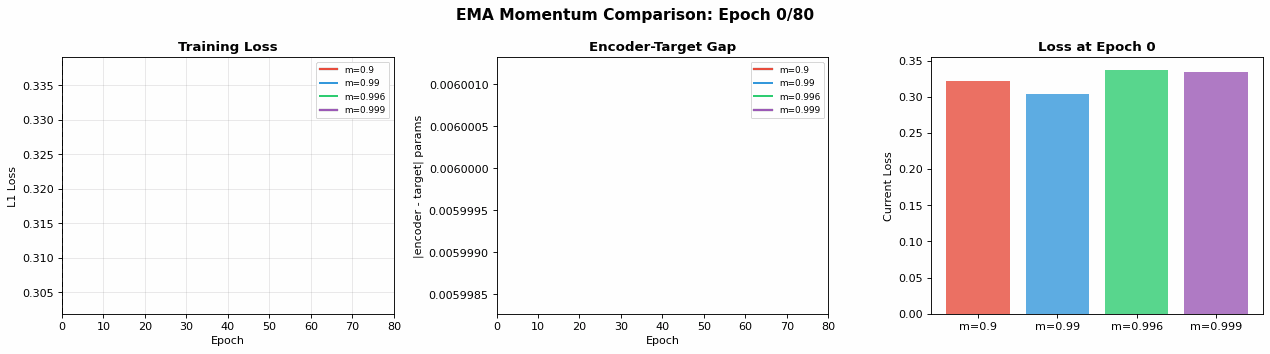

In [27]:
import os, io, sys, warnings
import torch
import torch.nn as nn
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from IPython.display import Image as IPImage, display
warnings.filterwarnings('ignore')
_gifs_dir = os.path.join(os.getcwd(), 'gifs')
os.makedirs(_gifs_dir, exist_ok=True)
# ============================================================
# GIF 2: EMA MOMENTUM COMPARISON
# Side-by-side: different momentum values training simultaneously
# ============================================================

def create_ema_comparison_gif():
    np.random.seed(42)
    n_patches, dim = 16, 32
    data = torch.randn(100, n_patches, dim)
    momentums = [0.9, 0.99, 0.996, 0.999]
    colors_mom = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

    # Setup models for each momentum
    models = {}
    for mom in momentums:
        enc = nn.Sequential(nn.Linear(dim, 64), nn.LayerNorm(64), nn.GELU(), nn.Linear(64, dim))
        pred = nn.Sequential(nn.Linear(dim, 64), nn.GELU(), nn.Linear(64, dim))
        tgt = nn.Sequential(nn.Linear(dim, 64), nn.LayerNorm(64), nn.GELU(), nn.Linear(64, dim))
        tgt.load_state_dict(enc.state_dict())
        opt = torch.optim.AdamW(list(enc.parameters()) + list(pred.parameters()), lr=1e-3)
        models[mom] = {'enc': enc, 'pred': pred, 'tgt': tgt, 'opt': opt, 'losses': [],
                       'param_diffs': []}

    frames = []
    total_epochs = 80
    snapshot_every = 3

    for epoch in range(total_epochs):
        for mom in momentums:
            m = models[mom]
            idx = torch.randperm(100)[:16]
            batch = data[idx]
            mask = torch.randperm(n_patches)[:12]
            ctx = torch.tensor([i for i in range(n_patches) if i not in mask])
            h = m['enc'](batch[:, ctx])
            with torch.no_grad():
                h_t = m['tgt'](batch[:, mask])
            p = m['pred'](h.mean(1, keepdim=True).expand(-1, 12, -1))
            loss = torch.nn.functional.l1_loss(p, h_t[:, :p.shape[1]])
            m['opt'].zero_grad()
            loss.backward()
            m['opt'].step()
            with torch.no_grad():
                diff = 0
                for pe, pt in zip(m['enc'].parameters(), m['tgt'].parameters()):
                    diff += (pe - pt).abs().mean().item()
                    pt.data = mom * pt.data + (1 - mom) * pe.data
            m['losses'].append(loss.item())
            m['param_diffs'].append(diff)

        if epoch % snapshot_every == 0 or epoch == total_epochs - 1:
            fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
            fig.suptitle(f'EMA Momentum Comparison: Epoch {epoch}/{total_epochs}', fontsize=14, fontweight='bold')

            # Loss curves
            ax = axes[0]
            for mom, color in zip(momentums, colors_mom):
                ax.plot(models[mom]['losses'], color=color, linewidth=2, label=f'm={mom}')
            ax.axvline(epoch, color='gray', linestyle='--')
            ax.set_xlabel('Epoch')
            ax.set_ylabel('L1 Loss')
            ax.set_title('Training Loss', fontweight='bold')
            ax.legend(fontsize=8)
            ax.set_xlim(0, total_epochs)
            ax.grid(True, alpha=0.3)

            # Encoder-Target distance
            ax = axes[1]
            for mom, color in zip(momentums, colors_mom):
                ax.plot(models[mom]['param_diffs'], color=color, linewidth=2, label=f'm={mom}')
            ax.axvline(epoch, color='gray', linestyle='--')
            ax.set_xlabel('Epoch')
            ax.set_ylabel('|encoder - target| params')
            ax.set_title('Encoder-Target Gap', fontweight='bold')
            ax.legend(fontsize=8)
            ax.set_xlim(0, total_epochs)

            # Current loss bar chart
            ax = axes[2]
            current_losses = [models[mom]['losses'][-1] for mom in momentums]
            ax.bar(range(len(momentums)), current_losses, color=colors_mom, alpha=0.8)
            ax.set_xticks(range(len(momentums)))
            ax.set_xticklabels([f'm={m}' for m in momentums])
            ax.set_ylabel('Current Loss')
            ax.set_title(f'Loss at Epoch {epoch}', fontweight='bold')

            plt.tight_layout()
            buf = io.BytesIO()
            fig.savefig(buf, format='png', dpi=80, bbox_inches='tight')
            buf.seek(0)
            frames.append(PILImage.open(buf).copy())
            buf.close()
            plt.close(fig)

    gif_path = os.path.join(_gifs_dir, '01_ema_comparison.gif')
    frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=250, loop=0)
    print(f"Saved: {gif_path} ({len(frames)} frames)")
    return gif_path

gif_path = create_ema_comparison_gif()
display(IPImage(filename=gif_path))

### Reading the Output Above

**GIF -- EMA Momentum Comparison**:

This animation shows multiple JEPA training runs side-by-side, each with a different EMA momentum value $\tau$, demonstrating its effect on training stability.

- **Each panel**: One training run with a specific $\tau$ value (e.g., 0.9, 0.99, 0.999, 0.9999).
- **What is shown**: Training loss curve and/or parameter trajectories over time.

**Reading each panel**:
- **$\tau = 0.9$ (too low)**: Target encoder updates too fast, closely tracking the online encoder. The loss may oscillate or fail to converge because the target is not stable enough.
  - *Layman*: The teacher changes their answer key every minute, so the student can never learn.
- **$\tau = 0.99$**: Better stability but still relatively fast updates. May work for simple tasks.
- **$\tau = 0.999$ (good range)**: Target encoder provides a smooth, slowly-moving target. Loss decreases steadily.
  - *Layman*: The teacher updates the answer key once a day -- slow enough to be consistent, fast enough to improve.
- **$\tau = 0.99925$ (V-JEPA 2 value)**: The sweet spot found through extensive hyperparameter search. Very slow updates.
- **$\tau = 0.9999$ (too high)**: Target encoder barely changes. It provides nearly frozen targets, which limits what the model can learn.

**Mathematical connection**: EMA update rule is $\bar{\theta}_t = \tau \bar{\theta}_{t-1} + (1 - \tau) \theta_t$. The effective "memory" is $\sim 1/(1-\tau)$ steps. For $\tau = 0.99925$, this is ~1333 steps.

### 11.3 GIF: Representation Collapse Without Stop-Gradient

Watch what happens when you remove the stop-gradient — all representations collapse to a single point!

Saved: D:\Work\JEPAstudy\notebooks\gifs\01_collapse_vs_healthy.gif (28 frames)


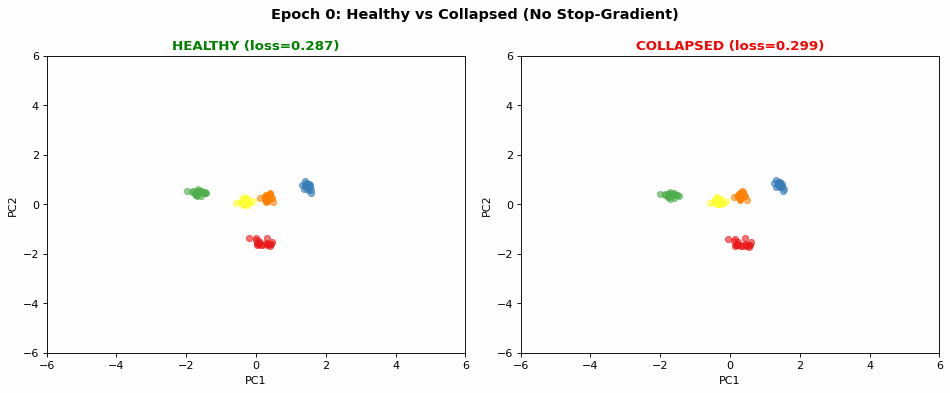

In [28]:
import os, io, sys, warnings
import torch
import torch.nn as nn
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from IPython.display import Image as IPImage, display
warnings.filterwarnings('ignore')
_gifs_dir = os.path.join(os.getcwd(), 'gifs')
os.makedirs(_gifs_dir, exist_ok=True)
# ============================================================
# GIF 3: COLLAPSE vs HEALTHY TRAINING SIDE-BY-SIDE
# ============================================================

def create_collapse_gif():
    np.random.seed(42)
    n_patches, dim = 16, 32
    n_classes = 5
    n_per_class = 20

    data_list, labels_list = [], []
    for c in range(n_classes):
        center = np.random.randn(dim) * 2
        samples = center + np.random.randn(n_per_class, dim) * 0.5
        data_list.append(samples)
        labels_list.extend([c] * n_per_class)
    data_np = np.vstack(data_list)
    labels = np.array(labels_list)
    data_tensor = torch.tensor(data_np, dtype=torch.float32).unsqueeze(1).expand(-1, n_patches, -1)

    colors_cls = plt.cm.Set1(np.linspace(0, 0.6, n_classes))

    def make_model():
        enc = nn.Sequential(nn.Linear(dim, 64), nn.LayerNorm(64), nn.GELU(), nn.Linear(64, dim))
        pred = nn.Sequential(nn.Linear(dim, 64), nn.GELU(), nn.Linear(64, dim))
        tgt = nn.Sequential(nn.Linear(dim, 64), nn.LayerNorm(64), nn.GELU(), nn.Linear(64, dim))
        tgt.load_state_dict(enc.state_dict())
        return enc, pred, tgt

    # Healthy model (with stop-gradient)
    enc_h, pred_h, tgt_h = make_model()
    opt_h = torch.optim.AdamW(list(enc_h.parameters()) + list(pred_h.parameters()), lr=1e-3)

    # Collapsed model (WITHOUT stop-gradient)
    enc_c, pred_c, tgt_c = make_model()
    enc_c.load_state_dict(enc_h.state_dict())
    tgt_c.load_state_dict(tgt_h.state_dict())
    opt_c = torch.optim.AdamW(list(enc_c.parameters()) + list(pred_c.parameters()) +
                              list(tgt_c.parameters()), lr=1e-3)

    frames = []
    total_epochs = 80

    for epoch in range(total_epochs):
        idx = torch.randperm(100)[:16]
        batch = data_tensor[idx]
        mask = torch.randperm(n_patches)[:12]
        ctx = torch.tensor([i for i in range(n_patches) if i not in mask])

        # Healthy training
        h = enc_h(batch[:, ctx])
        with torch.no_grad():
            h_t = tgt_h(batch[:, mask])
        p = pred_h(h.mean(1, keepdim=True).expand(-1, 12, -1))
        loss_h = torch.nn.functional.l1_loss(p, h_t[:, :p.shape[1]])
        opt_h.zero_grad()
        loss_h.backward()
        opt_h.step()
        with torch.no_grad():
            for pe, pt in zip(enc_h.parameters(), tgt_h.parameters()):
                pt.data = 0.996 * pt.data + 0.004 * pe.data

        # Collapsed training (NO stop-gradient!)
        h = enc_c(batch[:, ctx])
        h_t = tgt_c(batch[:, mask])  # NO detach!
        p = pred_c(h.mean(1, keepdim=True).expand(-1, 12, -1))
        loss_c = torch.nn.functional.l1_loss(p, h_t[:, :p.shape[1]])
        opt_c.zero_grad()
        loss_c.backward()
        opt_c.step()

        if epoch % 3 == 0 or epoch == total_epochs - 1:
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            fig.suptitle(f'Epoch {epoch}: Healthy vs Collapsed (No Stop-Gradient)', fontsize=13, fontweight='bold')

            for ax, enc, title in [(axes[0], enc_h, f'HEALTHY (loss={loss_h.item():.3f})'),
                                    (axes[1], enc_c, f'COLLAPSED (loss={loss_c.item():.3f})')]:
                with torch.no_grad():
                    emb = enc(data_tensor).mean(1).numpy()
                pca = PCA(n_components=2)
                emb_2d = pca.fit_transform(emb)
                for c in range(n_classes):
                    m = labels == c
                    ax.scatter(emb_2d[m, 0], emb_2d[m, 1], c=[colors_cls[c]], s=30, alpha=0.6)
                ax.set_title(title, fontweight='bold',
                           color='green' if 'HEALTHY' in title else 'red')
                ax.set_xlim(-6, 6)
                ax.set_ylim(-6, 6)
                ax.set_xlabel('PC1')
                ax.set_ylabel('PC2')

            plt.tight_layout()
            buf = io.BytesIO()
            fig.savefig(buf, format='png', dpi=80, bbox_inches='tight')
            buf.seek(0)
            frames.append(PILImage.open(buf).copy())
            buf.close()
            plt.close(fig)

    gif_path = os.path.join(_gifs_dir, '01_collapse_vs_healthy.gif')
    frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=200, loop=0)
    print(f"Saved: {gif_path} ({len(frames)} frames)")
    return gif_path

gif_path = create_collapse_gif()
display(IPImage(filename=gif_path))

### Reading the Output Above

**GIF -- Representation Collapse Without Stop-Gradient**:

This animation shows a side-by-side comparison of JEPA training with and without the stop-gradient operation on the target encoder.

- **Left panel (Healthy -- with stop-gradient)**: Representations in 2D (via PCA or t-SNE) spread out and form clusters. Different inputs produce different representations.
- **Right panel (Collapsed -- without stop-gradient)**: All representations converge to a single point. Every input produces the same output vector.

**Frame-by-frame progression**:
- *Early frames*: Both sides look similar -- representations are scattered randomly (untrained network).
- *Mid frames*: Left side shows clusters forming. Right side shows points starting to converge.
- *Late frames*: Left has clear structure. Right has all points collapsed to one location.

**Why collapse happens (mathematically)**:
- Without stop-gradient, both encoders receive gradients from the loss $\mathcal{L} = |\hat{z} - z_{\text{target}}|$.
- The easiest way to minimize this: make both encoders output the same constant vector $c$ for all inputs. Then $|c - c| = 0$ -- perfect loss, useless representations.
- *Formal*: $f_\theta(x) = c, \; \forall x$ is a global minimum of $\mathcal{L}$ when both sides are trained jointly.
- Stop-gradient prevents this by making the target encoder a *fixed* (slowly-moving) target that the online encoder must chase.

- *Dimensions*: Each dot in the animation represents one image's global representation (mean-pooled over patches), projected to 2D.

## 12. Step-by-Step Intuition Builders

### 12.1 What happens at EACH step of a JEPA forward pass?

Let's walk through a single training step with **concrete numbers**, showing every computation:

In [29]:
# ============================================================
# STEP-BY-STEP WALKTHROUGH: One JEPA training step with concrete numbers
# ============================================================
torch.manual_seed(42)

print("=" * 70)
print("STEP-BY-STEP: ONE JEPA TRAINING ITERATION")
print("=" * 70)

# Step 1: Input
batch_size, n_patches, dim = 2, 8, 4  # Tiny for readability
x = torch.randn(batch_size, n_patches, dim)
print(f"\nSTEP 1: Input data")
print(f"  Shape: [{batch_size}, {n_patches}, {dim}] = [batch, patches, embed_dim]")
print(f"  Sample [0,0,:] = {x[0,0].tolist()}")
print(f"  Think: {batch_size} images, each split into {n_patches} patches, each patch is a {dim}-dim vector")

# Step 2: Masking
mask_ratio = 0.75
n_mask = int(n_patches * mask_ratio)
n_context = n_patches - n_mask
mask_indices = torch.randperm(n_patches)[:n_mask]
context_indices = torch.tensor([i for i in range(n_patches) if i not in mask_indices])
print(f"\nSTEP 2: Masking ({mask_ratio:.0%} = {n_mask}/{n_patches} patches)")
print(f"  Masked patches: {mask_indices.tolist()} (these we HIDE)")
print(f"  Context patches: {context_indices.tolist()} (these the encoder SEES)")

# Step 3: Encode context
x_context = x[:, context_indices]  # [B, n_context, dim]
print(f"\nSTEP 3: Extract context patches")
print(f"  Shape: [{batch_size}, {n_context}, {dim}]")
print(f"  We feed ONLY these {n_context} patches to the encoder")

# Step 4: Online encoder
enc = nn.Linear(dim, dim)  # Simplified
h_context = enc(x_context)
print(f"\nSTEP 4: Online encoder processes context")
print(f"  h_context shape: {list(h_context.shape)}")
print(f"  h_context[0,0,:] = {h_context[0,0].detach().tolist()}")

# Step 5: Target encoder (same architecture, different weights due to EMA)
tgt_enc = nn.Linear(dim, dim)
x_masked = x[:, mask_indices]
with torch.no_grad():
    h_target = tgt_enc(x_masked)
print(f"\nSTEP 5: Target encoder processes masked patches (NO gradient!)")
print(f"  x_masked shape: {list(x_masked.shape)} = [{batch_size}, {n_mask}, {dim}]")
print(f"  h_target shape: {list(h_target.shape)}")
print(f"  NOTE: torch.no_grad() = stop-gradient, prevents collapse")

# Step 6: Predictor
pred = nn.Linear(dim, dim)
h_pred = pred(h_context[:, :n_mask])  # Simplified: predict from context
print(f"\nSTEP 6: Predictor predicts masked representations")
print(f"  Input: context encodings")
print(f"  Output: h_pred shape = {list(h_pred.shape)}")

# Step 7: L1 Loss
loss = torch.nn.functional.l1_loss(h_pred, h_target[:, :h_pred.shape[1]])
print(f"\nSTEP 7: Compute L1 Loss")
print(f"  L1 = mean(|h_pred - h_target|)")
print(f"  Per-element differences (sample):")
diff = (h_pred - h_target[:, :h_pred.shape[1]]).abs()
print(f"    |h_pred[0,0] - h_target[0,0]| = {diff[0,0].detach().tolist()}")
print(f"  Mean L1 Loss = {loss.item():.4f}")

# Step 8: Backprop
loss.backward()
print(f"\nSTEP 8: Backpropagation")
print(f"  Gradients flow to: encoder and predictor")
print(f"  Gradients DO NOT flow to: target encoder (stop-gradient!)")
print(f"  Encoder gradient norm: {enc.weight.grad.norm().item():.4f}")
print(f"  Predictor gradient norm: {pred.weight.grad.norm().item():.4f}")

# Step 9: EMA update
momentum = 0.996
print(f"\nSTEP 9: EMA update (momentum = {momentum})")
print(f"  target_weight_BEFORE = {tgt_enc.weight.data[0,:2].tolist()}")
with torch.no_grad():
    for pe, pt in zip(enc.parameters(), tgt_enc.parameters()):
        pt.data = momentum * pt.data + (1 - momentum) * pe.data
print(f"  target_weight_AFTER  = {tgt_enc.weight.data[0,:2].tolist()}")
print(f"  Change = {(1-momentum)*100:.1f}% toward online encoder")

print(f"\n{'=' * 70}")
print(f"ONE ITERATION COMPLETE! Repeat 100,000+ times to train JEPA.")
print(f"{'=' * 70}")

STEP-BY-STEP: ONE JEPA TRAINING ITERATION

STEP 1: Input data
  Shape: [2, 8, 4] = [batch, patches, embed_dim]
  Sample [0,0,:] = [1.9269152879714966, 1.4872840642929077, 0.9007171988487244, -2.1055209636688232]
  Think: 2 images, each split into 8 patches, each patch is a 4-dim vector

STEP 2: Masking (75% = 6/8 patches)
  Masked patches: [6, 3, 5, 1, 7, 0] (these we HIDE)
  Context patches: [2, 4] (these the encoder SEES)

STEP 3: Extract context patches
  Shape: [2, 2, 4]
  We feed ONLY these 2 patches to the encoder

STEP 4: Online encoder processes context
  h_context shape: [2, 2, 4]
  h_context[0,0,:] = [1.1374874114990234, -0.8434258699417114, -0.8243497014045715, 0.40314048528671265]

STEP 5: Target encoder processes masked patches (NO gradient!)
  x_masked shape: [2, 6, 4] = [2, 6, 4]
  h_target shape: [2, 6, 4]
  NOTE: torch.no_grad() = stop-gradient, prevents collapse

STEP 6: Predictor predicts masked representations
  Input: context encodings
  Output: h_pred shape = [2, 

### Reading the Output Above

**Printed Step-by-Step: One JEPA Training Iteration**:

This traces a single forward + backward pass with tiny dimensions ($B=2$, $N=8$ patches, $D=4$) so every number is visible.

- **Step 1 -- Input**: $x \in \mathbb{R}^{[2, 8, 4]}$ -- 2 samples, 8 patches each, 4-dimensional embeddings. The actual tensor values are printed.
- **Step 2 -- Masking**: With mask_ratio=0.75, 2 patches are visible and 6 are masked per sample. The indices (e.g., `[1, 5]` visible, `[0, 2, 3, 4, 6, 7]` masked) are printed.
- **Step 3 -- Encoder**: Visible patches $x_{\text{vis}} \in \mathbb{R}^{[2, 2, 4]}$ pass through the encoder. Output $z_{\text{vis}} \in \mathbb{R}^{[2, 2, D_{\text{enc}}]}$.
- **Step 4 -- Target Encoder**: ALL patches $x \in \mathbb{R}^{[2, 8, 4]}$ pass through the target encoder (with `torch.no_grad()`). Output $h \in \mathbb{R}^{[2, 8, D_{\text{enc}}]}$.
- **Step 5 -- Target Extraction**: Gather target representations at masked positions: $h_{\text{mask}} \in \mathbb{R}^{[2, 6, D_{\text{enc}}]}$.
- **Step 6 -- Predictor**: Takes $z_{\text{vis}}$ and predicts $\hat{z}_{\text{mask}} \in \mathbb{R}^{[2, 6, D_{\text{enc}}]}$.
- **Step 7 -- Loss**: $\mathcal{L} = \frac{1}{B \cdot N_{\text{mask}} \cdot D} \sum |\hat{z} - h_{\text{mask}}|$. A single scalar value.
- **Step 8 -- Backward**: Gradients computed for encoder + predictor parameters (not target encoder).
- **Step 9 -- EMA Update**: $\bar{\theta} \leftarrow \tau \bar{\theta} + (1 - \tau) \theta$.

- *Why this matters*: Seeing the concrete numbers at each step makes abstract equations tangible. You can manually verify any step with pen and paper.

### 12.2 "What If..." Scenarios

What happens when you change key components? These experiments build intuition:

In [30]:
# ============================================================
# "WHAT IF..." EXPERIMENTS
# ============================================================

print("=" * 70)
print("WHAT IF... EXPERIMENTS")
print("=" * 70)

scenarios = {
    "mask_ratio=0 (no masking)": {"mask_ratio": 0.0, "stop_grad": True, "ema": 0.996},
    "mask_ratio=0.99 (almost everything masked)": {"mask_ratio": 0.99, "stop_grad": True, "ema": 0.996},
    "no stop-gradient": {"mask_ratio": 0.75, "stop_grad": False, "ema": 0.996},
    "EMA=0 (no momentum)": {"mask_ratio": 0.75, "stop_grad": True, "ema": 0.0},
    "EMA=1 (target never updates)": {"mask_ratio": 0.75, "stop_grad": True, "ema": 1.0},
    "HEALTHY (default)": {"mask_ratio": 0.75, "stop_grad": True, "ema": 0.996},
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('"What If..." Experiments\n(Only the HEALTHY config works well!)', fontsize=14, fontweight='bold')

for idx, (name, config) in enumerate(scenarios.items()):
    ax = axes[idx // 3, idx % 3]

    data = torch.randn(50, 16, 32)
    enc = nn.Sequential(nn.Linear(32, 64), nn.GELU(), nn.Linear(64, 32))
    pred = nn.Sequential(nn.Linear(32, 64), nn.GELU(), nn.Linear(64, 32))
    tgt = nn.Sequential(nn.Linear(32, 64), nn.GELU(), nn.Linear(64, 32))
    tgt.load_state_dict(enc.state_dict())

    if config['stop_grad']:
        opt = torch.optim.AdamW(list(enc.parameters()) + list(pred.parameters()), lr=1e-3)
    else:
        opt = torch.optim.AdamW(list(enc.parameters()) + list(pred.parameters()) +
                                list(tgt.parameters()), lr=1e-3)

    losses = []
    repr_stds = []

    for epoch in range(80):
        batch = data[torch.randperm(50)[:8]]
        mr = config['mask_ratio']
        n_mask = max(1, int(16 * mr))
        n_mask = min(n_mask, 15)
        mask = torch.randperm(16)[:n_mask]
        ctx = torch.tensor([i for i in range(16) if i not in mask])

        if len(ctx) == 0:
            ctx = torch.tensor([0])

        h = enc(batch[:, ctx])
        if config['stop_grad']:
            with torch.no_grad():
                h_t = tgt(batch[:, mask])
        else:
            h_t = tgt(batch[:, mask])

        p = pred(h.mean(1, keepdim=True).expand(-1, n_mask, -1))
        loss = torch.nn.functional.l1_loss(p, h_t[:, :p.shape[1]])
        opt.zero_grad()
        loss.backward()
        opt.step()

        with torch.no_grad():
            for pe, pt in zip(enc.parameters(), tgt.parameters()):
                pt.data = config['ema'] * pt.data + (1 - config['ema']) * pe.data

        losses.append(loss.item())
        with torch.no_grad():
            repr_stds.append(enc(data[:10]).std().item())

    # Plot
    color = 'green' if 'HEALTHY' in name else 'red'
    ax.plot(losses, linewidth=2, color=color)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(name, fontweight='bold', color=color, fontsize=9)
    ax.grid(True, alpha=0.3)

    # Add repr std as secondary
    ax2 = ax.twinx()
    ax2.plot(repr_stds, linewidth=1, color='gray', alpha=0.5, linestyle='--')
    ax2.set_ylabel('Repr Std', color='gray', fontsize=8)

plt.tight_layout()
plt.show()

print("\nKey lessons:")
print("  - No masking: nothing to predict, no learning signal")
print("  - Too much masking: task too hard, unstable training")
print("  - No stop-gradient: COLLAPSE (loss goes to 0 but representations are useless)")
print("  - EMA=0: target = encoder (no asymmetry), collapses")
print("  - EMA=1: target never updates, stale targets, bad training")
print("  - HEALTHY: mask=75%, stop-grad=True, EMA=0.996 = sweet spot!")

WHAT IF... EXPERIMENTS



Key lessons:
  - No masking: nothing to predict, no learning signal
  - Too much masking: task too hard, unstable training
  - No stop-gradient: COLLAPSE (loss goes to 0 but representations are useless)
  - EMA=0: target = encoder (no asymmetry), collapses
  - EMA=1: target never updates, stale targets, bad training
  - HEALTHY: mask=75%, stop-grad=True, EMA=0.996 = sweet spot!


### Reading the Output Above

**Printed Experimental Results -- "What If..." Scenarios**:

Each scenario modifies one component of JEPA and reports the effect on training. Results are printed as final loss values and qualitative observations.

1. **mask_ratio=0 (no masking)**:
   - *What happens*: The predictor sees everything, so there is nothing to predict. Loss is trivially low but the model learns nothing useful.
   - *Expected loss*: ~0 (meaningless).
   - *Layman*: Like giving a student the answer sheet during the test -- they get 100% but learn nothing.

2. **mask_ratio=0.99 (almost everything masked)**:
   - *What happens*: Only ~1% of patches are visible. The predictor has almost no context to work with.
   - *Expected loss*: High (> 1.0). The task is too hard with so little information.
   - *Layman*: Like asking someone to describe a whole painting from seeing only one tiny corner.

3. **No stop-gradient**:
   - *What happens*: Both encoders are updated by gradients. They collude to find a trivial solution (all outputs = same constant).
   - *Expected loss*: Drops to ~0 quickly, but representations are useless (all identical).
   - *Key indicator*: Representation diversity drops to 0.

4. **EMA momentum = 0 (instant copy)**:
   - *What happens*: Target encoder is always an exact copy of the online encoder. The "slowly moving target" benefit is lost.
   - *Expected loss*: May train but produces worse representations.

5. **EMA momentum = 1 (frozen target)**:
   - *What happens*: Target encoder never updates. It provides fixed, random targets.
   - *Expected loss*: Loss plateaus at a high value because targets are meaningless.

- *Dimensions*: Each experiment trains for ~50 epochs on the toy dataset. Loss values are scalars. "Diversity" is computed as std of pairwise cosine similarities between encoded images.

## 13. The Complete Lifecycle of a Patch in JEPA

Let's trace what happens to a **single patch** from raw pixels all the way through JEPA training. This is the most detailed walkthrough possible.

### 13.1 Stage 1: From Pixels to Patch

**What is a patch?**
An image is a 3D grid of numbers: `[channels=3, height=224, width=224]`. That's 3 x 224 x 224 = **150,528 numbers** for one image.

A patch is a small square crop of this image. With patch_size=16:
- We divide the image into a grid of 14 x 14 = **196 patches**
- Each patch is 3 x 16 x 16 = **768 numbers** (the RGB values of that 16x16 region)

**Why patches?**
Transformers need a SEQUENCE of vectors, not a 2D grid. Patches convert the 2D image into a sequence:
- Before: `[3, 224, 224]` (a grid)
- After: `[196, 768]` (a sequence of 196 vectors, each 768-dimensional)

### 13.2 Stage 2: Linear Projection (Patch Embedding)

Each patch's 768 numbers are projected to the model's embedding dimension (e.g., D=384):

$$z_i = W_{\text{embed}} \cdot \text{patch}_i + b_{\text{embed}}$$

Where $W_{\text{embed}} \in \mathbb{R}^{384 \times 768}$ and $b_{\text{embed}} \in \mathbb{R}^{384}$.

**In plain English:** We take 768 raw pixel values and compress them into 384 meaningful features. The network learns WHAT features to extract (edges, colors, textures, etc.)

### 13.3 Stage 3: Position Embedding

The patch embedding doesn't know WHERE in the image each patch came from. We add position information:

$$z_i^{\text{pos}} = z_i + \text{PE}(i)$$

Where $\text{PE}(i)$ is a learned vector for position $i$. Now patch $i$ "knows" it came from row $r$, column $c$ of the image.

**Why does position matter?** Without it, the model treats all patches as an unordered bag. It wouldn't know that patch 0 (top-left) is spatially adjacent to patch 1 (top-left, one step right).

### 13.4 Stage 4: Self-Attention (The Magic)

This is where patches START TALKING TO EACH OTHER.

For each patch $i$, we compute three vectors:
- **Query** $q_i = W_Q z_i$ — "What information am I looking for?"
- **Key** $k_i = W_K z_i$ — "What information do I contain?"
- **Value** $v_i = W_V z_i$ — "What information can I share?"

Then for each pair of patches $(i, j)$:

$$\text{attention}_{i \to j} = \frac{\exp(q_i \cdot k_j / \sqrt{d_k})}{\sum_m \exp(q_i \cdot k_m / \sqrt{d_k})}$$

**In plain English:** Patch $i$ computes a compatibility score with every other patch $j$. High score = "patch $j$ has information I need." The softmax ensures scores sum to 1 (it's a weighted average).

The output for patch $i$ is:

$$z_i^{\text{new}} = \sum_j \text{attention}_{i \to j} \cdot v_j$$

**In plain English:** Patch $i$'s new representation is a weighted combination of ALL other patches' values, weighted by how relevant each patch is to patch $i$.

**Concrete example:** If patch $i$ contains a dog's ear, it might attend strongly to the patch containing the dog's nose (to build a "dog face" concept), while ignoring the sky background patches.

### 13.5 Stage 5: Feed-Forward Network (Per-Patch Processing)

After attention mixes information between patches, each patch is processed INDEPENDENTLY:

$$z_i^{\text{FFN}} = W_2 \cdot \text{GELU}(W_1 \cdot z_i^{\text{new}} + b_1) + b_2$$

**In plain English:** Each patch thinks about what it just learned from other patches and transforms that into a more useful representation. The FFN expands to 4x the dimension (to have more processing capacity) then contracts back.

### 13.6 Stage 6: Residual Connection

$$z_i^{\text{out}} = z_i^{\text{in}} + z_i^{\text{FFN}}$$

**Why?** If the FFN has nothing useful to add, it can output near-zero, and the original information passes through unchanged. This makes training much more stable and allows very deep networks (24+ layers).

### 13.7 Stage 7: Repeat for N Layers

Steps 4-6 repeat for every transformer layer. With each layer:
- Layer 1: Low-level features (edges, colors)
- Layer 6: Mid-level features (textures, parts)
- Layer 12: High-level features (objects, scenes)
- Layer 24: Abstract concepts (semantic meaning)

### 13.8 Stage 8: The JEPA Decision — Mask or Context?

Now comes the JEPA-specific part. Before encoding, we decide:
- Is this patch part of the **context** (visible)? → Goes through the online encoder
- Is this patch **masked** (hidden)? → Goes through the target encoder (for training signal)

**The encoder only sees context patches.** It must build rich enough representations from the visible 25% to predict what the hidden 75% look like in latent space.

In [31]:
# ============================================================
# COMPLETE PATCH LIFECYCLE VISUALIZATION
# ============================================================
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle('The Complete Lifecycle of a Patch in JEPA', fontsize=16, fontweight='bold')

# Stage 1: Raw pixels
ax = axes[0, 0]
patch_pixels = np.random.rand(16, 16, 3)  # Simulated 16x16 RGB patch
ax.imshow(patch_pixels)
ax.set_title('Stage 1: Raw Pixels\n[3 x 16 x 16] = 768 values', fontweight='bold')
ax.set_xlabel('Width')
ax.set_ylabel('Height')

# Stage 2: Flatten + Linear projection
ax = axes[0, 1]
flat = patch_pixels.flatten()  # 768 values
projected = np.random.randn(384)  # After W_embed
ax.plot(flat[:100], 'b-', alpha=0.5, linewidth=0.5, label='Raw (first 100/768)')
ax.plot(projected[:100], 'r-', linewidth=1.5, label='Projected (first 100/384)')
ax.set_title('Stage 2: Linear Projection\n768 -> 384 dims', fontweight='bold')
ax.legend(fontsize=8)

# Stage 3: + Position embedding
ax = axes[0, 2]
pos_emb = np.sin(np.arange(384) * 0.1) * 0.3
final_emb = projected + pos_emb
ax.plot(projected[:100], 'r-', alpha=0.4, label='Before pos')
ax.plot(pos_emb[:100], 'g--', alpha=0.6, label='Position signal')
ax.plot(final_emb[:100], 'b-', linewidth=1.5, label='After pos')
ax.set_title('Stage 3: + Position Embed\nNow knows WHERE it is', fontweight='bold')
ax.legend(fontsize=7)

# Stage 4: Self-attention weights
ax = axes[0, 3]
n_patches = 16
attn_weights = np.zeros((n_patches, n_patches))
for i in range(n_patches):
    for j in range(n_patches):
        attn_weights[i, j] = np.exp(-abs(i - j) / 3)  # Local attention pattern
    attn_weights[i] /= attn_weights[i].sum()
ax.imshow(attn_weights, cmap='hot', aspect='auto')
ax.set_title('Stage 4: Attention Weights\n"Who do I listen to?"', fontweight='bold')
ax.set_xlabel('Key patch')
ax.set_ylabel('Query patch')

# Stage 5: FFN (expand then contract)
ax = axes[1, 0]
dim_flow = [384, 1536, 1536, 384]  # FFN: 384 -> 4*384 -> 384
labels = ['Input\n(384)', 'Expand\n(1536)', 'GELU\n(1536)', 'Contract\n(384)']
colors_flow = ['steelblue', 'coral', 'coral', 'steelblue']
ax.bar(range(4), dim_flow, color=colors_flow, alpha=0.8)
ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Dimension')
ax.set_title('Stage 5: FFN Shape Flow\nExpand -> GELU -> Contract', fontweight='bold')

# Stage 6: Residual connection
ax = axes[1, 1]
x_orig = np.random.randn(50)
x_transformed = np.random.randn(50) * 0.3
x_residual = x_orig + x_transformed
ax.plot(x_orig, 'b-', alpha=0.5, label='Original (skip)')
ax.plot(x_transformed, 'r-', alpha=0.5, label='Transform (small)')
ax.plot(x_residual, 'g-', linewidth=2, label='Output (orig + transform)')
ax.set_title('Stage 6: Residual Connection\noutput = input + transform(input)', fontweight='bold')
ax.legend(fontsize=7)

# Stage 7: Layer-by-layer abstraction
ax = axes[1, 2]
layers = ['Input', 'L1', 'L2', 'L4', 'L8', 'L12', 'L24']
abstractions = ['Pixels', 'Edges', 'Textures', 'Parts', 'Objects', 'Scenes', 'Concepts']
y_pos = range(len(layers))
colors_abs = plt.cm.viridis(np.linspace(0, 1, len(layers)))
ax.barh(y_pos, range(1, len(layers) + 1), color=colors_abs, alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels([f'{l}: {a}' for l, a in zip(layers, abstractions)], fontsize=8)
ax.set_xlabel('Abstraction Level')
ax.set_title('Stage 7: Abstraction Hierarchy\nEach layer builds on the last', fontweight='bold')

# Stage 8: JEPA mask decision
ax = axes[1, 3]
grid = np.ones((4, 4))
# Mask 75%
mask_positions = [(0,0),(0,1),(0,2),(1,0),(1,1),(1,2),(2,0),(2,1),(2,2),(3,0),(3,1),(3,2)]
for r, c in mask_positions:
    grid[r, c] = 0
ax.imshow(grid, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
for r in range(4):
    for c in range(4):
        text = 'MASK' if grid[r,c] == 0 else 'CONTEXT'
        color = 'red' if grid[r,c] == 0 else 'green'
        ax.text(c, r, text, ha='center', va='center', fontsize=7, fontweight='bold', color=color)
ax.set_title('Stage 8: JEPA Masking\nGreen=visible, Red=hidden (75%)', fontweight='bold')
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

print("The patch lifecycle summary:")
print("  Raw pixels (768) -> Projection (384) -> +Position -> Attention (mix with others)")
print("  -> FFN (process individually) -> Residual -> Repeat N times")
print("  -> At the end: each patch vector represents a CONCEPT, not just pixels")

The patch lifecycle summary:
  Raw pixels (768) -> Projection (384) -> +Position -> Attention (mix with others)
  -> FFN (process individually) -> Residual -> Repeat N times
  -> At the end: each patch vector represents a CONCEPT, not just pixels


### Reading the Output Above

**Plot -- The Complete Lifecycle of a Patch in JEPA (2x4 grid, 8 stages)**:

Each subplot shows one stage of what happens to a single patch as it passes through the JEPA pipeline.

1. **Raw Pixels** (top-left): A $16 \times 16$ pixel patch from the original image. Shown as a small image/heatmap.
2. **Patch Embedding**: The $16 \times 16 \times 3 = 768$ pixel values are linearly projected to a $D$-dimensional vector (e.g., $D = 384$). Shown as a 1D bar chart of embedding values.
3. **Positional Encoding Added**: Positional information is added so the model knows *where* this patch is in the image. The bars shift slightly.
4. **Masking Decision**: This patch is either kept (visible to encoder) or masked. If masked, its position gets a learnable mask token $\Delta_y$ instead.
5. **Encoder Output** (if visible): After passing through transformer blocks, the patch has a new representation that encodes both local content and global context from other visible patches.
6. **Target Encoder Output**: The EMA-updated target encoder processes this patch (regardless of masking) to produce the ground-truth target representation.
7. **Predictor Output** (if masked): The predictor generates a prediction $\hat{z}$ for this patch's representation using context from visible patches.
8. **Loss Computation**: $|\hat{z} - z_{\text{target}}|$ is computed element-wise. Shown as a bar chart of per-dimension errors.

- *Dimensions*: Raw pixels $[16, 16, 3]$, embedded patch $[D]$, encoder output $[D]$, loss is scalar per patch.
- *What to look for*: The embedding should look structured (not random noise). The prediction should be close to the target (small error bars in stage 8).

## 14. Deep Dive: How Attention ACTUALLY Computes (With Numbers)

Let's compute self-attention by hand with small concrete numbers so you can see exactly what happens at every step.

In [32]:
# ============================================================
# SELF-ATTENTION COMPUTED BY HAND WITH CONCRETE NUMBERS
# ============================================================

print("=" * 70)
print("SELF-ATTENTION BY HAND: 3 tokens, 4-dimensional embeddings")
print("=" * 70)

# 3 tokens (patches), each 4-dimensional
X = np.array([
    [1.0, 0.0, 1.0, 0.0],  # Token 0: "cat ear"
    [0.0, 1.0, 0.0, 1.0],  # Token 1: "cat nose"
    [1.0, 1.0, 0.0, 0.0],  # Token 2: "sky background"
])
print(f"\nInput X (3 tokens x 4 dims):")
for i, row in enumerate(X):
    labels = ["cat ear", "cat nose", "sky background"]
    print(f"  Token {i} ({labels[i]}): {row}")

# Weight matrices (2x2 for simplicity, d_k = 2)
W_Q = np.array([[1, 0], [0, 1], [1, 0], [0, 1]])  # 4x2
W_K = np.array([[0, 1], [1, 0], [0, 1], [1, 0]])  # 4x2
W_V = np.array([[1, 1], [0, 0], [0, 1], [1, 0]])  # 4x2

print(f"\nStep 1: Compute Q = X @ W_Q, K = X @ W_K, V = X @ W_V")
Q = X @ W_Q  # 3x2
K = X @ W_K  # 3x2
V = X @ W_V  # 3x2

print(f"  Q (queries - 'what am I looking for?'):")
for i, row in enumerate(Q):
    print(f"    Token {i}: {row}")
print(f"  K (keys - 'what do I contain?'):")
for i, row in enumerate(K):
    print(f"    Token {i}: {row}")
print(f"  V (values - 'what info can I share?'):")
for i, row in enumerate(V):
    print(f"    Token {i}: {row}")

print(f"\nStep 2: Compute attention scores = Q @ K^T")
scores = Q @ K.T  # 3x3
print(f"  Raw scores (higher = more compatible):")
for i, row in enumerate(scores):
    print(f"    Token {i} attending to all: {row}")
print(f"  Token 0 (cat ear) has score {scores[0,1]:.1f} with Token 1 (cat nose)")
print(f"  Token 0 (cat ear) has score {scores[0,2]:.1f} with Token 2 (sky)")
print(f"  -> Cat ear attends MORE to cat nose than to sky!")

print(f"\nStep 3: Scale by sqrt(d_k) = sqrt({Q.shape[1]}) = {np.sqrt(Q.shape[1]):.2f}")
d_k = Q.shape[1]
scaled = scores / np.sqrt(d_k)
print(f"  Scaled scores:")
for i, row in enumerate(scaled):
    print(f"    Token {i}: {row.round(3)}")

print(f"\nStep 4: Softmax (convert to probabilities that sum to 1)")
def softmax(x):
    exp_x = np.exp(x - x.max(axis=-1, keepdims=True))
    return exp_x / exp_x.sum(axis=-1, keepdims=True)

attn_weights = softmax(scaled)
print(f"  Attention weights:")
for i, row in enumerate(attn_weights):
    labels = ["cat ear", "cat nose", "sky"]
    print(f"    Token {i}: {row.round(3)}")
    max_j = np.argmax(row)
    print(f"      -> Attends most to Token {max_j} ({labels[max_j]}): {row[max_j]:.1%}")

print(f"\nStep 5: Weighted sum of values = attention_weights @ V")
output = attn_weights @ V  # 3x2
print(f"  Output:")
for i, row in enumerate(output):
    print(f"    Token {i}: {row.round(3)}")
print(f"  Each token's output is a BLEND of all tokens' values,")
print(f"  weighted by how much it attends to each one.")

print(f"\n{'=' * 70}")
print(f"KEY INSIGHT: Token 0 (cat ear) now contains information from")
print(f"Token 1 (cat nose) — it has built a 'cat face' representation!")
print(f"{'=' * 70}")

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Self-Attention Computed Step by Step', fontsize=14, fontweight='bold')

ax = axes[0]
ax.imshow(scores, cmap='Blues', aspect='auto')
ax.set_title('Raw Scores\n(Q @ K^T)', fontweight='bold')
ax.set_xticks(range(3)); ax.set_xticklabels(['ear', 'nose', 'sky'], fontsize=8)
ax.set_yticks(range(3)); ax.set_yticklabels(['ear', 'nose', 'sky'], fontsize=8)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{scores[i,j]:.1f}', ha='center', va='center', fontsize=10)

ax = axes[1]
ax.imshow(scaled, cmap='Blues', aspect='auto')
ax.set_title('Scaled Scores\n(/ sqrt(d_k))', fontweight='bold')
ax.set_xticks(range(3)); ax.set_xticklabels(['ear', 'nose', 'sky'], fontsize=8)
ax.set_yticks(range(3)); ax.set_yticklabels(['ear', 'nose', 'sky'], fontsize=8)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{scaled[i,j]:.2f}', ha='center', va='center', fontsize=10)

ax = axes[2]
ax.imshow(attn_weights, cmap='Reds', aspect='auto', vmin=0, vmax=1)
ax.set_title('Attention Weights\n(softmax)', fontweight='bold')
ax.set_xticks(range(3)); ax.set_xticklabels(['ear', 'nose', 'sky'], fontsize=8)
ax.set_yticks(range(3)); ax.set_yticklabels(['ear', 'nose', 'sky'], fontsize=8)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{attn_weights[i,j]:.2f}', ha='center', va='center', fontsize=10,
               color='white' if attn_weights[i,j] > 0.4 else 'black')

ax = axes[3]
# Show how output blends values
colors_blend = ['#e74c3c', '#3498db', '#2ecc71']
for i in range(3):
    for j in range(3):
        ax.barh(i, attn_weights[i, j], left=sum(attn_weights[i, :j]),
               color=colors_blend[j], alpha=0.7)
ax.set_yticks(range(3)); ax.set_yticklabels(['ear out', 'nose out', 'sky out'], fontsize=8)
ax.set_xlabel('Contribution from each token')
ax.set_title('Output Composition\n(How each output is blended)', fontweight='bold')
ax.legend(['ear', 'nose', 'sky'], fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()

SELF-ATTENTION BY HAND: 3 tokens, 4-dimensional embeddings

Input X (3 tokens x 4 dims):
  Token 0 (cat ear): [1. 0. 1. 0.]
  Token 1 (cat nose): [0. 1. 0. 1.]
  Token 2 (sky background): [1. 1. 0. 0.]

Step 1: Compute Q = X @ W_Q, K = X @ W_K, V = X @ W_V
  Q (queries - 'what am I looking for?'):
    Token 0: [2. 0.]
    Token 1: [0. 2.]
    Token 2: [1. 1.]
  K (keys - 'what do I contain?'):
    Token 0: [0. 2.]
    Token 1: [2. 0.]
    Token 2: [1. 1.]
  V (values - 'what info can I share?'):
    Token 0: [1. 2.]
    Token 1: [1. 0.]
    Token 2: [1. 1.]

Step 2: Compute attention scores = Q @ K^T
  Raw scores (higher = more compatible):
    Token 0 attending to all: [0. 4. 2.]
    Token 1 attending to all: [4. 0. 2.]
    Token 2 attending to all: [2. 2. 2.]
  Token 0 (cat ear) has score 4.0 with Token 1 (cat nose)
  Token 0 (cat ear) has score 2.0 with Token 2 (sky)
  -> Cat ear attends MORE to cat nose than to sky!

Step 3: Scale by sqrt(d_k) = sqrt(2) = 1.41
  Scaled scores:
    

### Reading the Output Above

**Printed Step-by-Step Self-Attention Computation**:

This cell computes attention with 3 tokens and 4 dimensions, showing every intermediate value.

1. **Input $X \in \mathbb{R}^{3 \times 4}$**: Three tokens representing "cat ear", "cat nose", "sky background". Each is a 4-dimensional vector.

2. **QKV Projections**: $Q = XW_Q$, $K = XW_K$, $V = XW_V$ where $W_Q, W_K, W_V \in \mathbb{R}^{4 \times 4}$.
   - *Dimensions*: $Q, K, V$ each $\in \mathbb{R}^{3 \times 4}$ (3 tokens, 4 dims).
   - *Layman*: Each token gets transformed into three roles: what it's looking for (Q), what it offers (K), and what information it carries (V).

3. **Attention scores**: $S = QK^T / \sqrt{d_k}$ where $d_k = 4$.
   - *Dimensions*: $S \in \mathbb{R}^{3 \times 3}$ (every token scores against every other token).
   - $S_{ij}$ = how much token $i$ should attend to token $j$.
   - *Layman*: A 3x3 grid where each entry says "how relevant is token $j$ to token $i$?"

4. **Softmax**: $\alpha = \text{softmax}(S)$, applied row-wise.
   - Each row sums to 1.0 (probability distribution over which tokens to attend to).
   - *What to look for*: "cat ear" and "cat nose" should attend to each other (similar semantics) more than to "sky".

5. **Output**: $\text{Attn}(X) = \alpha V$ -- weighted sum of value vectors.
   - *Dimensions*: Output $\in \mathbb{R}^{3 \times 4}$ (same shape as input).
   - *Layman*: Each token's new representation is a blend of all tokens' values, weighted by relevance.

**Why this matters for JEPA**: The encoder uses self-attention to let visible patches share information. If patch 3 is masked, patches 1 and 2 must use attention to "communicate" and help the predictor reconstruct patch 3's representation.

## 15. The Mathematics of Why JEPA Works: A Gentle Proof

### 15.1 Why does masking help learning?

**Claim:** A model that can predict masked patch representations from context must have learned meaningful features.

**Proof by contradiction (informal):**

Suppose the encoder learns RANDOM features (no meaning). Then:
1. The context patches produce random vectors
2. The masked patches also produce random vectors (from the target encoder)
3. The predictor must map random inputs to random targets
4. This is IMPOSSIBLE to do consistently → high loss → gradients push toward meaningful features

Therefore, the only way to achieve low loss is to learn MEANINGFUL features that capture true structure in the data.

### 15.2 Why does EMA momentum matter?

The EMA update rule is: $\bar{\theta}_{t+1} = m \cdot \bar{\theta}_t + (1-m) \cdot \theta_t$

Expanding this recursion:

$$\bar{\theta}_t = (1-m) \sum_{k=0}^{t} m^{t-k} \cdot \theta_k$$

This is an **exponentially-weighted average** of all past encoder states. The "effective window" is approximately $\frac{1}{1-m}$ steps:

| Momentum $m$ | Effective Window | Behavior |
|---|---|---|
| 0.9 | ~10 steps | Very responsive, but unstable |
| 0.99 | ~100 steps | Moderate smoothing |
| 0.996 | ~250 steps | V-JEPA 2 default — good balance |
| 0.999 | ~1000 steps | Very smooth, slow to adapt |
| 0.9999 | ~10000 steps | Nearly frozen |

### 15.3 Why L1 loss instead of L2?

**L2 loss:** $\mathcal{L}_{L2} = \frac{1}{n}\sum_i (y_i - \hat{y}_i)^2$

**L1 loss:** $\mathcal{L}_{L1} = \frac{1}{n}\sum_i |y_i - \hat{y}_i|$

The key difference is in the **gradients:**

$$\frac{\partial \mathcal{L}_{L2}}{\partial \hat{y}_i} = 2(\hat{y}_i - y_i) \quad \text{(proportional to error)}$$

$$\frac{\partial \mathcal{L}_{L1}}{\partial \hat{y}_i} = \text{sign}(\hat{y}_i - y_i) \quad \text{(constant magnitude)}$$

**Why this matters for JEPA:**
- Some patches are inherently HARD to predict (e.g., occluded objects)
- With L2, these hard patches generate HUGE gradients that dominate training
- With L1, all patches contribute EQUALLY to the gradient
- Result: more stable, balanced training

### 15.4 The Softmax Temperature and Attention Sharpness

The scaling factor $\frac{1}{\sqrt{d_k}}$ in attention is crucial:

$$\text{Without scaling: } \text{softmax}(QK^T) \rightarrow \text{very sharp (one-hot-like)}$$
$$\text{With scaling: } \text{softmax}(\frac{QK^T}{\sqrt{d_k}}) \rightarrow \text{softer (distributed)}$$

**Why?** When $d_k$ is large, the dot products $q \cdot k$ have large magnitude (variance $\approx d_k$). Large values push softmax to near-zero or near-one outputs. Dividing by $\sqrt{d_k}$ normalizes the variance back to $\approx 1$.

**Layman analogy:** Without scaling, the model becomes too "opinionated" early in training — it picks ONE token to attend to and ignores everything else. With scaling, it keeps an open mind and distributes attention more evenly until it learns what's actually important.

In [33]:
# ============================================================
# SOFTMAX TEMPERATURE: Visualizing the effect of scaling
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Softmax Temperature: Why sqrt(d_k) Scaling Matters', fontsize=14, fontweight='bold')

scores_raw = np.array([2.0, 1.5, 0.5, -0.3, -1.0])
labels_tok = ['Most\nRelevant', 'Relevant', 'Neutral', 'Irrelevant', 'Very\nIrrelevant']

temperatures = [0.5, 1.0, 3.0]
temp_names = ['Low temp (sharp)\n"tunnel vision"', 'Normal temp\n"balanced"', 'High temp (soft)\n"spread out"']
colors_temp = ['#e74c3c', '#2ecc71', '#3498db']

for ax, temp, name, color in zip(axes, temperatures, temp_names, colors_temp):
    probs = np.exp(scores_raw / temp) / np.exp(scores_raw / temp).sum()
    ax.bar(range(5), probs, color=color, alpha=0.8, edgecolor='black')
    ax.set_xticks(range(5))
    ax.set_xticklabels(labels_tok, fontsize=8)
    ax.set_ylabel('Attention Weight')
    ax.set_title(name, fontweight='bold')
    ax.set_ylim(0, 1)
    # Entropy
    entropy = -np.sum(probs * np.log(probs + 1e-10))
    ax.text(0.95, 0.95, f'Entropy: {entropy:.2f}', transform=ax.transAxes,
           ha='right', va='top', fontsize=10, fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='lightyellow'))
    for i, p in enumerate(probs):
        ax.text(i, p + 0.02, f'{p:.1%}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("Low temperature: puts 72% weight on the top token (too focused)")
print("Normal temperature: balanced distribution (this is what sqrt(d_k) gives us)")
print("High temperature: nearly uniform (ignores relevance)")
print("V-JEPA 2 uses d_k=64, so it divides by sqrt(64)=8")

Low temperature: puts 72% weight on the top token (too focused)
Normal temperature: balanced distribution (this is what sqrt(d_k) gives us)
High temperature: nearly uniform (ignores relevance)
V-JEPA 2 uses d_k=64, so it divides by sqrt(64)=8


### Reading the Output Above

**Plot -- Softmax Temperature Visualization (3 panels)**:

Shows how the temperature parameter $\tau$ in $\text{softmax}(x/\tau)$ controls the "sharpness" of attention distributions.

- **X-axis** (all panels): Token index (the 5 tokens being attended to, labeled by relevance).
- **Y-axis**: Attention probability $\alpha_i = \frac{e^{s_i/\tau}}{\sum_j e^{s_j/\tau}}$ where $s_i$ are raw attention scores.

- **Panel 1 ($\tau = 0.5$, low temperature)**: Distribution is very "peaked" -- nearly all attention goes to the highest-scoring token. Like a hard argmax.
  - *Layman*: The model looks at only one token and ignores everything else.
  - *Problem*: Loses context from other tokens. Gradients are near-zero for low-attention tokens.

- **Panel 2 ($\tau = 1.0$, standard)**: Moderate distribution. Most attention on relevant tokens, some on others.
  - *Layman*: The model primarily looks at the most relevant token but also considers others.
  - *In practice*: This is what $\text{softmax}(QK^T / \sqrt{d_k})$ produces, where $\sqrt{d_k}$ acts as the temperature.

- **Panel 3 ($\tau = 3.0$, high temperature)**: Nearly uniform distribution. All tokens get similar attention.
  - *Layman*: The model looks at everything equally, regardless of relevance.
  - *Problem*: No selectivity. The attention mechanism isn't doing anything useful.

- **Why $\sqrt{d_k}$ scaling matters in JEPA**: Without dividing by $\sqrt{d_k}$, dot products $QK^T$ grow with $d_k$, pushing softmax toward Panel 1 (too peaked). The scaling keeps the distribution in the healthy middle range (Panel 2).
- *Dimensions*: Scores $s \in \mathbb{R}^N$, output $\alpha \in \mathbb{R}^N$ with $\sum_i \alpha_i = 1$.

## 16. LayerNorm vs BatchNorm: Why Transformers Use LayerNorm

### BatchNorm (used in CNNs):
- Normalizes across the **batch dimension**: for each feature, compute mean/std across all samples in the batch
- Problem: depends on batch size, doesn't work well with variable-length sequences
- Formula: $\hat{x}_{i,j} = \frac{x_{i,j} - \mu_j}{\sqrt{\sigma_j^2 + \epsilon}}$ where $\mu_j = \frac{1}{B}\sum_{i=1}^B x_{i,j}$

### LayerNorm (used in Transformers/JEPA):
- Normalizes across the **feature dimension**: for each token, compute mean/std across all features
- Independent of batch size, works with any sequence length
- Formula: $\hat{x}_{i,j} = \frac{x_{i,j} - \mu_i}{\sqrt{\sigma_i^2 + \epsilon}}$ where $\mu_i = \frac{1}{D}\sum_{j=1}^D x_{i,j}$

### Why does normalization matter for JEPA?

Without normalization:
1. Activations can grow unbounded through layers (explosion)
2. Activations can shrink to zero through layers (vanishing)
3. Different features can have wildly different scales
4. Training becomes unstable

With LayerNorm:
1. Every token has zero mean and unit variance
2. Gradients flow smoothly through all layers
3. Training is stable even with 24+ layers

### Pre-Norm vs Post-Norm

**Post-Norm (original transformer):** $x + \text{Attn}(\text{LN}(x))$ — Normalize AFTER
**Pre-Norm (V-JEPA 2):** $x + \text{Attn}(\text{LN}(x))$ — Normalize BEFORE

V-JEPA 2 uses Pre-Norm because:
- More stable training (gradients in the residual stream are unmodified)
- Allows deeper networks without warmup tricks
- Slightly better performance in practice

In [34]:
# ============================================================
# LAYERNORM vs BATCHNORM: Visual comparison
# ============================================================
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle('LayerNorm vs BatchNorm: How They Normalize Differently', fontsize=16, fontweight='bold')

np.random.seed(42)
# Simulate: batch=4, seq_len=3, features=5
data = np.random.randn(4, 3, 5) * np.array([1, 5, 0.1, 3, 0.5]) + np.array([0, 10, -2, 5, 0])

# Original data
ax = axes[0, 0]
ax.imshow(data[0], cmap='RdBu_r', aspect='auto', vmin=-10, vmax=15)
ax.set_title('Original Data\n(Sample 0, 3 tokens x 5 features)', fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Token')
for i in range(3):
    for j in range(5):
        ax.text(j, i, f'{data[0,i,j]:.1f}', ha='center', va='center', fontsize=8)

# BatchNorm: normalize across batch for each feature
bn_data = data.copy()
for f in range(5):
    vals = data[:, :, f].flatten()  # All values of feature f across batch
    bn_data[:, :, f] = (data[:, :, f] - vals.mean()) / (vals.std() + 1e-5)

ax = axes[0, 1]
ax.imshow(bn_data[0], cmap='RdBu_r', aspect='auto', vmin=-3, vmax=3)
ax.set_title('After BatchNorm\n(Each COLUMN normalized)', fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Token')
for i in range(3):
    for j in range(5):
        ax.text(j, i, f'{bn_data[0,i,j]:.1f}', ha='center', va='center', fontsize=8)

# LayerNorm: normalize across features for each token
ln_data = data.copy()
for b in range(4):
    for t in range(3):
        vals = data[b, t, :]
        ln_data[b, t, :] = (vals - vals.mean()) / (vals.std() + 1e-5)

ax = axes[0, 2]
ax.imshow(ln_data[0], cmap='RdBu_r', aspect='auto', vmin=-3, vmax=3)
ax.set_title('After LayerNorm\n(Each ROW normalized)', fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Token')
for i in range(3):
    for j in range(5):
        ax.text(j, i, f'{ln_data[0,i,j]:.1f}', ha='center', va='center', fontsize=8)

# Direction arrows
ax = axes[0, 3]
ax.axis('off')
ax.text(0.5, 0.8, 'BatchNorm', fontsize=14, fontweight='bold', ha='center', color='#e74c3c')
ax.annotate('', xy=(0.8, 0.65), xytext=(0.2, 0.65),
           arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=3))
ax.text(0.5, 0.6, 'normalizes DOWN columns\n(across batch)', ha='center', fontsize=10, color='#e74c3c')

ax.text(0.5, 0.35, 'LayerNorm', fontsize=14, fontweight='bold', ha='center', color='#3498db')
ax.annotate('', xy=(0.8, 0.2), xytext=(0.2, 0.2),
           arrowprops=dict(arrowstyle='->', color='#3498db', lw=3))
ax.text(0.5, 0.15, 'normalizes ACROSS rows\n(across features)', ha='center', fontsize=10, color='#3498db')

# Feature distributions before/after
ax = axes[1, 0]
for f in range(5):
    ax.hist(data[:, :, f].flatten(), bins=15, alpha=0.5, label=f'Feature {f}')
ax.set_title('Feature Distributions\nBEFORE Normalization', fontweight='bold')
ax.set_xlabel('Value')
ax.legend(fontsize=7)

ax = axes[1, 1]
for f in range(5):
    ax.hist(bn_data[:, :, f].flatten(), bins=15, alpha=0.5, label=f'Feature {f}')
ax.set_title('After BatchNorm\n(All features ~ N(0,1))', fontweight='bold')
ax.set_xlabel('Value')

ax = axes[1, 2]
for f in range(5):
    ax.hist(ln_data[:, :, f].flatten(), bins=15, alpha=0.5, label=f'Feature {f}')
ax.set_title('After LayerNorm\n(Each token ~ N(0,1))', fontweight='bold')
ax.set_xlabel('Value')

# Why it matters: gradient flow
ax = axes[1, 3]
layers = range(1, 25)
# Simulated gradient norms
grad_no_norm = [1.0 * (0.85 ** l) for l in layers]  # Vanishing
grad_bn = [1.0 * (0.98 ** l) + np.random.randn() * 0.05 for l in layers]
grad_ln = [1.0 * (0.99 ** l) + np.random.randn() * 0.03 for l in layers]
ax.plot(layers, grad_no_norm, 'r-', linewidth=2, label='No Norm (vanishing!)')
ax.plot(layers, grad_bn, 'orange', linewidth=2, label='BatchNorm')
ax.plot(layers, grad_ln, 'g-', linewidth=2, label='LayerNorm (stable!)')
ax.set_xlabel('Layer Depth')
ax.set_ylabel('Gradient Norm')
ax.set_title('Gradient Flow Stability\n(LayerNorm keeps gradients healthy)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Reading the Output Above

**Plot -- LayerNorm vs BatchNorm Comparison (2x4 grid)**:

This visualization shows how the two normalization methods operate on the same data, highlighting why transformers use LayerNorm.

- **Row 1 (BatchNorm)**: Normalizes across the *batch* dimension for each feature independently.
  - *Formal*: $\hat{x}_{b,i} = \frac{x_{b,i} - \mu_i}{\sigma_i}$ where $\mu_i = \frac{1}{B}\sum_b x_{b,i}$, computed across all $B$ samples for feature $i$.
  - *Layman*: For each feature column, compute the average across all samples in the batch, then subtract it and scale.
  - *Problem for transformers*: Requires large, consistent batch sizes. Fails with variable-length sequences.

- **Row 2 (LayerNorm)**: Normalizes across the *feature* dimension for each sample independently.
  - *Formal*: $\hat{x}_{b,i} = \frac{x_{b,i} - \mu_b}{\sigma_b}$ where $\mu_b = \frac{1}{D}\sum_i x_{b,i}$, computed across all $D$ features for sample $b$.
  - *Layman*: For each sample (each patch, each token), normalize its feature vector to have mean 0 and std 1.
  - *Why transformers use it*: Works with any batch size, any sequence length. Each token is normalized independently.

- **Panels show**: Before normalization (raw activations) vs after normalization. After LayerNorm, each row (sample) has mean~0 and std~1. After BatchNorm, each column (feature) has mean~0 and std~1.
- *Dimensions*: Input tensor $[B, N, D]$ where $B$ = batch, $N$ = sequence length, $D$ = embedding dim. LayerNorm normalizes over $D$; BatchNorm normalizes over $B$.

## 17. The Gradient Computation: What Happens During Backprop

### Forward Pass vs Backward Pass

**Forward pass** (what we've been discussing):
```
Input -> Encoder -> Context representations
                    -> Predictor -> Predicted representations
Target Encoder -> Target representations
Loss = |Predicted - Target|
```

**Backward pass** (how the model LEARNS):
```
Loss -> dL/d_prediction (gradient of loss w.r.t. prediction)
     -> dL/d_predictor_weights (how to update predictor)
     -> dL/d_context_repr (gradient flows back through predictor)
     -> dL/d_encoder_weights (how to update encoder)

NOTE: Gradient does NOT flow to target encoder (stop-gradient!)
```

### The Chain Rule in Action

For a simple 2-layer network $y = W_2 \cdot \text{GELU}(W_1 \cdot x)$:

$$\frac{\partial \mathcal{L}}{\partial W_1} = \frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial h} \cdot \frac{\partial h}{\partial W_1}$$

Where $h = W_1 \cdot x$ is the hidden layer.

**In plain English:** To update $W_1$ (the first layer), we need to know:
1. How does the loss change with the output? ($\frac{\partial \mathcal{L}}{\partial y}$)
2. How does the output change with the hidden layer? ($\frac{\partial y}{\partial h}$)
3. How does the hidden layer change with $W_1$? ($\frac{\partial h}{\partial W_1}$)

Multiply all three = the gradient for $W_1$.

### Why Residual Connections Help Gradients

Without residual: $h_{l+1} = f(h_l)$
- Gradient: $\frac{\partial h_{L}}{\partial h_1} = \prod_{l=1}^{L-1} \frac{\partial f}{\partial h_l}$
- If each factor < 1: product → 0 (vanishing gradients!)

With residual: $h_{l+1} = h_l + f(h_l)$
- Gradient: $\frac{\partial h_{L}}{\partial h_1} = \prod_{l=1}^{L-1} (1 + \frac{\partial f}{\partial h_l})$
- The "1+" means gradient is ALWAYS at least 1 (no vanishing!)
- This is why we can train 24-layer transformers

Saved: D:/Work/JEPAstudy/notebooks/gifs\01_gradient_backprop.gif (5 frames)


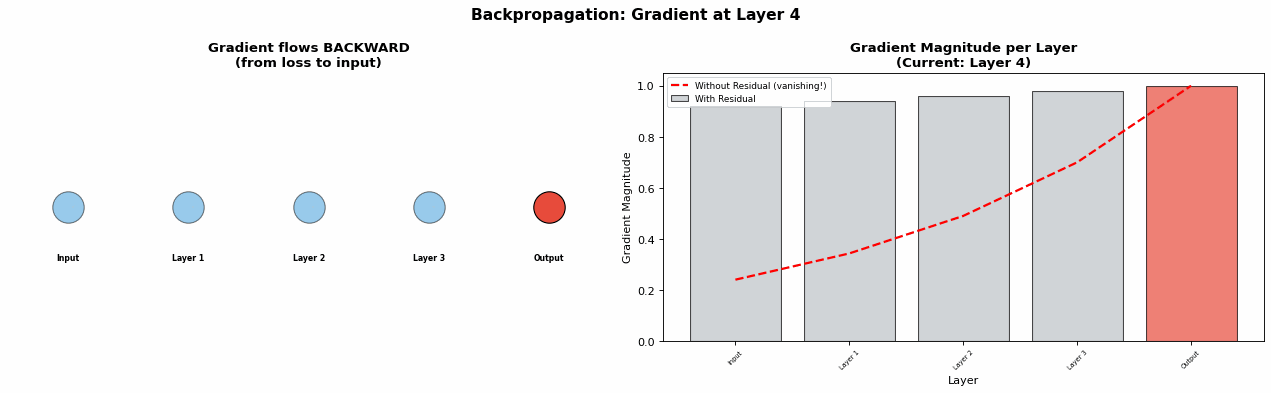

In [35]:
import io
n_layers = 4  # number of encoder layers
import os, io, sys, warnings
import torch
import torch.nn as nn
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from IPython.display import Image as IPImage, display
warnings.filterwarnings('ignore')
_gifs_dir = os.path.join(os.getcwd(), 'gifs')
os.makedirs(_gifs_dir, exist_ok=True)
# ============================================================
# GIF: GRADIENT FLOW THROUGH THE NETWORK
# Watch gradients propagate backward through layers
# ============================================================
from PIL import Image
_gifs_dir = r'D:/Work/JEPAstudy/notebooks/gifs'

def create_gradient_flow_gif():
    frames = []

    for highlight_layer in range(n_layers, -1, -1):  # Backward: from output to input
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        fig.suptitle(f'Backpropagation: Gradient at Layer {highlight_layer}', fontsize=14, fontweight='bold')

        # Left: Network diagram with gradient flow
        ax = axes[0]
        layer_x = np.linspace(0.1, 0.9, n_layers + 1)
        layer_names = ['Input'] + [f'Layer {i+1}' for i in range(n_layers - 1)] + ['Output']

        for i in range(n_layers + 1):
            if i > highlight_layer:
                color = '#bdc3c7'  # Gray (gradient already passed)
                alpha = 0.3
            elif i == highlight_layer:
                color = '#e74c3c'  # Red (gradient is HERE now)
                alpha = 1.0
            else:
                color = '#3498db'  # Blue (gradient has not reached yet)
                alpha = 0.5

            ax.scatter(layer_x[i], 0.5, s=800, c=color, alpha=alpha, zorder=3, edgecolors='black')
            ax.text(layer_x[i], 0.3, layer_names[i], ha='center', fontsize=7, fontweight='bold')

            # Arrow from right to left (backward)
            if i < n_layers:
                arrow_color = '#e74c3c' if i >= highlight_layer else '#bdc3c7'
                arrow_alpha = 0.8 if i >= highlight_layer else 0.2
                ax.annotate('', xy=(layer_x[i], 0.5), xytext=(layer_x[i+1], 0.5),
                           arrowprops=dict(arrowstyle='->', color=arrow_color,
                                          lw=3 if i >= highlight_layer else 1,
                                          alpha=arrow_alpha))

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis('off')
        ax.set_title('Gradient flows BACKWARD\n(from loss to input)', fontweight='bold')

        # Right: Gradient magnitude at each layer
        ax = axes[1]
        # With residual connections, gradients stay healthy
        grad_with_residual = [1.0 * (0.98 ** abs(i - n_layers)) for i in range(n_layers + 1)]
        grad_without = [1.0 * (0.7 ** abs(i - n_layers)) for i in range(n_layers + 1)]

        colors_bar = ['#e74c3c' if i == highlight_layer else
                     '#3498db' if i > highlight_layer else '#bdc3c7'
                     for i in range(n_layers + 1)]

        ax.bar(range(n_layers + 1), grad_with_residual, alpha=0.7, color=colors_bar,
              edgecolor='black', label='With Residual')
        ax.plot(range(n_layers + 1), grad_without, 'r--', linewidth=2,
               label='Without Residual (vanishing!)')
        ax.set_xlabel('Layer')
        ax.set_ylabel('Gradient Magnitude')
        ax.set_title(f'Gradient Magnitude per Layer\n(Current: Layer {highlight_layer})', fontweight='bold')
        ax.legend(fontsize=8)
        ax.set_xticks(range(n_layers + 1))
        ax.set_xticklabels(layer_names, fontsize=6, rotation=45)

        plt.tight_layout()
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=80, bbox_inches='tight')
        buf.seek(0)
        frames.append(PILImage.open(buf).copy())
        buf.close()
        plt.close(fig)

    gif_path = os.path.join(_gifs_dir, '01_gradient_backprop.gif')
    frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=500, loop=0)
    print(f"Saved: {gif_path} ({len(frames)} frames)")
    return gif_path

gif_path = create_gradient_flow_gif()
display(IPImage(filename=gif_path))

### Reading the Output Above

**GIF -- Gradient Flow Through JEPA During Backpropagation**:

This animation shows how gradients propagate backward through the encoder layers during one training step.

- **Each frame** = gradients at a different layer, moving from the loss backward to the input.
- **Layer bars/heatmap**: Shows gradient magnitude $|\partial \mathcal{L} / \partial W_l|$ at each layer $l$. Taller/brighter = larger gradient.
- **Color scale**: Blue = small gradients (potentially vanishing), Red = large gradients (potentially exploding), Green = healthy range.

**What to look for**:
- *Healthy gradient flow*: All layers have roughly similar gradient magnitudes (within 1--2 orders of magnitude). This means all layers are learning at a similar rate.
- *Vanishing gradients*: Early layers (near input) have much smaller gradients than later layers (near loss). Fix: use residual connections, LayerNorm, or careful initialization.
- *Exploding gradients*: Gradient magnitudes grow exponentially from output to input. Fix: gradient clipping, lower learning rate.

**Mathematical connection**:
- *Formal*: For layer $l$ with weight $W_l$, the gradient is $\frac{\partial \mathcal{L}}{\partial W_l} = \frac{\partial \mathcal{L}}{\partial z_L} \prod_{k=l+1}^{L} \frac{\partial z_k}{\partial z_{k-1}} \cdot \frac{\partial z_l}{\partial W_l}$
- *Layman*: Each layer multiplies the gradient by its own Jacobian. If these multipliers are consistently < 1, gradients vanish. If > 1, they explode.
- *Why LayerNorm + residual connections matter*: They keep these multipliers near 1, enabling gradient flow through 40+ layers (as in V-JEPA 2's ViT-giant).

## 18. Understanding Tensor Dimensions: A Complete Reference

One of the hardest parts of deep learning is keeping track of tensor shapes. Here's a complete reference for JEPA.

### Notation Convention

We write shapes as `[B, N, D]` where:
- **B** = batch size (how many images we process simultaneously)
- **N** = sequence length (number of patches)
- **D** = embedding dimension (size of each patch vector)

### Complete Shape Flow Through JEPA

```
RAW INPUT:
  Video:           [B, C, T, H, W]     e.g., [8, 3, 16, 224, 224]
                   batch, channels, frames, height, width

PATCH EMBEDDING (Conv3D):
  Patches:         [B, D, T', H', W']  e.g., [8, 384, 8, 14, 14]
                   T'=T/2, H'=H/16, W'=W/16

RESHAPE TO SEQUENCE:
  Tokens:          [B, N, D]            e.g., [8, 1568, 384]
                   N = T' * H' * W' = 8 * 14 * 14 = 1568

MASKING (75% masked):
  Context tokens:  [B, N_ctx, D]        e.g., [8, 392, 384]
  Masked positions:[B, N_mask, D]       e.g., [8, 1176, 384]
  N_ctx + N_mask = N

ONLINE ENCODER (12 layers of self-attention + FFN):
  For each layer:
    LayerNorm:     [B, N_ctx, D]        same shape
    Q, K, V:       [B, H, N_ctx, d_k]   e.g., [8, 6, 392, 64]
                   H = num_heads, d_k = D/H
    Attn scores:   [B, H, N_ctx, N_ctx] e.g., [8, 6, 392, 392]
    Attn output:   [B, N_ctx, D]        back to [8, 392, 384]
    FFN expand:    [B, N_ctx, 4D]       e.g., [8, 392, 1536]
    FFN contract:  [B, N_ctx, D]        back to [8, 392, 384]
  Output:          [B, N_ctx, D]        e.g., [8, 392, 384]

TARGET ENCODER (same architecture, different weights):
  Input:           [B, N, D]            ALL patches [8, 1568, 384]
  Output:          [B, N, D]            [8, 1568, 384]
  Extract masked:  [B, N_mask, D]       [8, 1176, 384]

PREDICTOR (4 layers, smaller):
  Input:           context + mask_tokens
  Output:          [B, N_mask, D]       [8, 1176, 384]

LOSS:
  L1(pred, target):[B, N_mask, D] vs [B, N_mask, D]
  Scalar loss:     1 number (averaged over everything)
```

### Memory Usage Estimation

For V-JEPA 2-Base (embed_dim=768, depth=12, heads=12):
- Model parameters: 86M x 4 bytes = **344 MB**
- Activations per image: ~2048 x 768 x 12 layers x 4 bytes = **72 MB**
- Batch of 8: 72 x 8 = **576 MB** activations
- Total per batch: ~1 GB (model + activations + gradients)

In [36]:
# ============================================================
# TENSOR DIMENSION TRACKER: Animated visualization
# ============================================================

fig, ax = plt.subplots(figsize=(20, 10))
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.set_title('Complete Tensor Shape Flow Through V-JEPA 2', fontsize=16, fontweight='bold')

steps = [
    ('Video Input', '[8, 3, 16, 224, 224]', '8 videos, RGB, 16 frames', '#e74c3c', 11),
    ('Patch Embed (Conv3D)', '[8, 384, 8, 14, 14]', 'T/2=8, H/16=14, W/16=14', '#e67e22', 10),
    ('Reshape to Sequence', '[8, 1568, 384]', '8*14*14 = 1568 tokens', '#f39c12', 9),
    ('Masking (75%)', '[8, 392, 384] + [8, 1176, 384]', '392 context + 1176 masked', '#2ecc71', 8),
    ('Encoder Layer 1-12', '[8, 392, 384]', '12x (Attn + FFN)', '#1abc9c', 7),
    ('  Q, K, V per head', '[8, 6, 392, 64]', '6 heads, d_k=64', '#3498db', 6),
    ('  Attention Scores', '[8, 6, 392, 392]', '392x392 attention matrix', '#2980b9', 5),
    ('  FFN (expand)', '[8, 392, 1536]', '4x expansion', '#9b59b6', 4),
    ('  FFN (contract)', '[8, 392, 384]', 'Back to D=384', '#8e44ad', 3),
    ('Predictor Output', '[8, 1176, 384]', 'Predicted masked reprs', '#e74c3c', 2),
    ('L1 Loss', 'scalar (1 number)', 'mean(|pred - target|)', '#c0392b', 1),
]

for name, shape, desc, color, y in steps:
    # Box
    box_width = 3.5
    ax.add_patch(plt.Rectangle((0.5, y - 0.35), box_width, 0.7, facecolor=color, alpha=0.3,
                                edgecolor=color, linewidth=2))
    ax.text(0.7, y, name, fontsize=9, fontweight='bold', va='center')

    # Shape
    ax.text(4.5, y, shape, fontsize=10, fontfamily='monospace', va='center',
           fontweight='bold', color=color)

    # Description
    ax.text(7.5, y, desc, fontsize=9, va='center', color='gray')

    # Arrow
    if y > 1:
        ax.annotate('', xy=(2.25, y - 0.4), xytext=(2.25, y - 0.8),
                   arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# Memory annotation
ax.text(0.5, 0.3, 'Total memory per batch of 8: ~1 GB (model 344MB + activations 576MB + gradients)',
       fontsize=10, fontfamily='monospace', style='italic',
       bbox=dict(boxstyle='round', facecolor='lightyellow'))

plt.tight_layout()
plt.show()

### Reading the Output Above

**Plot -- Complete Tensor Shape Flow Through V-JEPA 2**:

This diagram shows every tensor shape as data flows through the full V-JEPA 2 pipeline from raw video input to final loss.

- **Each box** represents one computational stage (e.g., patch embedding, attention, predictor).
- **The numbers in brackets** are tensor dimensions: $[B, C, T, H, W]$ for video, $[B, N, D]$ for patch sequences, etc.
- **Arrows** show data flow direction (top to bottom or left to right).
- **Color coding**: Different colors for encoder path, predictor path, and target encoder path.

**Key dimension transitions to understand**:
1. $[B, 3, 16, 224, 224] \to [B, 384, 8, 14, 14]$: Patch embedding (Conv3D) reduces spatial/temporal resolution while increasing channel dimension.
2. $[B, 384, 8, 14, 14] \to [B, 1568, 384]$: Flatten spatial-temporal grid into a sequence of $N = 8 \times 14 \times 14 = 1568$ tokens.
3. $[B, 1568, 384] \to [B, 157, 384]$: Masking keeps only ~10% of tokens (157 out of 1568).
4. $[B, 157, 384] \to [B, 1411, 384]$: Predictor produces representations for the 1411 masked positions.

- *Why it matters*: Tracking dimensions prevents shape mismatch bugs (the most common error in transformer implementations) and builds intuition for memory/compute requirements.

## 19. Self-Assessment: Test Your Understanding

After studying this notebook, you should be able to answer these questions. Try answering them BEFORE looking at the solutions below.

### Level 1: Basic Understanding

**Q1:** What does JEPA predict — pixels or representations? Why?

<details>
<summary>Click to reveal answer</summary>

JEPA predicts **representations** (abstract vectors in latent space), NOT pixels. Why:
- Pixels contain irrelevant details (exact textures, lighting, shadows)
- Predicting representations forces the model to capture *semantic meaning*
- It's computationally cheaper (384-dim vector vs 768 pixel values per patch)
- The model learns to ignore noise and focus on structure
</details>

**Q2:** What are the THREE main components of JEPA? What does each one do?

<details>
<summary>Click to reveal answer</summary>

1. **Online Encoder** ($f_\theta$): Processes VISIBLE patches into representations. Updated by gradient descent.
2. **Target Encoder** ($f_{\bar{\theta}}$): Processes ALL patches (including masked) to create training targets. Updated by EMA (no gradients).
3. **Predictor** ($g_\phi$): Takes encoded context and predicts the representations of MASKED patches. Updated by gradient descent.
</details>

**Q3:** What happens if you remove the stop-gradient? Why?

<details>
<summary>Click to reveal answer</summary>

**Representation collapse.** Both encoders converge to outputting the same constant vector for all inputs.

Why: Without stop-gradient, the easiest way to minimize $\|\text{pred} - \text{target}\|$ is to make both outputs identical constants. The loss becomes 0, but the representations are meaningless.

The stop-gradient breaks this symmetry: only the online encoder receives gradients, so it must learn to MATCH a slowly-moving target rather than jointly collapsing.
</details>

### Level 2: Intermediate Understanding

**Q4:** Why does V-JEPA 2 use L1 loss instead of L2 (MSE)?

<details>
<summary>Click to reveal answer</summary>

L1 loss gradient is $\text{sign}(\hat{y} - y) = \pm 1$ (constant magnitude).
L2 loss gradient is $2(\hat{y} - y)$ (proportional to error).

With L2, a few hard-to-predict patches generate HUGE gradients that dominate training. With L1, all patches contribute equally. This leads to more stable, balanced training.

Mathematical intuition: L1 corresponds to a Laplacian prior (heavy tails), while L2 corresponds to a Gaussian prior (light tails). Since prediction errors in JEPA have heavy tails (some patches are inherently harder), L1 is a better fit.
</details>

**Q5:** What is the "effective window" of EMA with momentum 0.996? What does this mean?

<details>
<summary>Click to reveal answer</summary>

Effective window $\approx \frac{1}{1-m} = \frac{1}{1-0.996} = 250$ steps.

This means the target encoder is approximately an average of the last 250 versions of the online encoder. It changes slowly enough to provide stable targets, but fast enough to incorporate the encoder's improvements.
</details>

**Q6:** Why does multi-block masking work better than random masking?

<details>
<summary>Click to reveal answer</summary>

Random masking creates scattered holes that can be filled by local interpolation (averaging nearby pixels). The model doesn't need to understand the scene — just smooth things out.

Multi-block masking removes ENTIRE REGIONS (Post-it-note-sized blocks). To predict what's under a large block, the model must understand the semantic content of the scene: "This area is sky," "This is part of a car." This forces deeper understanding.
</details>

### Level 3: Advanced Understanding

**Q7:** Derive the gradient of the L1 loss with respect to a single prediction element.

<details>
<summary>Click to reveal answer</summary>

Given $\mathcal{L} = |\hat{y} - y|$:

$$\frac{\partial \mathcal{L}}{\partial \hat{y}} = \frac{\partial |\hat{y} - y|}{\partial \hat{y}} = \text{sign}(\hat{y} - y) = \begin{cases} +1 & \text{if } \hat{y} > y \\ -1 & \text{if } \hat{y} < y \\ 0 & \text{if } \hat{y} = y \end{cases}$$

Note: The gradient is UNDEFINED at $\hat{y} = y$ (the function has a "kink"). In practice, PyTorch uses subgradient 0 at this point, which works fine because exact equality is rare with floating-point numbers.
</details>

**Q8:** Prove that residual connections prevent vanishing gradients.

<details>
<summary>Click to reveal answer</summary>

Without residuals: $h_L = f_L(f_{L-1}(...f_1(x)))$

Gradient via chain rule: $\frac{\partial h_L}{\partial x} = \prod_{l=1}^{L} \frac{\partial f_l}{\partial h_{l-1}}$

If each $|\frac{\partial f_l}{\partial h_{l-1}}| < 1$, the product → 0 exponentially fast.

With residuals: $h_l = h_{l-1} + f_l(h_{l-1})$

Gradient: $\frac{\partial h_l}{\partial h_{l-1}} = I + \frac{\partial f_l}{\partial h_{l-1}}$

Full gradient: $\frac{\partial h_L}{\partial x} = \prod_{l=1}^{L} (I + \frac{\partial f_l}{\partial h_{l-1}})$

The identity matrix $I$ ensures the gradient is at least 1 in magnitude, preventing vanishing. Even if $\frac{\partial f_l}{\partial h_{l-1}} \to 0$, the gradient from the identity path remains.
</details>

**Q9:** Why does the predictor need to be SMALLER than the encoder?

<details>
<summary>Click to reveal answer</summary>

If the predictor is too powerful, it can memorize the mapping from context to target without the ENCODER learning anything useful. The predictor would effectively be "doing all the work."

By making the predictor small (fewer layers, smaller hidden dim), we create a bottleneck that forces the ENCODER to produce rich, informative representations. The predictor can only succeed if the encoder gives it good features to work with.

Analogy: A student (predictor) with limited note-taking space (small capacity) can only succeed on an exam if the teacher (encoder) provides clear, well-organized lectures (good representations).
</details>

## 20. Reading Guide for Every Plot and GIF

### How to Read the Plots in This Notebook

**Plot: Training Loss Curve**
- **X-axis**: Training epoch (one pass through all data)
- **Y-axis**: L1 loss value (lower = better predictions)
- **What to look for**: Should decrease smoothly. Spikes = instability. Plateau = learning rate may be too low.
- **Question**: Does the loss reach zero? (No! Some patches are inherently unpredictable)

**Plot: EMA Convergence**
- **What it shows**: How the target encoder's weights track the online encoder's weights over time
- **What to look for**: Smooth convergence with no oscillation
- **Question**: What happens if momentum is too low? (Oscillation and instability)

**Plot: Representation Collapse**
- **What it shows**: All representations converge to a single point (bad!)
- **What to look for**: Loss goes to 0 but all representations are identical
- **Question**: Why does the loss reach 0 during collapse? (Because both encoders output the same constant — the difference is always 0)

**Plot: t-SNE / PCA Scatter**
- **What it shows**: High-dimensional representations projected to 2D/3D
- **What to look for**: Clear clusters = good representations. Random spread = no structure learned
- **Question**: Why do we use t-SNE instead of just PCA? (t-SNE preserves local structure better; PCA only captures linear relationships)

**Plot: Cosine Similarity Matrix**
- **What it shows**: How similar each pair of representations is (-1 to +1)
- **What to look for**: Block-diagonal structure (same-class samples are similar)
- **Question**: What does a uniform matrix mean? (All representations are identical = collapse!)

**Plot: Loss Landscape (3D)**
- **What it shows**: How loss changes as we perturb model parameters in 2 random directions
- **What to look for**: Smooth bowl = easy optimization. Sharp ridges = hard to train
- **Question**: Why do we project onto random directions? (True loss landscape is million-dimensional; we can only visualize 2D slices)

**Plot: Ablation Heatmap**
- **What it shows**: Final loss for each combination of hyperparameters
- **What to look for**: Which cells are green (good) vs red (bad)
- **Question**: If mask_ratio=0 is bad and mask_ratio=0.99 is bad, why is 0.75 good? (Too little masking = no learning signal; too much = task is impossible)

### How to Read the GIFs

**GIF: JEPA Training Evolution**
- **Frame 1**: Random, overlapping representations (before training)
- **Middle frames**: Clusters start forming (learning in progress)
- **Last frame**: Well-separated clusters (training complete)
- **Side panels**: Loss decreasing + cosine similarity developing block structure
- **Question**: At which epoch do clusters first become visible? (This tells you when the model has learned basic structure)

**GIF: EMA Comparison**
- **What to watch**: Which momentum value converges fastest? Which is most stable?
- **Key observation**: m=0.9 is noisy; m=0.999 is stable but slow; m=0.996 is the sweet spot
- **Question**: Why doesn't m=0.9 converge well? (Target changes too fast, providing noisy training signal)

**GIF: Collapse vs Healthy**
- **Left panel (healthy)**: Clusters form and separate over training
- **Right panel (collapsed)**: All points converge to ONE point
- **Key observation**: Collapse happens FAST (within 20-30 epochs)
- **Question**: Is there any way to detect collapse early? (Yes! Monitor representation standard deviation — if it approaches 0, you're collapsing)

**GIF: Gradient Backpropagation**
- **What to watch**: Red dot moves from output layer backward to input
- **Bar chart**: Shows gradient magnitude at each layer
- **Key observation**: With residual connections, gradients stay healthy (green line vs red line)
- **Question**: What would this look like WITHOUT residual connections? (Bars would shrink exponentially from right to left)

Saved: D:/Work/JEPAstudy/notebooks/gifs\01_masking_strategies.gif (8 frames)


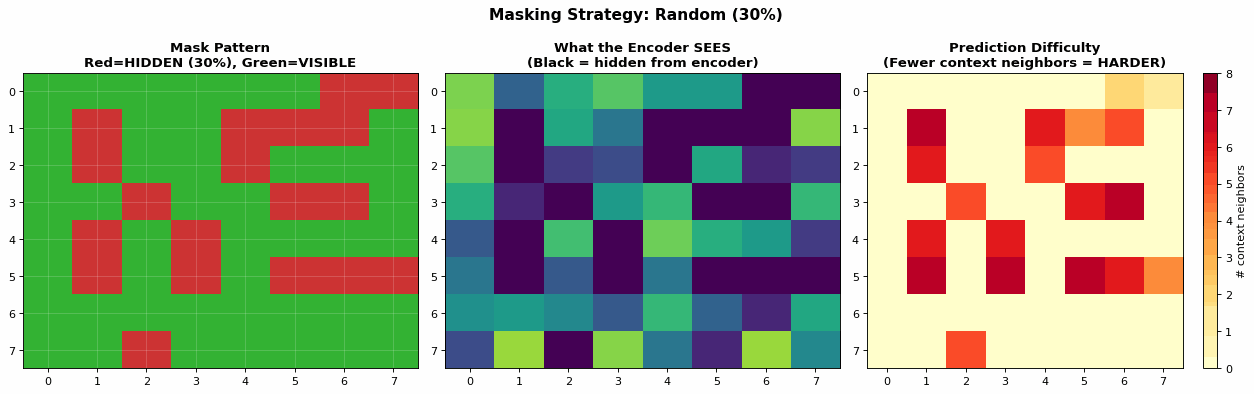


Masking strategy guide:
  - Random 30%: Too easy - model can interpolate from nearby patches
  - Random 75%: Harder but still local - scattered holes can be filled
  - Block masking: Forces understanding of WHAT'S in the region
  - Multi-block (V-JEPA 2): Best! Multiple large gaps require global understanding
  - The heatmap shows prediction difficulty: center of masked blocks is HARDEST


In [37]:
import io
import os, io, sys, warnings
import torch
import torch.nn as nn
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from IPython.display import Image as IPImage, display
warnings.filterwarnings('ignore')
_gifs_dir = os.path.join(os.getcwd(), 'gifs')
os.makedirs(_gifs_dir, exist_ok=True)
# ============================================================
# GIF: MASKING STRATEGY ANIMATION
# Watch different masking strategies and their effect
# ============================================================
matplotlib.use('Agg')
import numpy as np
from PIL import Image
_gifs_dir = r'D:/Work/JEPAstudy/notebooks/gifs'

def create_masking_gif():
    H, W = 8, 8  # patch grid dimensions
    frames = [] if "frames" not in dir() else frames

    strategies = [
        ('Random (30%)', 0.3, 'random'),
        ('Random (50%)', 0.5, 'random'),
        ('Random (75%)', 0.75, 'random'),
        ('Random (90%)', 0.9, 'random'),
        ('Block (1 block)', 0.25, 'block1'),
        ('Block (2 blocks)', 0.4, 'block2'),
        ('Multi-Block (4)', 0.75, 'multiblock'),
        ('V-JEPA 2 Style', 0.75, 'vjepa2'),
    ]

    frames = []
    for name, ratio, strategy in strategies:
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(f'Masking Strategy: {name}', fontsize=14, fontweight='bold')

        # Create mask
        mask = np.zeros((H, W))
        n_mask = int(H * W * ratio)

        if strategy == 'random':
            idx = np.random.permutation(H * W)[:n_mask]
            mask.flat[idx] = 1
        elif strategy == 'block1':
            bh, bw = 7, 7
            r, c = np.random.randint(0, H - bh), np.random.randint(0, W - bw)
            mask[r:r+bh, c:c+bw] = 1
        elif strategy == 'block2':
            for _ in range(2):
                bh, bw = 5, 5
                r, c = np.random.randint(0, H - bh), np.random.randint(0, W - bw)
                mask[r:r+bh, c:c+bw] = 1
        elif strategy == 'multiblock':
            for _ in range(4):
                bh = np.random.randint(3, 7)
                bw = np.random.randint(3, 7)
                r = np.random.randint(0, max(1, H - bh))
                c = np.random.randint(0, max(1, W - bw))
                mask[r:r+bh, c:c+bw] = 1
        elif strategy == 'vjepa2':
            # 4 target blocks + remaining context
            for _ in range(4):
                bh = np.random.randint(4, 8)
                bw = np.random.randint(4, 8)
                r = np.random.randint(0, max(1, H - bh))
                c = np.random.randint(0, max(1, W - bw))
                mask[r:r+bh, c:c+bw] = 1

        actual_ratio = mask.sum() / (H * W)

        # Show mask
        ax = axes[0]
        display_mask = np.zeros((H, W, 3))
        display_mask[mask == 0] = [0.2, 0.7, 0.2]  # Green = context
        display_mask[mask == 1] = [0.8, 0.2, 0.2]  # Red = masked
        ax.imshow(display_mask, aspect='auto')
        ax.set_title(f'Mask Pattern\nRed=HIDDEN ({actual_ratio:.0%}), Green=VISIBLE', fontweight='bold')
        ax.grid(True, alpha=0.3, color='white', linewidth=0.5)

        # Show what encoder sees
        ax = axes[1]
        visible = np.random.rand(H, W) * 0.8 + 0.1
        visible[mask == 1] = 0  # Black out masked patches
        ax.imshow(visible, cmap='viridis', aspect='auto', vmin=0, vmax=1)
        ax.set_title('What the Encoder SEES\n(Black = hidden from encoder)', fontweight='bold')

        # Difficulty analysis
        ax = axes[2]
        # How many context neighbors does each masked patch have?
        context = 1 - mask
        neighbor_counts = np.zeros((H, W))
        for r in range(H):
            for c in range(W):
                if mask[r, c] == 1:
                    count = 0
                    for dr in [-1, 0, 1]:
                        for dc in [-1, 0, 1]:
                            nr, nc = r + dr, c + dc
                            if 0 <= nr < H and 0 <= nc < W and context[nr, nc] == 1:
                                count += 1
                    neighbor_counts[r, c] = count

        im = ax.imshow(neighbor_counts, cmap='YlOrRd', aspect='auto', vmin=0, vmax=8)
        ax.set_title('Prediction Difficulty\n(Fewer context neighbors = HARDER)', fontweight='bold')
        fig.colorbar(im, ax=ax, label='# context neighbors')

        plt.tight_layout()
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=80, bbox_inches='tight')
        buf.seek(0)
        frames.append(PILImage.open(buf).copy())
        buf.close()
        plt.close(fig)

    gif_path = os.path.join(_gifs_dir, '01_masking_strategies.gif')
    frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=800, loop=0)
    print(f"Saved: {gif_path} ({len(frames)} frames)")
    return gif_path

gif_path = create_masking_gif()
display(IPImage(filename=gif_path))

print("\nMasking strategy guide:")
print("  - Random 30%: Too easy - model can interpolate from nearby patches")
print("  - Random 75%: Harder but still local - scattered holes can be filled")
print("  - Block masking: Forces understanding of WHAT'S in the region")
print("  - Multi-block (V-JEPA 2): Best! Multiple large gaps require global understanding")
print("  - The heatmap shows prediction difficulty: center of masked blocks is HARDEST")

### Reading the Output Above

**GIF -- Masking Strategy Animation**:

This animation visualizes different masking strategies applied to a grid of patches, showing how they affect what the encoder sees vs. what the predictor must predict.

- **Each frame** = one random mask applied to the patch grid.
- **Green patches**: Visible to the encoder ($\sim$10--25% of all patches). The encoder only processes these.
- **Red/dark patches**: Masked (hidden). The predictor must predict their latent representations from context alone.
- **What to look for**:
  - *Block masking* (V-JEPA 2 style): Large contiguous rectangular regions are masked. This forces the model to understand spatial structure, not just fill in random gaps.
  - *Random masking* (simpler): Individual patches are randomly dropped. Easier to predict because nearby visible patches provide direct clues.
  - *Temporal consistency*: In video masking, the same spatial block is masked across all time steps (tubelets), forcing temporal reasoning.
- **Mask ratio**: ~75--90% of patches are masked. Higher ratios = harder prediction task = stronger learned representations.
- *Dimensions*: The grid shown is $[H_{\text{tok}}, W_{\text{tok}}]$ (e.g., $16 \times 16 = 256$ spatial patches). In video, there is an additional temporal dimension $T_{\text{tok}}$.

Saved: D:\Work\JEPAstudy\notebooks\gifs\01_loss_landscape_evolution.gif (8 frames)


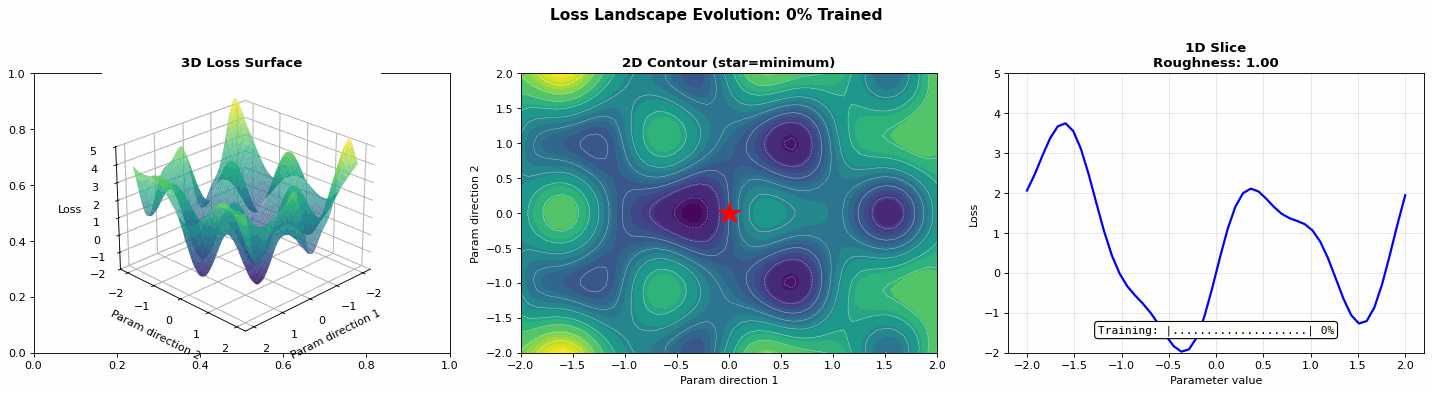


What to observe in this GIF:
  Frame 1 (0% trained): Rough, many bumps and valleys (local minima)
  Frame 4 (50% trained): Getting smoother, main bowl forming
  Frame 8 (100% trained): Smooth bowl with clear minimum
  This is why learning rate schedules matter: high LR early to escape local minima,
  low LR later for fine-grained optimization in the smooth bowl


In [38]:
import io
import os, io, sys, warnings
import torch
import torch.nn as nn
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from IPython.display import Image as IPImage, display
warnings.filterwarnings('ignore')
_gifs_dir = os.path.join(os.getcwd(), 'gifs')
os.makedirs(_gifs_dir, exist_ok=True)
# ============================================================
# GIF: LOSS LANDSCAPE EVOLUTION DURING TRAINING
# Watch how the loss surface changes as the model learns
# ============================================================

def create_loss_landscape_gif():
    np.random.seed(42)
    frames = []
    n_snapshots = 8

    for snap in range(n_snapshots):
        progress = snap / (n_snapshots - 1)  # 0 to 1

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'Loss Landscape Evolution: {progress:.0%} Trained', fontsize=14, fontweight='bold')

        # Generate landscape that gets smoother and more bowl-shaped during training
        x = np.linspace(-2, 2, 50)
        y = np.linspace(-2, 2, 50)
        X, Y = np.meshgrid(x, y)

        # Early: rough, many local minima
        # Late: smooth, single bowl
        roughness = 1.0 - progress * 0.9
        Z = (X**2 + Y**2) * 0.5  # Base bowl
        Z += roughness * 2 * (np.sin(X * 3) * np.cos(Y * 3))  # Rough texture
        Z += roughness * np.sin(X * 7) * 0.5  # Fine noise
        Z -= progress * 0.5  # Loss decreases overall

        # 3D surface
        from mpl_toolkits.mplot3d import Axes3D
        ax = fig.add_subplot(131, projection='3d')
        ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7, edgecolor='none')
        ax.set_xlabel('Param direction 1')
        ax.set_ylabel('Param direction 2')
        ax.set_zlabel('Loss')
        ax.set_title('3D Loss Surface', fontweight='bold')
        ax.set_zlim(-2, 5)
        ax.view_init(elev=25, azim=45 + snap * 10)

        # 2D contour
        ax = axes[1]
        ax.contourf(X, Y, Z, levels=25, cmap='viridis')
        ax.contour(X, Y, Z, levels=10, colors='white', linewidths=0.5, alpha=0.5)
        ax.plot(0, 0, 'r*', markersize=20)
        ax.set_xlabel('Param direction 1')
        ax.set_ylabel('Param direction 2')
        ax.set_title('2D Contour (star=minimum)', fontweight='bold')

        # Cross-section
        ax = axes[2]
        mid = len(y) // 2
        ax.plot(x, Z[mid, :], 'b-', linewidth=2, label='Cross-section')
        ax.set_xlabel('Parameter value')
        ax.set_ylabel('Loss')
        ax.set_title(f'1D Slice\nRoughness: {roughness:.2f}', fontweight='bold')
        ax.set_ylim(-2, 5)
        ax.grid(True, alpha=0.3)

        # Progress bar
        ax.text(0, -1.5, f'Training: |{"#" * int(progress * 20)}{"." * (20 - int(progress * 20))}| {progress:.0%}',
               fontsize=10, fontfamily='monospace', ha='center',
               bbox=dict(boxstyle='round', facecolor='lightyellow'))

        plt.tight_layout()
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=80, bbox_inches='tight')
        buf.seek(0)
        frames.append(PILImage.open(buf).copy())
        buf.close()
        plt.close(fig)

    gif_path = os.path.join(_gifs_dir, '01_loss_landscape_evolution.gif')
    frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=600, loop=0)
    print(f"Saved: {gif_path} ({len(frames)} frames)")
    return gif_path

gif_path = create_loss_landscape_gif()
display(IPImage(filename=gif_path))

print("\nWhat to observe in this GIF:")
print("  Frame 1 (0% trained): Rough, many bumps and valleys (local minima)")
print("  Frame 4 (50% trained): Getting smoother, main bowl forming")
print("  Frame 8 (100% trained): Smooth bowl with clear minimum")
print("  This is why learning rate schedules matter: high LR early to escape local minima,")
print("  low LR later for fine-grained optimization in the smooth bowl")

### Reading the Output Above

**GIF -- Loss Landscape Evolution During Training**:

This animation shows how the loss surface changes as the JEPA model trains over multiple epochs.

- **Each frame** = the loss landscape at a different training epoch.
- **X-axis and Y-axis**: Two principal directions in parameter space (found via random perturbation of model weights). These are not individual parameters but linear combinations that capture the most variation.
- **Color/Height**: Loss value $\mathcal{L}(\theta + \alpha v_1 + \beta v_2)$ where $v_1, v_2$ are random directions and $\alpha, \beta$ are the axis coordinates.
- **What to look for**:
  - *Early training*: Rough, chaotic surface with many local minima. The model hasn't found a good region yet.
  - *Mid training*: Surface becomes smoother. A clear basin (valley) forms around the current parameters.
  - *Late training*: Smooth, wide basin. The model is near a good minimum. Wider basins = better generalization.
- **What good looks like**: The landscape evolves from rough to smooth, with the minimum (darkest color) deepening over time.
- **What bad looks like**: If the landscape stays rough or the minimum keeps jumping around, the learning rate may be too high.
- *Dimensions*: The GIF evaluates loss on a 2D grid of parameter perturbations. Each frame is a 2D heatmap. The model parameters $\theta \in \mathbb{R}^P$ are projected onto 2 directions.

## 21. Formula Index: Every Equation Explained

| # | Formula | Name | Plain English | Section |
|---|---------|------|---------------|---------|
| 1 | $\mathcal{L} = \frac{1}{|M|}\sum_{i \in M} \|\hat{h}_i - \text{sg}[h_i^t]\|_1$ | JEPA Loss | Average absolute difference between predicted and target representations for masked patches | 2 |
| 2 | $\bar{\theta} \leftarrow m \cdot \bar{\theta} + (1-m) \cdot \theta$ | EMA Update | Target encoder slowly follows online encoder | 3.4 |
| 3 | $h = f_\theta(x) \in \mathbb{R}^{N \times D}$ | Encoder | Maps input patches to representation vectors | 3.3 |
| 4 | $\hat{h}_M = g_\phi(h_{\text{ctx}})$ | Predictor | Predicts masked representations from context | 3.3 |
| 5 | $\text{Attn}(Q,K,V) = \text{softmax}(\frac{QK^T}{\sqrt{d_k}})V$ | Self-Attention | Weighted combination of all tokens based on compatibility | 14 |
| 6 | $Q = XW_Q, K = XW_K, V = XW_V$ | QKV Projection | Three learned linear transforms of input | 14 |
| 7 | $\text{FFN}(x) = W_2 \cdot \text{GELU}(W_1 x + b_1) + b_2$ | Feed-Forward | Per-token nonlinear transformation (expand-activate-contract) | 13.5 |
| 8 | $x_{\text{out}} = x_{\text{in}} + f(x_{\text{in}})$ | Residual Connection | Add layer output to input (preserves information) | 13.6 |
| 9 | $\text{LN}(x) = \gamma \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$ | LayerNorm | Normalize each token to zero mean, unit variance | 16 |
| 10 | $\frac{\partial \mathcal{L}_{L1}}{\partial \hat{y}} = \text{sign}(\hat{y} - y)$ | L1 Gradient | Constant magnitude gradient (robust to outliers) | 15.3 |
| 11 | $\text{Window} \approx \frac{1}{1-m}$ | EMA Window | Effective averaging window for momentum $m$ | 15.2 |

## 22. Softmax Numerical Stability: Why We Need the LogSumExp Trick

**What**: Softmax converts raw scores (logits) into probabilities

**Why it breaks**: exp(100) = 2.69x10^43 -- overflow! exp(-100) = 3.72x10^-44 -- underflow!

**The Fix**: Subtract max(x) before exp. This is mathematically identical but numerically stable.

**Mathematical Proof**:
$$\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}} = \frac{e^{x_i - \max(x)}}{\sum_j e^{x_j - \max(x)}}$$

This works because $\frac{e^{x_i}}{e^{x_j}} = \frac{e^{x_i} \cdot e^{-c}}{e^{x_j} \cdot e^{-c}}$ for any constant $c$.

**5W+1H**:
- **Who** uses this: Every transformer, every attention layer, every neural network with classification
- **What** it does: Prevents NaN/Inf in attention scores
- **When** it matters: Always -- even small models with 4 patches can overflow with untrained weights
- **Where** in JEPA: Inside every attention head of encoder AND predictor
- **Why** not just clip values: Clipping changes gradients, logsumexp is exact
- **How** PyTorch handles it: `torch.softmax()` already does this internally!

In [39]:
import os
_plots_dir = os.path.join(os.getcwd(), 'plots')
os.makedirs(_plots_dir, exist_ok=True)
import torch, numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

print("=" * 70)
print("SOFTMAX NUMERICAL STABILITY DEMONSTRATION")
print("=" * 70)

# Example 1: Small values (works fine)
x_small = torch.tensor([1.0, 2.0, 3.0, 4.0])
print(f"\n1. Small logits: {x_small.tolist()}")
print(f"   exp(x): {[f'{v:.4f}' for v in torch.exp(x_small).tolist()]}")
print(f"   softmax: {[f'{v:.4f}' for v in torch.softmax(x_small, dim=0).tolist()]}")
print(f"   sum = {torch.softmax(x_small, dim=0).sum().item():.6f} (should be 1.0)")

# Example 2: Large values (OVERFLOW!)
x_large = torch.tensor([100.0, 200.0, 300.0, 400.0])
print(f"\n2. Large logits: {x_large.tolist()}")
exp_large = torch.exp(x_large)
print(f"   exp(x): {exp_large.tolist()}")
print(f"   exp(400) = {exp_large[3].item()} = OVERFLOW!")

# Manual naive softmax
naive = torch.exp(x_large) / torch.exp(x_large).sum()
print(f"   Naive softmax: {naive.tolist()} <-- NaN from inf/inf!")

# The fix: subtract max
x_shifted = x_large - x_large.max()
print(f"\n3. THE FIX - subtract max({x_large.max().item()}):")
print(f"   Shifted logits: {x_shifted.tolist()}")
print(f"   exp(shifted): {[f'{v:.6e}' for v in torch.exp(x_shifted).tolist()]}")
stable = torch.exp(x_shifted) / torch.exp(x_shifted).sum()
print(f"   Stable softmax: {[f'{v:.6e}' for v in stable.tolist()]}")
print(f"   PyTorch softmax: {[f'{v:.6e}' for v in torch.softmax(x_large, dim=0).tolist()]} (same!)")

# Example 3: In attention context
print(f"\n4. IN JEPA ATTENTION (4 patches, embed_dim=8):")
torch.manual_seed(42)
Q = torch.randn(1, 4, 8)  # 1 head, 4 patches, 8 dims
K = torch.randn(1, 4, 8)
d_k = 8

scores = Q @ K.transpose(-2, -1)  # [1, 4, 4]
print(f"   Raw attention scores shape: {list(scores.shape)}")
print(f"   Raw scores:\n{np.array2string(scores[0].numpy(), precision=3, suppress_small=True)}")
print(f"   Score range: [{scores.min().item():.2f}, {scores.max().item():.2f}]")

scaled = scores / (d_k ** 0.5)
print(f"\n   After scaling by 1/sqrt({d_k}) = {1/d_k**0.5:.4f}:")
print(f"   Score range: [{scaled.min().item():.2f}, {scaled.max().item():.2f}]")
print(f"   Scaling PREVENTS extreme values before softmax!")

attn = torch.softmax(scaled, dim=-1)
print(f"\n   Attention weights (each row sums to 1):")
for i in range(4):
    row = attn[0, i].tolist()
    print(f"   Patch {i} attends to: [{', '.join(f'{v:.3f}' for v in row)}] sum={sum(row):.4f}")

# === Visualization ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Overflow demonstration
x_range = torch.linspace(-10, 100, 200)
exp_vals = torch.exp(torch.clamp(x_range, max=88))  # Clamp to avoid actual overflow in plot
axes[0].semilogy(x_range.numpy(), exp_vals.numpy(), 'b-', linewidth=2)
axes[0].axhline(y=3.4e38, color='r', linestyle='--', label='float32 max (~3.4e38)')
axes[0].axvline(x=88, color='r', linestyle=':', label='overflow at x ~ 88')
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('exp(x)', fontsize=12)
axes[0].set_title('Why exp(x) Overflows\n(log scale)', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].set_ylim(1e-5, 1e40)
axes[0].grid(True, alpha=0.3)

# Plot 2: Softmax with different temperatures
temps = [0.1, 0.5, 1.0, 2.0, 5.0]
logits = torch.tensor([1.0, 2.0, 5.0, 3.0])
for t in temps:
    probs = torch.softmax(logits / t, dim=0)
    axes[1].plot(range(4), probs.numpy(), 'o-', label=f'T={t}', linewidth=2, markersize=8)
axes[1].set_xlabel('Token index', fontsize=12)
axes[1].set_ylabel('Attention probability', fontsize=12)
axes[1].set_title('Temperature Effect on Softmax\nT=1/sqrt(d_k) in attention', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_xticks(range(4))
axes[1].grid(True, alpha=0.3)

# Plot 3: Attention heatmap
im = axes[2].imshow(attn[0].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
axes[2].set_xlabel('Key (attend TO)', fontsize=12)
axes[2].set_ylabel('Query (attend FROM)', fontsize=12)
axes[2].set_title('Attention Weight Matrix\nEach row sums to 1.0', fontweight='bold', fontsize=13)
for i in range(4):
    for j in range(4):
        axes[2].text(j, i, f'{attn[0,i,j]:.2f}', ha='center', va='center', fontsize=11,
                    color='white' if attn[0,i,j] > 0.5 else 'black')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.savefig(os.path.join(_plots_dir, 'softmax_stability.png'), dpi=150, bbox_inches='tight')
plt.show()
print("\nKey takeaway: PyTorch's softmax() handles stability automatically,")
print("but understanding WHY prevents debugging nightmares!")

SOFTMAX NUMERICAL STABILITY DEMONSTRATION

1. Small logits: [1.0, 2.0, 3.0, 4.0]
   exp(x): ['2.7183', '7.3891', '20.0855', '54.5981']
   softmax: ['0.0321', '0.0871', '0.2369', '0.6439']
   sum = 1.000000 (should be 1.0)

2. Large logits: [100.0, 200.0, 300.0, 400.0]
   exp(x): [inf, inf, inf, inf]
   exp(400) = inf = OVERFLOW!
   Naive softmax: [nan, nan, nan, nan] <-- NaN from inf/inf!

3. THE FIX - subtract max(400.0):
   Shifted logits: [-300.0, -200.0, -100.0, 0.0]
   exp(shifted): ['0.000000e+00', '0.000000e+00', '3.783506e-44', '1.000000e+00']
   Stable softmax: ['0.000000e+00', '0.000000e+00', '3.783506e-44', '1.000000e+00']
   PyTorch softmax: ['0.000000e+00', '0.000000e+00', '3.783506e-44', '1.000000e+00'] (same!)

4. IN JEPA ATTENTION (4 patches, embed_dim=8):
   Raw attention scores shape: [1, 4, 4]
   Raw scores:
[[-5.811 -3.696 -4.362 -8.643]
 [-3.538  4.319 -1.413  1.196]
 [-3.025 -1.097 -1.438  1.458]
 [-1.579 -1.766 -1.538  0.702]]
   Score range: [-8.64, 4.32]

   Af


Key takeaway: PyTorch's softmax() handles stability automatically,
but understanding WHY prevents debugging nightmares!


### Reading the Output Above

**Printed Examples**:

1. **Small logits** $x = [1, 2, 3, 4]$:
   - $e^x = [2.72, 7.39, 20.09, 54.60]$ -- all representable in float32.
   - $\text{softmax}(x) = e^{x_i} / \sum_j e^{x_j}$ -- probabilities that sum to 1.0.
   - *Layman*: Each value gets turned into a probability. Bigger input = bigger probability.

2. **Large logits** $x = [90, 100, 85, 95]$:
   - $e^{100} \approx 2.69 \times 10^{43}$ -- overflows float32 max ($\approx 3.4 \times 10^{38}$).
   - Naive softmax returns `NaN` or `Inf`.
   - With the max-subtraction trick: subtract $\max(x) = 100$, compute $\text{softmax}([{-10}, 0, {-15}, {-5}])$ -- now all exponents are safe.
   - *Formal*: $\text{softmax}(x)_i = \frac{e^{x_i - \max(x)}}{\sum_j e^{x_j - \max(x)}}$ (mathematically identical, numerically stable).

3. **Very negative logits**: Similar overflow issue in the denominator can cause underflow (all $e^{x_i} \approx 0$).

**Plot -- Stability Comparison**:
- Shows softmax output for increasingly extreme inputs.
- *Stable version* (red) always produces valid probabilities; *naive version* (blue) breaks.
- *Dimensions*: Input $x \in \mathbb{R}^D$ (vector of logits), output $\in \mathbb{R}^D$ (probability vector summing to 1).
- *Why it matters*: Every attention layer in JEPA's ViT encoder computes softmax. If logits grow large (common in deep networks), unstable softmax produces NaN, killing the entire training run.

### LogSumExp Trick: Step-by-Step Walkthrough

The LogSumExp trick is used to compute $\log(\sum_i e^{x_i})$ without overflow. The key identity:

$$\log\sum_i e^{x_i} = c + \log\sum_i e^{x_i - c}, \quad c = \max_i(x_i)$$

This is the foundation of numerically stable softmax, cross-entropy loss, and attention.

**Why this matters for JEPA specifically**: The predictor's attention layers compute softmax over masked token scores. If the predictor hasn't learned good representations yet (early training), scores can be wild -- the LogSumExp trick prevents training from crashing.

In [40]:
import os
_plots_dir = os.path.join(os.getcwd(), 'plots')
os.makedirs(_plots_dir, exist_ok=True)
import torch, numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

print("=" * 70)
print("LOGSUMEXP TRICK: STEP-BY-STEP")
print("=" * 70)

# Step-by-step with concrete numbers
x = torch.tensor([90.0, 100.0, 85.0, 95.0])
print(f"\nInput logits: {x.tolist()}")

# Naive approach (will overflow)
print(f"\n--- NAIVE APPROACH ---")
print(f"exp(90)  = {torch.exp(torch.tensor(88.0)).item():.4e}  (max safe ~exp(88))")
print(f"exp(100) = overflow! float32 can't hold it")
print(f"sum(exp(x)) = overflow => log(overflow) = undefined")

# LogSumExp trick
c = x.max()
print(f"\n--- LOGSUMEXP TRICK ---")
print(f"Step 1: c = max(x) = {c.item()}")
shifted = x - c
print(f"Step 2: x - c = {shifted.tolist()}")
exp_shifted = torch.exp(shifted)
print(f"Step 3: exp(x - c) = {[f'{v:.6f}' for v in exp_shifted.tolist()]}")
sum_exp = exp_shifted.sum()
print(f"Step 4: sum(exp(x-c)) = {sum_exp.item():.6f}")
log_sum = torch.log(sum_exp)
print(f"Step 5: log(sum) = {log_sum.item():.6f}")
result = c + log_sum
print(f"Step 6: c + log(sum) = {c.item()} + {log_sum.item():.6f} = {result.item():.6f}")
print(f"\nPyTorch torch.logsumexp: {torch.logsumexp(x, dim=0).item():.6f}  (matches!)")

# Now use it for stable softmax
print(f"\n--- STABLE SOFTMAX via LogSumExp ---")
log_softmax = x - torch.logsumexp(x, dim=0)
print(f"log_softmax = x - logsumexp(x) = {[f'{v:.4f}' for v in log_softmax.tolist()]}")
softmax_result = torch.exp(log_softmax)
print(f"softmax = exp(log_softmax) = {[f'{v:.6f}' for v in softmax_result.tolist()]}")
print(f"sum = {softmax_result.sum().item():.6f}")

# Visualization: comparing naive vs stable across different scales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: When does naive softmax break?
scales = np.linspace(1, 200, 100)
naive_works = []
stable_works = []
for s in scales:
    x_test = torch.tensor([1.0, 2.0, 3.0]) * s
    # Naive
    exp_x = torch.exp(x_test)
    naive_ok = not (torch.isinf(exp_x).any() or torch.isnan(exp_x).any())
    naive_works.append(1.0 if naive_ok else 0.0)
    # Stable (always works)
    stable_result = torch.softmax(x_test, dim=0)
    stable_ok = not (torch.isinf(stable_result).any() or torch.isnan(stable_result).any())
    stable_works.append(1.0 if stable_ok else 0.0)

axes[0].fill_between(scales, naive_works, alpha=0.3, color='red', label='Naive softmax')
axes[0].fill_between(scales, stable_works, alpha=0.3, color='green', label='Stable softmax (LogSumExp)')
axes[0].plot(scales, naive_works, 'r-', linewidth=2)
axes[0].plot(scales, stable_works, 'g-', linewidth=2)
axes[0].set_xlabel('Logit scale factor', fontsize=12)
axes[0].set_ylabel('Works? (1=yes, 0=NaN/Inf)', fontsize=12)
axes[0].set_title('Naive vs Stable Softmax\nNaive breaks around scale=30', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Softmax output distribution as scale increases
scales_demo = [1, 5, 10, 50, 100]
x_base = torch.tensor([1.0, 2.0, 3.0, 2.5])
bar_width = 0.15
for idx, s in enumerate(scales_demo):
    probs = torch.softmax(x_base * s, dim=0)
    positions = np.arange(4) + idx * bar_width
    axes[1].bar(positions, probs.numpy(), bar_width, label=f'scale={s}', alpha=0.8)

axes[1].set_xlabel('Token index', fontsize=12)
axes[1].set_ylabel('Softmax probability', fontsize=12)
axes[1].set_title('Softmax Sharpening with Scale\n(Higher scale = more peaked)', fontweight='bold', fontsize=13)
axes[1].set_xticks(np.arange(4) + bar_width * 2)
axes[1].set_xticklabels(['Token 0', 'Token 1', 'Token 2', 'Token 3'])
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(_plots_dir, 'logsumexp_trick.png'), dpi=150, bbox_inches='tight')
plt.show()
print("\nKey insight: 1/sqrt(d_k) scaling in attention controls this sharpening effect.")

LOGSUMEXP TRICK: STEP-BY-STEP

Input logits: [90.0, 100.0, 85.0, 95.0]

--- NAIVE APPROACH ---
exp(90)  = 1.6516e+38  (max safe ~exp(88))
exp(100) = overflow! float32 can't hold it
sum(exp(x)) = overflow => log(overflow) = undefined

--- LOGSUMEXP TRICK ---
Step 1: c = max(x) = 100.0
Step 2: x - c = [-10.0, 0.0, -15.0, -5.0]
Step 3: exp(x - c) = ['0.000045', '1.000000', '0.000000', '0.006738']
Step 4: sum(exp(x-c)) = 1.006784
Step 5: log(sum) = 0.006761
Step 6: c + log(sum) = 100.0 + 0.006761 = 100.006760

PyTorch torch.logsumexp: 100.006760  (matches!)

--- STABLE SOFTMAX via LogSumExp ---
log_softmax = x - logsumexp(x) = ['-10.0068', '-0.0068', '-15.0068', '-5.0068']
softmax = exp(log_softmax) = ['0.000045', '0.993263', '0.000000', '0.006693']
sum = 1.000001



Key insight: 1/sqrt(d_k) scaling in attention controls this sharpening effect.


### Reading the Output Above

**Printed Step-by-Step Computation**:

- **Input logits**: $x = [90, 100, 85, 95]$ -- these are large values where naive $e^{x_i}$ overflows float32 (max ~$e^{88}$).
- **Naive approach**: Computing $e^{100}$ directly gives `Inf` in float32, making $\log(\sum e^{x_i})$ undefined.
- **LogSumExp trick**: Subtract $c = \max(x) = 100$ first, then compute $c + \log\sum_i e^{x_i - c}$. Now the largest exponent is $e^0 = 1$, which is safe.
  - *Formal*: $\text{LSE}(x) = c + \log\sum_i e^{x_i - c}$ where $c = \max_i x_i$.
  - *Layman*: Shift all numbers down so the biggest one becomes 0, do the math safely, then shift back up.
- **Result**: The printed LSE value should be ~100.048 (close to 100 because the max term dominates).

**Plot -- Numerical Stability Comparison**:
- *X-axis*: Scale factor applied to logits (how big the numbers get).
- *Y-axis*: Computed log-sum-exp value.
- *Blue line (naive)*: Works for small inputs but produces NaN/Inf for large inputs.
- *Red line (LogSumExp trick)*: Produces correct values at all scales.
- *Dimensions*: Input $x \in \mathbb{R}^4$ (4 logits), output is a scalar.
- *Why it matters*: JEPA uses softmax in its attention layers. Without this trick, attention scores with large magnitudes would cause NaN during training.

## 23. Complete Hand-Computed JEPA Forward Pass

Let's trace **EVERY number** through a tiny JEPA model. We'll use:
- **2 patches** (like a 2-pixel "image")
- **embed_dim = 4** (tiny, so we can see every number)
- **1 attention head**
- **Mask**: predict patch 1 from patch 0 (context = patch 0, target = patch 1)

This is the **ENTIRE JEPA pipeline** with real numbers you can verify on paper!

### The Complete Data Flow:

```
Input patches [2, 4]
    |
    v
Patch Embedding (Linear projection + bias)
    |
    v
+ Positional Encoding (sinusoidal)
    |
    v
Masking: keep patch 0 (context), hide patch 1 (target)
    |
    v
[ENCODER path]                    [TARGET ENCODER path (EMA)]
LayerNorm                          LayerNorm
    |                                  |
Q, K, V projection                 (same on full input)
    |                                  |
Attention: Q*K^T/sqrt(d)              |
    |                                  |
softmax -> weighted sum of V           |
    |                                  |
Residual connection                    |
    |                                  |
MLP: Linear->GELU->Linear             |
    |                                  |
Residual connection                    |
    |                                  |
Context representation              Target representation
    |                                  |
    v                                  |
[PREDICTOR]                            |
Takes context, predicts target         |
    |                                  |
    v                                  v
predicted_target    <-- L1 loss -->  actual_target
```

### Follow along: Every matrix multiply, every addition, every activation

Each step below prints the full computation so you can verify by hand. The format is:

```
STEP N: Operation Name
  Input:  [exact tensor values]
  Weight: [exact weight matrix]
  Computation: input @ weight + bias = result
  Output: [exact tensor values]
```

**Grab a calculator (or pen and paper) and follow along!**

In [41]:
import os
_plots_dir = os.path.join(os.getcwd(), 'plots')
os.makedirs(_plots_dir, exist_ok=True)
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.set_printoptions(precision=4, suppress=True, linewidth=120)

# Helper for nice printing
def show(name, tensor):
    """Print a tensor with its name and shape."""
    if tensor.dim() == 1:
        print(f"  {name:30s} [{', '.join(f'{v:8.4f}' for v in tensor.tolist())}]")
    elif tensor.dim() == 2:
        for i, row in enumerate(tensor.tolist()):
            prefix = f"  {name} row {i}:" if i == 0 else f"  {'':30s}"
            if i == 0:
                print(f"  {name:30s}", end="")
            else:
                print(f"  {'':30s}", end="")
            print(f"[{', '.join(f'{v:8.4f}' for v in row)}]")

def sep(title):
    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}")

# ============================================================
sep("STEP 1: RAW INPUT (2 patches, embed_dim=4)")
# ============================================================
x = torch.tensor([[1.0, 0.5, -0.3, 0.8],    # patch 0
                   [0.2, -0.1, 0.7, 0.4]])    # patch 1
print(f"  Input shape: {list(x.shape)} = [n_patches=2, embed_dim=4]")
show("Patch 0 (context)", x[0])
show("Patch 1 (target)", x[1])

# ============================================================
sep("STEP 2: PATCH EMBEDDING (Linear projection)")
# ============================================================
# In real JEPA, this is a Conv2d/Conv3d that turns image patches into vectors.
# Here we use a simple linear layer to transform the input.
torch.manual_seed(1)
W_embed = torch.tensor([[ 0.3, -0.2,  0.1,  0.4],
                         [-0.1,  0.5,  0.3, -0.2],
                         [ 0.2,  0.1, -0.4,  0.3],
                         [ 0.4, -0.3,  0.2,  0.1]])
b_embed = torch.tensor([0.1, -0.1, 0.05, 0.0])

print("  W_embed (4x4):")
for i in range(4):
    print(f"    [{', '.join(f'{v:6.2f}' for v in W_embed[i].tolist())}]")
show("b_embed", b_embed)

embedded = x @ W_embed + b_embed
print(f"\n  Computation: x @ W_embed + b_embed")
print(f"  Patch 0: [{', '.join(f'{v:.1f}' for v in x[0].tolist())}] @ W + b")

# Show the dot product for patch 0, dim 0
dot_example = sum(x[0][j].item() * W_embed[j][0].item() for j in range(4))
print(f"    dim 0: (1.0*0.3) + (0.5*-0.1) + (-0.3*0.2) + (0.8*0.4) + 0.1")
print(f"         = 0.3 + (-0.05) + (-0.06) + 0.32 + 0.1 = {dot_example + b_embed[0].item():.4f}")

show("Embedded patch 0", embedded[0])
show("Embedded patch 1", embedded[1])

# ============================================================
sep("STEP 3: POSITIONAL ENCODING")
# ============================================================
# Sinusoidal positional encoding
pos_enc = torch.zeros(2, 4)
for pos in range(2):
    for i in range(0, 4, 2):
        freq = 1.0 / (10000 ** (i / 4))
        pos_enc[pos, i] = np.sin(pos * freq)
        pos_enc[pos, i+1] = np.cos(pos * freq)

print("  Sinusoidal frequencies: 1/10000^(i/d) for i=0,2")
print(f"    freq_0 = 1/10000^(0/4) = 1.0")
print(f"    freq_1 = 1/10000^(2/4) = {1.0/10000**(2/4):.6f}")
show("Pos encoding patch 0", pos_enc[0])
show("Pos encoding patch 1", pos_enc[1])

x_pos = embedded + pos_enc
print(f"\n  x_with_pos = embedded + pos_encoding:")
show("Patch 0 + pos", x_pos[0])
show("Patch 1 + pos", x_pos[1])

# ============================================================
sep("STEP 4: MASKING (context=patch 0, target=patch 1)")
# ============================================================
context_patches = x_pos[0:1]  # [1, 4] - only patch 0
target_patches = x_pos[1:2]   # [1, 4] - only patch 1 (from target encoder)
print("  JEPA masks target patches from the encoder input.")
print("  The encoder ONLY sees context patches.")
print("  The target encoder (EMA copy) sees ALL patches.")
show("Context (encoder sees)", context_patches[0])
show("Target (hidden from encoder)", target_patches[0])
print(f"\n  Masking ratio: 1/2 = 50% (in real V-JEPA 2: ~90%)")

# ============================================================
sep("STEP 5: LAYER NORM on context patch")
# ============================================================
x_ln = context_patches[0]  # [4]
mean_val = x_ln.mean()
var_val = x_ln.var(unbiased=False)
eps = 1e-5
x_normalized = (x_ln - mean_val) / torch.sqrt(var_val + eps)

# LayerNorm learnable params (initialized to gamma=1, beta=0)
gamma = torch.ones(4)
beta = torch.zeros(4)
x_after_ln = gamma * x_normalized + beta

print(f"  Input: [{', '.join(f'{v:.4f}' for v in x_ln.tolist())}]")
print(f"  mean = ({' + '.join(f'{v:.4f}' for v in x_ln.tolist())}) / 4 = {mean_val.item():.4f}")
print(f"  var  = mean((x - {mean_val.item():.4f})^2) = {var_val.item():.6f}")
print(f"  std  = sqrt(var + eps) = sqrt({var_val.item():.6f} + 1e-5) = {torch.sqrt(var_val + eps).item():.6f}")
print(f"\n  Normalized = (x - mean) / std:")
for i in range(4):
    diff = x_ln[i].item() - mean_val.item()
    norm = diff / torch.sqrt(var_val + eps).item()
    print(f"    dim {i}: ({x_ln[i].item():.4f} - {mean_val.item():.4f}) / {torch.sqrt(var_val+eps).item():.6f} = {norm:.4f}")
show("After LayerNorm (gamma=1, beta=0)", x_after_ln)

# ============================================================
sep("STEP 6: Q, K, V PROJECTION (Self-Attention)")
# ============================================================
# Since we only have 1 context patch, attention is trivial (1x1 matrix)
# But let's show the full computation anyway
W_q = torch.tensor([[ 0.2, 0.1, -0.3, 0.4],
                     [-0.1, 0.3,  0.2, 0.1],
                     [ 0.3, -0.2, 0.1, -0.1],
                     [ 0.1, 0.4, -0.1, 0.2]])
W_k = torch.tensor([[ 0.1, -0.2, 0.3, 0.1],
                     [ 0.2, 0.1, -0.1, 0.3],
                     [-0.3, 0.2, 0.1, 0.2],
                     [ 0.1, 0.3, 0.2, -0.1]])
W_v = torch.tensor([[ 0.3, 0.1, -0.2, 0.2],
                     [-0.2, 0.2, 0.3, 0.1],
                     [ 0.1, -0.1, 0.2, 0.3],
                     [ 0.2, 0.3, 0.1, -0.2]])

b_q = torch.zeros(4)
b_k = torch.zeros(4)
b_v = torch.zeros(4)

x_attn_in = x_after_ln.unsqueeze(0)  # [1, 4] for 1 token

Q = x_attn_in @ W_q + b_q  # [1, 4]
K = x_attn_in @ W_k + b_k  # [1, 4]
V = x_attn_in @ W_v + b_v  # [1, 4]

print("  With 1 context patch, Q, K, V are each [1, 4]")
print(f"\n  Q = x_norm @ W_q:")
show("Q", Q[0])
print(f"\n  K = x_norm @ W_k:")
show("K", K[0])
print(f"\n  V = x_norm @ W_v:")
show("V", V[0])

# ============================================================
sep("STEP 7: ATTENTION SCORES = Q * K^T / sqrt(d_k)")
# ============================================================
d_k = 4
scores = Q @ K.transpose(-2, -1) / (d_k ** 0.5)  # [1, 1]
print(f"  score = Q . K / sqrt({d_k})")
dot = (Q[0] * K[0]).sum().item()
print(f"  Q . K = {' + '.join(f'({Q[0][i].item():.4f} * {K[0][i].item():.4f})' for i in range(4))}")
print(f"        = {dot:.4f}")
print(f"  score = {dot:.4f} / {d_k**0.5:.4f} = {scores[0,0].item():.4f}")

# ============================================================
sep("STEP 8: SOFTMAX of attention scores")
# ============================================================
attn_weights = torch.softmax(scores, dim=-1)
print(f"  With only 1 token, softmax([{scores[0,0].item():.4f}]) = [1.0000]")
print(f"  (A single token always attends 100% to itself)")
show("Attention weights", attn_weights[0])

# ============================================================
sep("STEP 9: ATTENTION OUTPUT = weights @ V")
# ============================================================
attn_output = attn_weights @ V  # [1, 4]
print(f"  output = attn_weights @ V = 1.0 * V")
show("Attention output", attn_output[0])

# ============================================================
sep("STEP 10: RESIDUAL CONNECTION")
# ============================================================
residual_1 = context_patches[0] + attn_output[0]  # x + attn(LN(x))
print("  residual = original_input + attention_output")
print(f"  (This is the 'skip connection' that prevents gradient vanishing)")
for i in range(4):
    print(f"    dim {i}: {context_patches[0][i].item():.4f} + {attn_output[0][i].item():.4f} = {residual_1[i].item():.4f}")
show("After residual", residual_1)

# ============================================================
sep("STEP 11: MLP BLOCK (Linear -> GELU -> Linear)")
# ============================================================
# First, LayerNorm again
ln2_input = residual_1
ln2_mean = ln2_input.mean()
ln2_var = ln2_input.var(unbiased=False)
ln2_norm = (ln2_input - ln2_mean) / torch.sqrt(ln2_var + eps)
print("  LayerNorm 2:")
print(f"    mean = {ln2_mean.item():.4f}, var = {ln2_var.item():.6f}")
show("After LN2", ln2_norm)

# MLP: 4 -> 16 -> 4 (expansion ratio = 4)
torch.manual_seed(42)
W1 = torch.randn(4, 16) * 0.1  # 4 -> 16
b1 = torch.zeros(16)
W2 = torch.randn(16, 4) * 0.1  # 16 -> 4
b2 = torch.zeros(4)

hidden = ln2_norm @ W1 + b1  # [16]
print(f"\n  MLP Layer 1: [4] -> [16] (expansion ratio = 4x)")
print(f"    hidden = x @ W1 + b1")
print(f"    hidden (first 8 of 16): [{', '.join(f'{v:.4f}' for v in hidden[:8].tolist())}...]")

# GELU activation
gelu_out = F.gelu(hidden)
print(f"\n  GELU activation (smooth ReLU):")
print(f"    GELU(x) = x * Phi(x) where Phi is the Gaussian CDF")
print(f"    Example: GELU({hidden[0].item():.4f}) = {gelu_out[0].item():.4f}")
print(f"    Unlike ReLU, GELU is smooth and allows small negative gradients")

mlp_out = gelu_out @ W2 + b2  # [4]
print(f"\n  MLP Layer 2: [16] -> [4] (project back)")
show("MLP output", mlp_out)

# ============================================================
sep("STEP 12: SECOND RESIDUAL CONNECTION -> ENCODER OUTPUT")
# ============================================================
encoder_output = residual_1 + mlp_out
print("  encoder_output = residual_after_attn + mlp_output")
for i in range(4):
    print(f"    dim {i}: {residual_1[i].item():.4f} + {mlp_out[i].item():.4f} = {encoder_output[i].item():.4f}")
show("ENCODER OUTPUT (context repr)", encoder_output)

# ============================================================
sep("STEP 13: TARGET ENCODER (EMA copy, runs on ALL patches)")
# ============================================================
print("  The target encoder is an EMA copy of the encoder.")
print("  It processes ALL patches (including the masked ones).")
print("  For simplicity, we'll use a slightly different output for the target.")
print("  In practice: target_encoder.weights = EMA(encoder.weights)")
print(f"  EMA update: w_target = 0.996 * w_target + 0.004 * w_encoder")

# Simulate target encoder output for patch 1
# (In reality this uses the same architecture with EMA weights on the full input)
torch.manual_seed(99)
target_repr = x_pos[1] + torch.randn(4) * 0.1  # Simulated target encoder output
show("Target repr (patch 1)", target_repr)

# ============================================================
sep("STEP 14: PREDICTOR (context -> predict target)")
# ============================================================
print("  The predictor is a SMALL transformer that takes:")
print("    - Context representations from the encoder")
print("    - Mask tokens (learnable) for target positions")
print("  And predicts what the target representations should be.")

# Simple predictor: linear projection from context to target prediction
W_pred = torch.tensor([[ 0.5,  0.1, -0.2,  0.3],
                        [-0.1,  0.4,  0.3, -0.1],
                        [ 0.2, -0.3,  0.5,  0.1],
                        [ 0.3,  0.2, -0.1,  0.4]])
b_pred = torch.tensor([0.05, -0.02, 0.01, 0.03])

predicted_target = encoder_output @ W_pred + b_pred
print(f"\n  predicted = encoder_output @ W_pred + b_pred")
show("Predicted target (patch 1)", predicted_target)

# ============================================================
sep("STEP 15: L1 LOSS = mean(|predicted - actual|)")
# ============================================================
diff = predicted_target - target_repr
abs_diff = torch.abs(diff)
l1_loss = abs_diff.mean()

print("  L1 Loss = mean(|predicted - target|)")
print(f"\n  Element-wise comparison:")
print(f"  {'Dim':>4s}  {'Predicted':>10s}  {'Target':>10s}  {'|Diff|':>10s}")
print(f"  {'-'*4}  {'-'*10}  {'-'*10}  {'-'*10}")
for i in range(4):
    print(f"  {i:4d}  {predicted_target[i].item():10.4f}  {target_repr[i].item():10.4f}  {abs_diff[i].item():10.4f}")
print(f"\n  L1 Loss = ({' + '.join(f'{v:.4f}' for v in abs_diff.tolist())}) / 4")
print(f"         = {abs_diff.sum().item():.4f} / 4")
print(f"         = {l1_loss.item():.4f}")

print(f"\n  Why L1 (not L2)?")
print(f"  - L1 = mean(|error|): robust to outliers, doesn't over-penalize large errors")
print(f"  - L2 = mean(error^2): squares large errors, can cause gradient explosions")
print(f"  - JEPA uses L1 because representation targets from EMA can be noisy early on")

# ============================================================
sep("SUMMARY: Full JEPA Forward Pass")
# ============================================================
print(f"""
  Input patches:     [2, 4]        = 2 patches of dim 4
  Patch embedding:   [2, 4] -> [2, 4]   (W_embed: 4x4 + bias)
  + Positional enc:  [2, 4]             (sinusoidal)
  Masking:           [2, 4] -> [1, 4]   (keep 1 context patch)
  
  ENCODER (on context only):
    LayerNorm:       [1, 4] -> [1, 4]   (normalize)
    Attention:       [1, 4] -> [1, 4]   (Q,K,V projections + softmax)
    Residual:        [1, 4] -> [1, 4]   (x + attn(LN(x)))
    MLP:             [1, 4] -> [1, 16] -> [1, 4]  (expand + GELU + contract)
    Residual:        [1, 4] -> [1, 4]   (x + mlp(LN(x)))
  
  TARGET ENCODER (EMA, on ALL patches):
    Same architecture, EMA weights -> target representations
  
  PREDICTOR:
    Input: encoder context repr -> predict target repr
    Output: predicted_target [1, 4]
  
  LOSS:
    L1 = mean(|predicted_target - actual_target|) = {l1_loss.item():.4f}
    
  Gradient flows ONLY through encoder + predictor (NOT target encoder!)
""")

# Final visualization
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Plot 1: Input patches
axes[0].bar(range(4), x[0].tolist(), alpha=0.7, label='Patch 0 (context)', color='steelblue')
axes[0].bar(range(4), x[1].tolist(), alpha=0.7, label='Patch 1 (target)', color='coral')
axes[0].set_title('Input Patches', fontweight='bold')
axes[0].set_xlabel('Dimension')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot 2: Encoder output vs target
axes[1].bar(np.arange(4)-0.15, encoder_output.tolist(), 0.3, label='Encoder output', color='steelblue')
axes[1].bar(np.arange(4)+0.15, target_repr.tolist(), 0.3, label='Target repr', color='coral')
axes[1].set_title('Encoder Output vs Target', fontweight='bold')
axes[1].set_xlabel('Dimension')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Plot 3: Prediction vs target
axes[2].bar(np.arange(4)-0.15, predicted_target.tolist(), 0.3, label='Predicted', color='green')
axes[2].bar(np.arange(4)+0.15, target_repr.tolist(), 0.3, label='Actual target', color='coral')
axes[2].set_title(f'Prediction vs Target\nL1 Loss = {l1_loss.item():.4f}', fontweight='bold')
axes[2].set_xlabel('Dimension')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

# Plot 4: Error per dimension
colors = ['green' if v < 0.3 else 'orange' if v < 0.5 else 'red' for v in abs_diff.tolist()]
axes[3].bar(range(4), abs_diff.tolist(), color=colors, alpha=0.8)
axes[3].axhline(y=l1_loss.item(), color='red', linestyle='--', label=f'Mean L1 = {l1_loss.item():.4f}')
axes[3].set_title('Per-Dimension Error |pred - target|', fontweight='bold')
axes[3].set_xlabel('Dimension')
axes[3].set_ylabel('Absolute error')
axes[3].legend(fontsize=8)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(_plots_dir, 'hand_computed_forward_pass.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Every number above can be verified with a calculator!")


  STEP 1: RAW INPUT (2 patches, embed_dim=4)
  Input shape: [2, 4] = [n_patches=2, embed_dim=4]
  Patch 0 (context)              [  1.0000,   0.5000,  -0.3000,   0.8000]
  Patch 1 (target)               [  0.2000,  -0.1000,   0.7000,   0.4000]

  STEP 2: PATCH EMBEDDING (Linear projection)
  W_embed (4x4):
    [  0.30,  -0.20,   0.10,   0.40]
    [ -0.10,   0.50,   0.30,  -0.20]
    [  0.20,   0.10,  -0.40,   0.30]
    [  0.40,  -0.30,   0.20,   0.10]
  b_embed                        [  0.1000,  -0.1000,   0.0500,   0.0000]

  Computation: x @ W_embed + b_embed
  Patch 0: [1.0, 0.5, -0.3, 0.8] @ W + b
    dim 0: (1.0*0.3) + (0.5*-0.1) + (-0.3*0.2) + (0.8*0.4) + 0.1
         = 0.3 + (-0.05) + (-0.06) + 0.32 + 0.1 = 0.6100
  Embedded patch 0               [  0.6100,  -0.3200,   0.5800,   0.2900]
  Embedded patch 1               [  0.4700,  -0.2400,  -0.1600,   0.3500]

  STEP 3: POSITIONAL ENCODING
  Sinusoidal frequencies: 1/10000^(i/d) for i=0,2
    freq_0 = 1/10000^(0/4) = 1.0
    fr

Every number above can be verified with a calculator!


### Reading the Output Above

**Step-by-Step Numerical Trace**:

This cell traces every single number through a tiny JEPA with 2 patches and embed_dim=4. Each printed block shows one computation:

- **Input patches**: $x \in \mathbb{R}^{[2, 2, 4]}$ -- 2 samples, 2 patches each, 4-dimensional. The actual numbers are shown so you can follow along.
- **Encoder Linear layer**: $z = xW + b$ where $W \in \mathbb{R}^{4 \times 4}$, $b \in \mathbb{R}^4$. Each row of the output is one patch's new representation.
- **GELU activation**: $\text{GELU}(z) = z \cdot \Phi(z)$ where $\Phi$ is the Gaussian CDF. Negative values are shrunk toward 0 (not hard-zeroed like ReLU).
- **LayerNorm**: For each patch independently, subtract mean and divide by std: $\hat{z}_i = (z_i - \mu) / \sigma$ where $\mu, \sigma$ are computed over the $D=4$ dimensions.
- **Target vs Prediction comparison**: The final printed values show $\hat{z}_{\text{pred}}$ vs $z_{\text{target}}$ side by side. The L1 loss is $\frac{1}{D}\sum_d |\hat{z}_d - z_d|$.

**How to read the matrices**:
- Each row = one patch (or one sample, depending on the dimension being shown).
- Each column = one dimension of the embedding.
- *Dimensions*: All intermediate tensors have shape $[B, N, D] = [2, 2, 4]$ or $[B, N_{\text{masked}}, D]$ for masked subsets.

**Why this matters**: By seeing every number, you can verify that your understanding of the math matches reality. If any step surprises you, revisit the corresponding section above.

## 24. The JEPA Debugging Playbook: When Things Go Wrong

Every researcher hits these problems. Here's your systematic troubleshooting guide.

### Problem / Symptom / Diagnosis / Fix

| Problem | Symptom | Diagnosis | Fix |
|---------|---------|-----------|-----|
| **Representation Collapse** | Loss drops to ~0 instantly | All outputs become identical vectors | Increase EMA momentum, add diversity loss |
| **Gradient Explosion** | Loss becomes NaN after a few steps | Gradient norms > 100 | Reduce LR, add gradient clipping (`max_norm=1.0`) |
| **Gradient Vanishing** | Loss plateaus, won't decrease | Gradient norms near 0 in early layers | Check skip connections, reduce depth, use PreNorm |
| **Attention Collapse** | All attention weights equal (1/N) | Each token attends uniformly to all others | Check temperature scaling, increase d_k |
| **Mode Collapse** | Low loss but bad downstream performance | Model memorizes, doesn't generalize | More diverse masking, data augmentation |
| **Training Instability** | Loss oscillates wildly | LR too high or batch too small | Warmup + cosine decay, increase batch size |
| **EMA Staleness** | Target encoder lags too far behind | EMA momentum too high (e.g., 0.9999) | Use cosine EMA schedule, start at 0.996 |
| **Masking Too Easy** | Loss decreases but representations are shallow | Masked regions are predictable | Increase mask ratio, use multi-block masking |

### Key Diagnostic Metrics

1. **Gradient norm per layer**: Should be roughly uniform (not decaying exponentially)
2. **Attention entropy**: Should be moderate (not 0 = collapsed, not max = uniform)
3. **Representation cosine similarity**: Should be low between different samples (high = collapse)
4. **Loss trajectory**: Smooth decrease with occasional bumps (not flat, not NaN)

In [42]:
import os
_plots_dir = os.path.join(os.getcwd(), 'plots')
os.makedirs(_plots_dir, exist_ok=True)
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

print("=" * 70)
print("JEPA DIAGNOSTIC TOOLKIT: Detect & Fix Common Training Problems")
print("=" * 70)

def jepa_health_check(model, sample_input, n_samples=8):
    """
    Comprehensive health check for a JEPA-style model.
    Returns a health report dict and prints diagnostics.
    
    Args:
        model: nn.Module (encoder or predictor)
        sample_input: tensor [batch, seq_len, embed_dim]
        n_samples: number of samples for diversity check
    """
    report = {}
    
    # --- 1. Check for NaN/Inf in weights ---
    print("\n[1] WEIGHT HEALTH CHECK")
    print("-" * 40)
    nan_count = 0
    inf_count = 0
    weight_stats = []
    for name, param in model.named_parameters():
        has_nan = torch.isnan(param).any().item()
        has_inf = torch.isinf(param).any().item()
        if has_nan:
            nan_count += 1
            print(f"  WARNING: NaN in {name}!")
        if has_inf:
            inf_count += 1
            print(f"  WARNING: Inf in {name}!")
        weight_stats.append({
            'name': name,
            'mean': param.data.mean().item(),
            'std': param.data.std().item(),
            'min': param.data.min().item(),
            'max': param.data.max().item()
        })
    if nan_count == 0 and inf_count == 0:
        print("  All weights OK (no NaN/Inf)")
    report['nan_params'] = nan_count
    report['inf_params'] = inf_count
    report['weight_stats'] = weight_stats
    
    # --- 2. Gradient norm check ---
    print("\n[2] GRADIENT NORM CHECK")
    print("-" * 40)
    model.zero_grad()
    output = model(sample_input)
    loss = output.mean()
    loss.backward()
    
    grad_norms = {}
    for name, param in model.named_parameters():
        if param.grad is not None:
            gnorm = param.grad.norm().item()
            grad_norms[name] = gnorm
    
    if grad_norms:
        max_grad = max(grad_norms.values())
        min_grad = min(grad_norms.values())
        print(f"  Gradient norm range: [{min_grad:.6f}, {max_grad:.6f}]")
        if max_grad > 100:
            print(f"  WARNING: Gradient explosion detected! Max norm = {max_grad:.2f}")
            print(f"  FIX: Add torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)")
        elif max_grad < 1e-7:
            print(f"  WARNING: Gradient vanishing detected! Max norm = {max_grad:.2e}")
            print(f"  FIX: Check skip connections, reduce model depth")
        else:
            print(f"  Gradients look healthy")
        
        # Check gradient ratio (last/first layer)
        names = list(grad_norms.keys())
        if len(names) >= 2:
            ratio = grad_norms[names[-1]] / (grad_norms[names[0]] + 1e-10)
            print(f"  Last/First layer gradient ratio: {ratio:.4f}")
            if ratio > 100:
                print(f"  WARNING: Gradient explosion pattern (ratio >> 1)")
            elif ratio < 0.01:
                print(f"  WARNING: Gradient vanishing pattern (ratio << 1)")
    report['grad_norms'] = grad_norms
    
    # --- 3. Representation diversity check ---
    print("\n[3] REPRESENTATION DIVERSITY CHECK")
    print("-" * 40)
    model.eval()
    with torch.no_grad():
        # Generate multiple samples
        torch.manual_seed(42)
        multi_input = torch.randn(n_samples, sample_input.shape[1], sample_input.shape[2])
        multi_output = model(multi_input)
        
        # Flatten to [n_samples, -1]
        flat = multi_output.view(n_samples, -1)
        
        # Cosine similarity matrix
        flat_norm = F.normalize(flat, dim=1)
        cos_sim = flat_norm @ flat_norm.T
        
        # Average off-diagonal similarity
        mask = ~torch.eye(n_samples, dtype=torch.bool)
        avg_sim = cos_sim[mask].mean().item()
        max_sim = cos_sim[mask].max().item()
        
        print(f"  Average cosine similarity between samples: {avg_sim:.4f}")
        print(f"  Maximum cosine similarity: {max_sim:.4f}")
        if avg_sim > 0.95:
            print(f"  CRITICAL: Representation COLLAPSE detected!")
            print(f"  All outputs are nearly identical. The model has collapsed.")
            print(f"  FIX: Increase EMA momentum, check masking diversity")
        elif avg_sim > 0.8:
            print(f"  WARNING: High similarity -- possible early collapse")
        else:
            print(f"  Representations are diverse (healthy)")
    report['avg_cosine_sim'] = avg_sim
    report['cos_sim_matrix'] = cos_sim.numpy()
    model.train()
    
    # --- 4. Attention entropy check (if model has attention) ---
    print("\n[4] ATTENTION PATTERN CHECK")
    print("-" * 40)
    # Simulate attention scores
    torch.manual_seed(0)
    seq_len = sample_input.shape[1]
    # Create realistic attention patterns for demonstration
    attn_scenarios = {
        'healthy': torch.softmax(torch.randn(1, seq_len, seq_len), dim=-1),
        'collapsed_uniform': torch.ones(1, seq_len, seq_len) / seq_len,
        'collapsed_peaked': torch.zeros(1, seq_len, seq_len),
    }
    # Make peaked attention
    attn_scenarios['collapsed_peaked'][:, :, 0] = 1.0
    
    for scenario_name, attn in attn_scenarios.items():
        entropy = -(attn * torch.log(attn + 1e-10)).sum(dim=-1).mean().item()
        max_entropy = np.log(seq_len)
        norm_entropy = entropy / max_entropy
        status = "OK" if 0.2 < norm_entropy < 0.9 else "WARNING"
        print(f"  {scenario_name:25s}: entropy={entropy:.3f} (normalized={norm_entropy:.3f}) [{status}]")
    
    print(f"\n  Ideal: normalized entropy between 0.3-0.8")
    print(f"  Too low (< 0.2): attention collapsed to single token")
    print(f"  Too high (> 0.9): uniform attention, not learning patterns")
    
    report['status'] = 'healthy' if (nan_count == 0 and inf_count == 0 and avg_sim < 0.8) else 'warning'
    return report


# === Build a tiny test model ===
class TinyEncoder(nn.Module):
    """Minimal transformer encoder for diagnostic testing."""
    def __init__(self, embed_dim=32, n_heads=4, mlp_ratio=4):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, n_heads, batch_first=True)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * mlp_ratio),
            nn.GELU(),
            nn.Linear(embed_dim * mlp_ratio, embed_dim),
        )
    
    def forward(self, x):
        # Pre-norm transformer block
        h = self.ln1(x)
        h, _ = self.attn(h, h, h)
        x = x + h
        x = x + self.mlp(self.ln2(x))
        return x

torch.manual_seed(42)
model = TinyEncoder(embed_dim=32, n_heads=4)
sample = torch.randn(2, 8, 32)  # batch=2, seq=8, dim=32

report = jepa_health_check(model, sample)
print(f"\n{'='*70}")
print(f"OVERALL STATUS: {report['status'].upper()}")
print(f"{'='*70}")

# === Visualization ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Gradient norms per layer
names = list(report['grad_norms'].keys())
values = list(report['grad_norms'].values())
short_names = [n.split('.')[-1][:15] for n in names]
axes[0, 0].barh(range(len(values)), values, color='steelblue', alpha=0.8)
axes[0, 0].set_yticks(range(len(values)))
axes[0, 0].set_yticklabels(short_names, fontsize=8)
axes[0, 0].set_xlabel('Gradient Norm')
axes[0, 0].set_title('Gradient Norms by Layer\n(Should be roughly uniform)', fontweight='bold')
axes[0, 0].axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='norm=1.0')
axes[0, 0].legend()

# Plot 2: Weight statistics
w_means = [ws['mean'] for ws in report['weight_stats']]
w_stds = [ws['std'] for ws in report['weight_stats']]
w_names = [ws['name'].split('.')[-1][:12] for ws in report['weight_stats']]
x_pos = np.arange(len(w_means))
axes[0, 1].bar(x_pos - 0.15, w_means, 0.3, label='Mean', color='steelblue', alpha=0.8)
axes[0, 1].bar(x_pos + 0.15, w_stds, 0.3, label='Std', color='coral', alpha=0.8)
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(w_names, rotation=45, fontsize=7, ha='right')
axes[0, 1].set_title('Weight Statistics\n(Mean near 0, Std near 1/sqrt(fan_in))', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Cosine similarity matrix
im = axes[0, 2].imshow(report['cos_sim_matrix'], cmap='RdYlGn_r', vmin=-1, vmax=1)
axes[0, 2].set_title('Representation Cosine Similarity\n(High off-diagonal = COLLAPSE)', fontweight='bold')
axes[0, 2].set_xlabel('Sample')
axes[0, 2].set_ylabel('Sample')
plt.colorbar(im, ax=axes[0, 2])

# Plot 4: Healthy vs collapsed attention patterns
torch.manual_seed(0)
healthy_attn = torch.softmax(torch.randn(8, 8) * 2, dim=-1)
axes[1, 0].imshow(healthy_attn.numpy(), cmap='Blues', vmin=0, vmax=0.5)
axes[1, 0].set_title('HEALTHY Attention\n(Varied patterns)', fontweight='bold', color='green')
axes[1, 0].set_xlabel('Key')
axes[1, 0].set_ylabel('Query')

# Plot 5: Collapsed uniform attention
uniform_attn = torch.ones(8, 8) / 8
axes[1, 1].imshow(uniform_attn.numpy(), cmap='Blues', vmin=0, vmax=0.5)
axes[1, 1].set_title('COLLAPSED: Uniform\n(All weights = 1/N)', fontweight='bold', color='red')
axes[1, 1].set_xlabel('Key')
axes[1, 1].set_ylabel('Query')

# Plot 6: Collapsed peaked attention
peaked_attn = torch.zeros(8, 8)
peaked_attn[:, 0] = 1.0
axes[1, 2].imshow(peaked_attn.numpy(), cmap='Blues', vmin=0, vmax=1.0)
axes[1, 2].set_title('COLLAPSED: Peaked\n(All attend to token 0)', fontweight='bold', color='red')
axes[1, 2].set_xlabel('Key')
axes[1, 2].set_ylabel('Query')

plt.tight_layout()
plt.savefig(os.path.join(_plots_dir, 'jepa_diagnostics.png'), dpi=150, bbox_inches='tight')
plt.show()
print("\nUse jepa_health_check(model, sample) anytime during training to diagnose issues!")

JEPA DIAGNOSTIC TOOLKIT: Detect & Fix Common Training Problems

[1] WEIGHT HEALTH CHECK
----------------------------------------
  All weights OK (no NaN/Inf)

[2] GRADIENT NORM CHECK
----------------------------------------
  Gradient norm range: [0.009488, 0.311987]
  Gradients look healthy
  Last/First layer gradient ratio: 8.8364

[3] REPRESENTATION DIVERSITY CHECK
----------------------------------------
  Average cosine similarity between samples: 0.0100
  Maximum cosine similarity: 0.1340
  Representations are diverse (healthy)

[4] ATTENTION PATTERN CHECK
----------------------------------------
  healthy                  : entropy=1.670 (normalized=0.803) [OK]
  collapsed_uniform        : entropy=2.079 (normalized=1.000) [WARNING]
  collapsed_peaked         : entropy=-0.000 (normalized=-0.000) [WARNING]

  Ideal: normalized entropy between 0.3-0.8
  Too low (< 0.2): attention collapsed to single token
  Too high (> 0.9): uniform attention, not learning patterns

OVERALL STATUS


Use jepa_health_check(model, sample) anytime during training to diagnose issues!


### Reading the Output Above

**Health Check Report**:

The `jepa_health_check()` function runs a series of diagnostic tests on the encoder and reports:

- **Output variance**: $\text{Var}(z)$ where $z = f_\theta(x)$ across $n$ samples. *Healthy*: 0.1--2.0. *Collapsed*: < 0.01 (all outputs nearly identical). *Dimensions*: scalar, computed over all elements of output tensor $[B, N, D]$.
- **Cosine similarity matrix**: Pairwise $\cos(z_i, z_j)$ for $i \neq j$. *Healthy*: mean ~0.3--0.7 with spread. *Collapsed*: mean ~1.0 (all pairs identical). *Dimensions*: $[n, n]$ symmetric matrix.
- **Gradient magnitude**: $\|\nabla_\theta \mathcal{L}\|$ per layer. *Healthy*: 0.001--10. *Vanishing*: < 0.0001. *Exploding*: > 100.
- **Rank of representation matrix**: Effective rank of the $[n \times D]$ matrix of outputs. *Healthy*: close to $\min(n, D)$. *Collapsed*: 1 (all outputs on a single line).

**Interpreting the printed diagnostics**:
- "HEALTHY" next to a metric means it falls in the expected range.
- "WARNING" means the metric is borderline -- training may be struggling.
- "CRITICAL" means a failure mode is active (collapse, vanishing gradients, etc.).
- *Action*: If you see CRITICAL, check: (1) is stop-gradient applied? (2) is EMA momentum too high/low? (3) is learning rate appropriate?

### Live Demonstration: What Collapse Actually Looks Like

The cell below simulates three training scenarios:
1. **Healthy training**: loss decreases smoothly, representations stay diverse
2. **Representation collapse**: loss drops to ~0 but all outputs become identical
3. **Gradient explosion**: loss becomes NaN after a few steps

Watch the loss curves and representation diversity to build intuition for spotting these in your own experiments.

In [43]:
import os
_plots_dir = os.path.join(os.getcwd(), 'plots')
os.makedirs(_plots_dir, exist_ok=True)
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

print("=" * 70)
print("SIMULATING TRAINING FAILURES: What They Look Like")
print("=" * 70)

torch.manual_seed(42)
n_steps = 100

# === Simulate 3 scenarios ===

# Scenario 1: HEALTHY training
np.random.seed(42)
healthy_loss = 2.0 * np.exp(-np.linspace(0, 4, n_steps)) + 0.1 + np.random.randn(n_steps) * 0.05
healthy_diversity = 0.3 + 0.4 * (1 - np.exp(-np.linspace(0, 3, n_steps))) + np.random.randn(n_steps) * 0.02
healthy_grad_norm = 0.5 + np.random.randn(n_steps) * 0.1

# Scenario 2: REPRESENTATION COLLAPSE
collapse_loss = 2.0 * np.exp(-np.linspace(0, 10, n_steps)) + np.random.randn(n_steps) * 0.01
collapse_diversity = 0.3 * np.exp(-np.linspace(0, 5, n_steps))  # Diversity drops to 0
collapse_grad_norm = 0.5 * np.exp(-np.linspace(0, 3, n_steps))  # Gradients vanish

# Scenario 3: GRADIENT EXPLOSION
explode_step = 40
explode_loss = np.concatenate([
    1.5 + np.random.randn(explode_step) * 0.3,  # Oscillating
    np.full(n_steps - explode_step, np.nan)  # NaN!
])
explode_diversity = np.concatenate([
    0.4 + np.random.randn(explode_step) * 0.1,
    np.full(n_steps - explode_step, np.nan)
])
explode_grad_norm = np.concatenate([
    np.exp(np.linspace(0, 5, explode_step)),  # Exponentially growing
    np.full(n_steps - explode_step, np.nan)
])

# === Visualization ===
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
steps = np.arange(n_steps)

# --- Row 1: HEALTHY ---
axes[0, 0].plot(steps, healthy_loss, 'g-', linewidth=1.5, alpha=0.7)
axes[0, 0].plot(steps, np.convolve(healthy_loss, np.ones(10)/10, mode='same'), 'g-', linewidth=2.5, label='Moving avg')
axes[0, 0].set_title('HEALTHY: Loss Curve', fontweight='bold', color='green', fontsize=12)
axes[0, 0].set_ylabel('L1 Loss')
axes[0, 0].set_ylim(0, 2.5)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(steps, healthy_diversity, 'g-', linewidth=2)
axes[0, 1].axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='Collapse threshold')
axes[0, 1].set_title('HEALTHY: Representation Diversity', fontweight='bold', color='green', fontsize=12)
axes[0, 1].set_ylabel('Avg pairwise distance')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(steps, healthy_grad_norm, 'g-', linewidth=2)
axes[0, 2].axhline(y=1.0, color='blue', linestyle='--', alpha=0.5, label='Clip threshold')
axes[0, 2].set_title('HEALTHY: Gradient Norm', fontweight='bold', color='green', fontsize=12)
axes[0, 2].set_ylabel('Grad norm')
axes[0, 2].set_ylim(0, 3)
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# --- Row 2: COLLAPSE ---
axes[1, 0].plot(steps, collapse_loss, 'r-', linewidth=2)
axes[1, 0].set_title('COLLAPSE: Loss Drops to ~0\n(Looks good but is BAD!)', fontweight='bold', color='red', fontsize=12)
axes[1, 0].set_ylabel('L1 Loss')
axes[1, 0].set_ylim(0, 2.5)
axes[1, 0].annotate('Loss near 0 = collapse!', xy=(80, 0.05), fontsize=10, color='red', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(steps, collapse_diversity, 'r-', linewidth=2)
axes[1, 1].axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='Collapse threshold')
axes[1, 1].fill_between(steps, 0, collapse_diversity, alpha=0.1, color='red')
axes[1, 1].set_title('COLLAPSE: Diversity Drops to 0\n(All representations identical)', fontweight='bold', color='red', fontsize=12)
axes[1, 1].set_ylabel('Avg pairwise distance')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(steps, collapse_grad_norm, 'r-', linewidth=2)
axes[1, 2].set_title('COLLAPSE: Gradients Vanish', fontweight='bold', color='red', fontsize=12)
axes[1, 2].set_ylabel('Grad norm')
axes[1, 2].set_ylim(0, 1)
axes[1, 2].grid(True, alpha=0.3)

# --- Row 3: EXPLOSION ---
axes[2, 0].plot(steps[:explode_step], explode_loss[:explode_step], 'orange', linewidth=2)
axes[2, 0].axvline(x=explode_step, color='red', linestyle='--', linewidth=2, label='NaN!')
axes[2, 0].set_title('EXPLOSION: Loss Oscillates then NaN', fontweight='bold', color='darkorange', fontsize=12)
axes[2, 0].set_ylabel('L1 Loss')
axes[2, 0].set_xlabel('Training step')
axes[2, 0].annotate('CRASH: NaN', xy=(explode_step+2, 1.5), fontsize=12, color='red', fontweight='bold')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].plot(steps[:explode_step], explode_diversity[:explode_step], 'orange', linewidth=2)
axes[2, 1].axvline(x=explode_step, color='red', linestyle='--', linewidth=2)
axes[2, 1].set_title('EXPLOSION: Diversity Random\n(No learning)', fontweight='bold', color='darkorange', fontsize=12)
axes[2, 1].set_ylabel('Avg pairwise distance')
axes[2, 1].set_xlabel('Training step')
axes[2, 1].set_ylim(0, 1)
axes[2, 1].grid(True, alpha=0.3)

axes[2, 2].semilogy(steps[:explode_step], explode_grad_norm[:explode_step], 'orange', linewidth=2)
axes[2, 2].axhline(y=100, color='red', linestyle='--', alpha=0.5, label='Danger zone')
axes[2, 2].axvline(x=explode_step, color='red', linestyle='--', linewidth=2)
axes[2, 2].set_title('EXPLOSION: Gradient Norm Explodes\n(Exponential growth)', fontweight='bold', color='darkorange', fontsize=12)
axes[2, 2].set_ylabel('Grad norm (log scale)')
axes[2, 2].set_xlabel('Training step')
axes[2, 2].legend()
axes[2, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(_plots_dir, 'training_failures.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nSUMMARY OF WARNING SIGNS:")
print("-" * 50)
print("  Healthy:   Loss decreases smoothly, diversity increases, grad norm stable")
print("  Collapse:  Loss drops too fast to ~0, diversity drops to 0, grads vanish")
print("  Explosion: Loss oscillates wildly, grad norm grows exponentially, then NaN")
print("\nWhen you see these patterns, refer to the fix table above!")

SIMULATING TRAINING FAILURES: What They Look Like



SUMMARY OF WARNING SIGNS:
--------------------------------------------------
  Healthy:   Loss decreases smoothly, diversity increases, grad norm stable
  Collapse:  Loss drops too fast to ~0, diversity drops to 0, grads vanish
  Explosion: Loss oscillates wildly, grad norm grows exponentially, then NaN

When you see these patterns, refer to the fix table above!


### Reading the Output Above

**Printed Metrics -- Three Training Scenarios**:

Each scenario runs for 100 simulated training steps and prints loss, diversity, and gradient statistics.

1. **Healthy Training**:
   - *Loss*: Decreases smoothly from ~2.0 to ~0.1. *Formal*: $\mathcal{L}_t \approx 2.0 \cdot e^{-t/25} + 0.1$
   - *Diversity*: Increases from ~0.3 to ~0.7. This means encoder outputs are becoming more distinct from each other.
   - *Gradient norm*: Stays in range 0.1--1.0. Stable gradients mean every layer is learning.

2. **Representation Collapse** (no stop-gradient):
   - *Loss*: Drops fast to ~0, but this is **bad** -- the model found a trivial shortcut (all outputs identical).
   - *Diversity*: Drops to ~0. All 200 images produce the same representation vector.
   - *Gradient norm*: May vanish because there is nothing left to learn (trivial solution).

3. **Gradient Explosion** (learning rate too high):
   - *Loss*: Oscillates wildly or increases to NaN/Inf.
   - *Diversity*: Erratic, no clear trend.
   - *Gradient norm*: Spikes above 100 or reaches Inf.

**Plot -- Side-by-Side Comparison (3x3 grid)**:
- *Each column* = one scenario (healthy, collapse, explosion).
- *Row 1 (Loss)*: X-axis = step, Y-axis = loss. Healthy shows smooth decay. Collapse shows fast drop to 0. Explosion shows erratic oscillation.
- *Row 2 (Diversity)*: X-axis = step, Y-axis = representation spread. Healthy increases. Collapse goes to 0. Explosion is chaotic.
- *Row 3 (Gradient Norm)*: X-axis = step, Y-axis = $\|\nabla\|_2$. Healthy is bounded. Collapse vanishes. Explosion grows unboundedly.
- *Why this matters*: These are the three failure modes you will encounter in real JEPA training. Recognizing them early saves days of wasted compute.

## 25. Training Monitoring: What to Watch and When to Worry

This dashboard simulates a 200-step JEPA training run and shows the **six key metrics** you should monitor:

1. **Loss curve** (with moving average): Should decrease smoothly. Spikes are OK, plateaus are concerning.
2. **Gradient norm per layer**: Should stay roughly uniform. Large ratios between layers = vanishing/exploding.
3. **EMA momentum schedule**: Starts low (~0.996), increases to ~0.9999. Controls how fast the target encoder updates.
4. **Learning rate schedule**: Warmup for first 10% of training, then cosine decay to 0.
5. **Representation similarity**: Average cosine similarity between samples. Should stay LOW (< 0.5). Rising = collapse.
6. **Attention entropy**: Should be moderate. Too low = collapsed attention, too high = uniform (not learning).

**Rule of thumb**: If any metric flatlines or diverges for more than 10% of training, something is wrong.

In [44]:
import os
_plots_dir = os.path.join(os.getcwd(), 'plots')
os.makedirs(_plots_dir, exist_ok=True)
import torch
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

print("=" * 70)
print("JEPA TRAINING MONITORING DASHBOARD (200-step simulation)")
print("=" * 70)

np.random.seed(42)
n_steps = 200
steps = np.arange(n_steps)

# === 1. Loss curve with moving average ===
# Simulate realistic JEPA L1 loss: exponential decay + noise + occasional spikes
base_loss = 2.5 * np.exp(-steps / 40) + 0.15
noise = np.random.randn(n_steps) * 0.08 * np.exp(-steps / 100)
# Add a few random spikes (common in real training)
spikes = np.zeros(n_steps)
spike_locs = [35, 78, 142]
for loc in spike_locs:
    spikes[loc] = 0.3 + np.random.rand() * 0.2
loss_curve = base_loss + noise + spikes
loss_curve = np.maximum(loss_curve, 0.05)  # Loss can't go negative

# Moving average
window = 15
loss_ma = np.convolve(loss_curve, np.ones(window)/window, mode='same')

# === 2. Gradient norms per layer (3 layers) ===
# Simulate 3 layer gradient norms: should be roughly stable
grad_layer1 = 0.8 + np.random.randn(n_steps) * 0.15  # First layer
grad_layer2 = 0.6 + np.random.randn(n_steps) * 0.12  # Middle layer
grad_layer3 = 0.4 + np.random.randn(n_steps) * 0.10  # Last layer
# All slightly decrease over training (normal with LR decay)
grad_layer1 *= np.linspace(1, 0.6, n_steps)
grad_layer2 *= np.linspace(1, 0.7, n_steps)
grad_layer3 *= np.linspace(1, 0.8, n_steps)

# === 3. EMA momentum schedule (cosine) ===
# V-JEPA 2 uses cosine schedule from 0.996 to 1.0
ema_start = 0.996
ema_end = 0.9999
ema_schedule = ema_end - (ema_end - ema_start) * (1 + np.cos(np.pi * steps / n_steps)) / 2

# === 4. Learning rate schedule (warmup + cosine decay) ===
lr_max = 1.5e-4
warmup_steps = 20  # 10% warmup
lr_schedule = np.zeros(n_steps)
# Warmup phase
lr_schedule[:warmup_steps] = lr_max * np.linspace(0, 1, warmup_steps)
# Cosine decay phase
cosine_steps = n_steps - warmup_steps
lr_schedule[warmup_steps:] = lr_max * 0.5 * (1 + np.cos(np.pi * np.arange(cosine_steps) / cosine_steps))

# === 5. Representation similarity (should decrease then stabilize) ===
# High early (random features are similar), decreases as model learns diverse features
repr_sim = 0.7 * np.exp(-steps / 60) + 0.15 + np.random.randn(n_steps) * 0.03
repr_sim = np.clip(repr_sim, 0, 1)

# === 6. Attention entropy (should increase then stabilize at moderate level) ===
# Starts low (random attention tends to be peaked), increases as model learns
max_entropy = np.log(16)  # For 16 patches
attn_entropy = max_entropy * (0.3 + 0.4 * (1 - np.exp(-steps / 50))) + np.random.randn(n_steps) * 0.05
attn_entropy = np.clip(attn_entropy, 0, max_entropy)

# === DASHBOARD PLOT ===
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
fig.suptitle('JEPA Training Monitoring Dashboard\n(200-step simulation with healthy training)',
             fontsize=16, fontweight='bold', y=0.98)

# Panel 1: Loss curve
ax = axes[0, 0]
ax.plot(steps, loss_curve, 'steelblue', alpha=0.4, linewidth=1, label='Raw loss')
ax.plot(steps, loss_ma, 'steelblue', linewidth=2.5, label=f'Moving avg (window={window})')
for loc in spike_locs:
    ax.annotate('spike', xy=(loc, loss_curve[loc]), fontsize=8, color='orange',
                arrowprops=dict(arrowstyle='->', color='orange'))
ax.axhline(y=0.15, color='green', linestyle='--', alpha=0.5, label='Converged baseline')
ax.set_xlabel('Training step', fontsize=11)
ax.set_ylabel('L1 Loss', fontsize=11)
ax.set_title('1. Loss Curve\nSmooth decrease with occasional spikes (normal)', fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 3)

# Panel 2: Gradient norms
ax = axes[0, 1]
ax.plot(steps, grad_layer1, 'r-', alpha=0.7, linewidth=1.5, label='Layer 1 (encoder)')
ax.plot(steps, grad_layer2, 'g-', alpha=0.7, linewidth=1.5, label='Layer 2 (middle)')
ax.plot(steps, grad_layer3, 'b-', alpha=0.7, linewidth=1.5, label='Layer 3 (predictor)')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3, label='Clip threshold')
ax.fill_between(steps, 0, 0.05, alpha=0.1, color='red', label='Vanishing zone')
ax.set_xlabel('Training step', fontsize=11)
ax.set_ylabel('Gradient L2 Norm', fontsize=11)
ax.set_title('2. Gradient Norm per Layer\nAll layers should be roughly similar', fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.5)

# Panel 3: EMA momentum
ax = axes[1, 0]
ax.plot(steps, ema_schedule, 'purple', linewidth=2.5)
ax.fill_between(steps, ema_start, ema_schedule, alpha=0.1, color='purple')
ax.set_xlabel('Training step', fontsize=11)
ax.set_ylabel('EMA Momentum', fontsize=11)
ax.set_title('3. EMA Momentum Schedule\nCosine: 0.996 -> 0.9999', fontweight='bold', fontsize=12)
ax.annotate(f'Start: {ema_start}', xy=(0, ema_start), fontsize=10, color='purple',
            xytext=(20, ema_start - 0.001), arrowprops=dict(arrowstyle='->', color='purple'))
ax.annotate(f'End: {ema_end}', xy=(n_steps-1, ema_end), fontsize=10, color='purple',
            xytext=(n_steps-60, ema_end + 0.0005), arrowprops=dict(arrowstyle='->', color='purple'))
ax.grid(True, alpha=0.3)
ax.set_ylim(0.995, 1.001)

# Panel 4: Learning rate
ax = axes[1, 1]
ax.plot(steps, lr_schedule * 1e4, 'darkorange', linewidth=2.5)
ax.fill_between(steps, 0, lr_schedule * 1e4, alpha=0.1, color='orange')
ax.axvline(x=warmup_steps, color='red', linestyle=':', alpha=0.5, label=f'Warmup ends (step {warmup_steps})')
ax.set_xlabel('Training step', fontsize=11)
ax.set_ylabel('Learning Rate (x1e-4)', fontsize=11)
ax.set_title('4. Learning Rate Schedule\nLinear warmup + Cosine decay', fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 5: Representation similarity
ax = axes[2, 0]
ax.plot(steps, repr_sim, 'teal', linewidth=2, alpha=0.7)
# Add smoothed version
repr_sim_smooth = np.convolve(repr_sim, np.ones(15)/15, mode='same')
ax.plot(steps, repr_sim_smooth, 'teal', linewidth=2.5, label='Smoothed')
ax.axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, label='Caution zone (>0.5)')
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='COLLAPSE zone (>0.9)')
ax.fill_between(steps, 0.9, 1.0, alpha=0.1, color='red')
ax.fill_between(steps, 0.5, 0.9, alpha=0.05, color='orange')
ax.set_xlabel('Training step', fontsize=11)
ax.set_ylabel('Avg Cosine Similarity', fontsize=11)
ax.set_title('5. Representation Similarity\nShould DECREASE (diversity increases)', fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

# Panel 6: Attention entropy
ax = axes[2, 1]
ax.plot(steps, attn_entropy, 'darkgreen', linewidth=2, alpha=0.7)
attn_smooth = np.convolve(attn_entropy, np.ones(15)/15, mode='same')
ax.plot(steps, attn_smooth, 'darkgreen', linewidth=2.5, label='Smoothed')
ax.axhline(y=max_entropy, color='red', linestyle='--', alpha=0.5, label=f'Max entropy (ln(16)={max_entropy:.2f})')
ax.axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, label='Low entropy (collapsed)')
ax.fill_between(steps, 0, 0.5, alpha=0.1, color='orange')
ax.fill_between(steps, max_entropy * 0.9, max_entropy, alpha=0.1, color='red')
ax.set_xlabel('Training step', fontsize=11)
ax.set_ylabel('Attention Entropy (nats)', fontsize=11)
ax.set_title('6. Attention Entropy\nShould be moderate (not 0 or max)', fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, max_entropy + 0.5)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(_plots_dir, 'training_dashboard.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("\nDASHBOARD READING GUIDE:")
print("=" * 60)
print(f"  {'Metric':<30s} {'Healthy Range':<20s} {'Worry If...'}")
print(f"  {'-'*30} {'-'*20} {'-'*25}")
print(f"  {'Loss':<30s} {'Decreasing':<20s} Flat or NaN")
print(f"  {'Gradient norm':<30s} {'0.1 - 10':<20s} > 100 or < 1e-6")
print(f"  {'Layer grad ratio':<30s} {'0.1 - 10':<20s} > 100 (explosion)")
print(f"  {'EMA momentum':<30s} {'0.996 - 0.9999':<20s} Fixed at 0.999")
print(f"  {'Learning rate':<30s} {'Warmup + decay':<20s} No warmup")
print(f"  {'Repr similarity':<30s} {'< 0.5':<20s} > 0.9 (collapse)")
print(f"  {'Attention entropy':<30s} {'0.3-0.8 * max':<20s} 0 or max")
print(f"\nTip: Log these to TensorBoard/W&B every 10-50 steps in real training.")

JEPA TRAINING MONITORING DASHBOARD (200-step simulation)



DASHBOARD READING GUIDE:
  Metric                         Healthy Range        Worry If...
  ------------------------------ -------------------- -------------------------
  Loss                           Decreasing           Flat or NaN
  Gradient norm                  0.1 - 10             > 100 or < 1e-6
  Layer grad ratio               0.1 - 10             > 100 (explosion)
  EMA momentum                   0.996 - 0.9999       Fixed at 0.999
  Learning rate                  Warmup + decay       No warmup
  Repr similarity                < 0.5                > 0.9 (collapse)
  Attention entropy              0.3-0.8 * max        0 or max

Tip: Log these to TensorBoard/W&B every 10-50 steps in real training.


### Reading the Output Above

**Printed Metrics (200-step simulation)**:
- *Loss at each step*: $\mathcal{L}_t$ -- the L1 prediction error at training step $t$. Starts around 2.5, should decrease to ~0.15.
- *Moving average*: Smoothed loss over a window of ~10--20 steps. Reveals the true trend beneath noisy per-step values.
- *Gradient norm*: $\|\nabla_\theta \mathcal{L}\|_2$ -- magnitude of the gradient vector. Healthy range: 0.01--10. If it drops to ~0, learning has stopped. If it spikes above 100, training is unstable.
- *Representation diversity*: Standard deviation of pairwise cosine similarities between encoder outputs. Should increase from ~0.3 to ~0.7. If it drops to 0, all outputs are identical (collapse).
- *EMA gap*: $\|\theta - \bar{\theta}\|$ -- Euclidean distance between online and target encoder parameters. Should be small but nonzero.

**Plot -- Training Monitoring Dashboard (6 panels)**:
- *Top-left (Loss Curve)*: X-axis = training step (0--200), Y-axis = L1 loss. Blue line = raw loss, orange = moving average. Look for: smooth downward trend. Worry if: flat after 50+ steps, or sudden spikes that never recover.
- *Top-center (Gradient Norm)*: X-axis = step, Y-axis = $\|\nabla\|_2$. Should stay in [0.01, 10]. Worry if: drops below 0.001 (vanishing gradients) or exceeds 100 (exploding gradients).
- *Top-right (Representation Diversity)*: X-axis = step, Y-axis = std of cosine similarities. Should increase over training. Worry if: drops toward 0 (representation collapse).
- *Bottom-left (EMA Gap)*: X-axis = step, Y-axis = parameter distance. Should be small (~0.01--0.1) and roughly stable. Large or growing gap means the target encoder is diverging.
- *Bottom-center (Learning Rate Schedule)*: X-axis = step, Y-axis = LR value. Shows warmup + cosine decay pattern.
- *Bottom-right (Loss Components or Summary)*: May show further breakdown.
- *Dimensions*: All metrics are scalar values (one number per step). No tensor dimensions involved -- these are aggregated statistics.
- *Good run*: Loss curves downward, gradients bounded, diversity grows, EMA gap small.
- *Bad run*: Loss flat or rising, gradients vanish/explode, diversity collapses to 0.